# 03 — Exploratory Data Analysis

This notebook reads the cleaned survey dataset and runs the EDA workflow using configuration values from `ml/config/config.json`. Column names, thresholds, analysis pairs, selected variables, and ordering rules are centralized under the `eda` section to reduce notebook-level mistakes.


## Configuration-first design

Hardcoded EDA settings were moved into `ml/config/config.json` under `eda`. The notebook should mainly contain analysis logic and visualization code, while reusable column names, group labels, thresholds, category orders, CA pairs, and PCA settings are defined in the config file.


In [1]:
from pathlib import Path
import sys
import warnings
import logging
import math
import textwrap

import numpy as np
import pandas as pd
try:
    import missingno as msno
except ModuleNotFoundError:
    msno = None
    print("Optional dependency missing: missingno. Missing-value plots will be skipped.")
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import skew, kruskal, chi2_contingency

# Make imports work from either project/ml or project/ml/notebook.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    src_dir = candidate / "src"
    config_file = candidate / "config" / "config.json"
    if src_dir.exists() and config_file.exists():
        ML_ROOT = candidate.resolve()
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break
else:
    raise FileNotFoundError("Could not find the ml project root containing config/config.json and src/.")

from blended_learning.config.settings import settings
from blended_learning.utils.io import read_csv_configured, require_columns
from blended_learning.analysis.gower import numeric_gower_distance_matrix, fit_hierarchical_from_distance, evaluate_hierarchical_k_range

warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)

sns.set_theme(style="white", context="notebook")

print(f"ML root: {ML_ROOT}")
print(f"Config file: {settings.config_path}")


ML root: C:\Users\Tepy\Documents\tepy\Final Internship Docs\Blended-Learning\ml
Config file: C:\Users\Tepy\Documents\tepy\Final Internship Docs\Blended-Learning\ml\config\config.json


In [2]:
eda_cfg = settings.eda
eda_io_cfg = eda_cfg["io"]
input_path_key = eda_io_cfg.get("input_path_key", "output_cleaned_path")
input_path = settings.path[input_path_key]
read_csv_options = eda_io_cfg.get("read_csv_options", {})

# read data
df = read_csv_configured(input_path, read_csv_options)
print(f"Loaded cleaned dataset: {input_path}")
print(f"Shape: {df.shape}")


Loaded cleaned dataset: C:\Users\Tepy\Documents\tepy\Final Internship Docs\Blended-Learning\ml\data\processed\cleaned_data.csv
Shape: (592, 87)


In [3]:
df.head(n=2)

,gender,age,is_itc_student,itc_campus,province,itc_student_id,education_level,department,faculty,academic_year,...,career_preparation,ideal_balance,prefer_more_blended,open_strengths,open_challenges_suggestions,survey_start,survey_end,response_time_minutes,student_id,flag_speeder
0,Male,36,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210528,Year5 - Final Year,GIC,NaN,2021–2022,...,2,"More Online than Face-to-Face (e.g., 40% In-pe...",No,NaN,NaN,2026-03-12 00:35:35.641,2026-03-12 00:37:43.468,2.130450,e20210528,True
1,Male,23,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210686,Year5 - Final Year,GIC,NaN,2025–2026,...,3,"More Online than Face-to-Face (e.g., 40% In-pe...",Neutral/Unsure,Nothing,Nothing,2026-03-17 18:53:40.435,2026-03-17 18:56:16.257,2.597033,e20210686,True


In [4]:
# Centralized EDA settings from config.json
eda_cfg = settings.eda
plot_cfg = eda_cfg.get("plotting", {})
dq_cfg = eda_cfg.get("data_quality", {})
col_cfg = eda_cfg.get("columns", {})
likert_cfg = eda_cfg.get("likert", {})
tech_cfg = eda_cfg.get("technology_access", {})
biv_cfg = eda_cfg.get("bivariate", {})
group_cfg = eda_cfg.get("group_comparison", {})
ca_cfg = eda_cfg.get("correspondence_analysis", {})
corr_cfg = eda_cfg.get("correlation", {})
pca_cfg = eda_cfg.get("pca", {})
gower_cfg = eda_cfg.get("gower_hierarchical", {})

ordinal_cols = list(settings.ordinal_column_scales.keys())
oridinal_cols = ordinal_cols  # backward-compatible alias for older cells
pretty_columns = dict(settings.pretty_print_columns)
categorical_cols = list(settings.categorical_cols)
original_categorical_cols = list(settings.ordinal_categorical_cols)
numeric_vars = list(settings.numeric_vars)
multi_groups = dict(settings.multi_select_cols)
ordinal_orders = eda_cfg.get("ordinal_orders", {})

RANDOM_STATE = int(eda_cfg.get("random_state", 42))


def pl(col):
    return pretty_columns.get(col, str(col).replace('_', ' ').title())


def wrap_label(text, width=None):
    width = width or plot_cfg.get("wrap_width_short", 18)
    return "\\n".join(textwrap.wrap(str(text), width=width))


def wrap_labels(labels, width=None):
    width = width or plot_cfg.get("wrap_width_short", 18)
    return [wrap_label(label, width=width) for label in labels]


def make_itc_group(frame: pd.DataFrame) -> pd.Series:
    itc_col = group_cfg.get("itc_flag_col", "is_itc_student")
    labels = group_cfg.get("labels", {})
    return frame[itc_col].map({
        True: labels.get("itc", "ITC"),
        False: labels.get("non_itc", "Non-ITC")
    }).fillna(labels.get("unknown", "Unknown"))

print(f"Ordinal columns: {len(ordinal_cols)}")
print(f"Random state: {RANDOM_STATE}")


Ordinal columns: 33
Random state: 42


## 1 Data quality notes

In [5]:
dq_cols = dq_cfg.get("columns", {})
faculty_col = dq_cols.get("faculty", "faculty")
department_col = dq_cols.get("department", "department")
duration_col = dq_cols.get("duration", "response_time_minutes")
speeder_col = dq_cols.get("speeder_flag", "flag_speeder")
itc_col = dq_cols.get("itc_flag", "is_itc_student")
duration_upper_minutes = dq_cfg.get("duration_upper_hours", 24) * 60
speeder_threshold = settings.preprocessing.get("speeder", {}).get(
    "threshold_minutes",
    dq_cfg.get("speeder_threshold_minutes", 3)
)

print("=" * 60)
print("DATA QUALITY NOTES".center(60))
print("=" * 60)
print("Total number of rows: ", len(df))
print(f"Faculty         : {df[faculty_col].isna().sum()}/{len(df)}")
print(f"department      : {df[department_col].isna().sum()}")
print(f"Non duration    : {df[duration_col].isna().sum()} — KoboToolbox offline mode")
print(f"Duration > {dq_cfg.get('duration_upper_hours', 24)}h  : {(df[duration_col] > duration_upper_minutes).sum()} rows — tab left open, not active completion")
print(f"Under {speeder_threshold} min     : {df[speeder_col].sum()} rows — likely not a serious response")
print(f"Anomaly         : {(~df[itc_col]).sum()} — likely not a itc student")
print(f"ordinal         : {len(ordinal_cols)} columns")


                     DATA QUALITY NOTES                     
Total number of rows:  592
Faculty         : 561/592
department      : 31
Non duration    : 262 — KoboToolbox offline mode
Duration > 24h  : 8 rows — tab left open, not active completion
Under 3 min     : 2 rows — likely not a serious response
Anomaly         : 31 — likely not a itc student
ordinal         : 33 columns


### Data quality : Missing Data Analysis

A. Missingness matrix

Good for seeing where values are missing row by row.

<Figure size 1400x600 with 0 Axes>

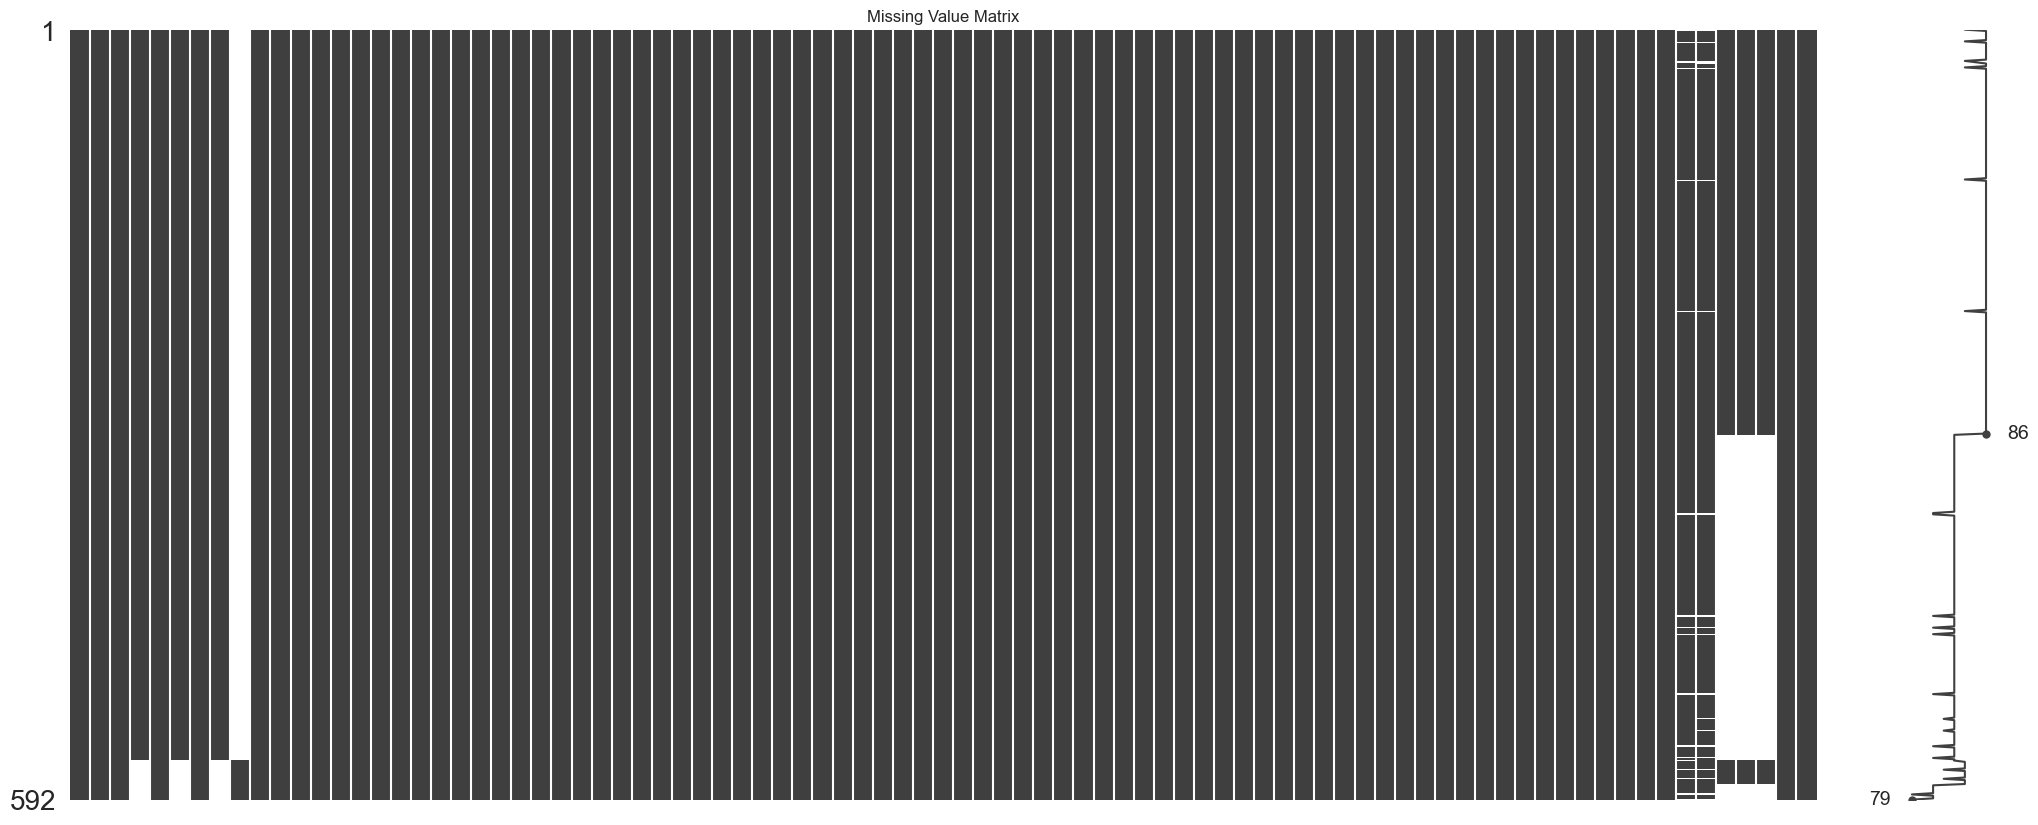

In [6]:
if msno is not None:
    plt.figure(figsize=tuple(plot_cfg.get("missing_matrix_figsize", [14, 6])))
    msno.matrix(df)
    plt.title("Missing Value Matrix")
    plt.show()
else:
    print("missingno is not installed; skipping missing-value matrix.")


In [7]:
for key, value in df.isnull().sum().items():
    if value > 0:
        print(f"{key}: {value} missing values")

itc_campus: 31 missing values
itc_student_id: 31 missing values
department: 31 missing values
faculty: 561 missing values
open_strengths: 19 missing values
open_challenges_suggestions: 21 missing values
survey_start: 262 missing values
survey_end: 262 missing values
response_time_minutes: 262 missing values


B. Missingness bar chart

Good for seeing how many non-missing values each column has.

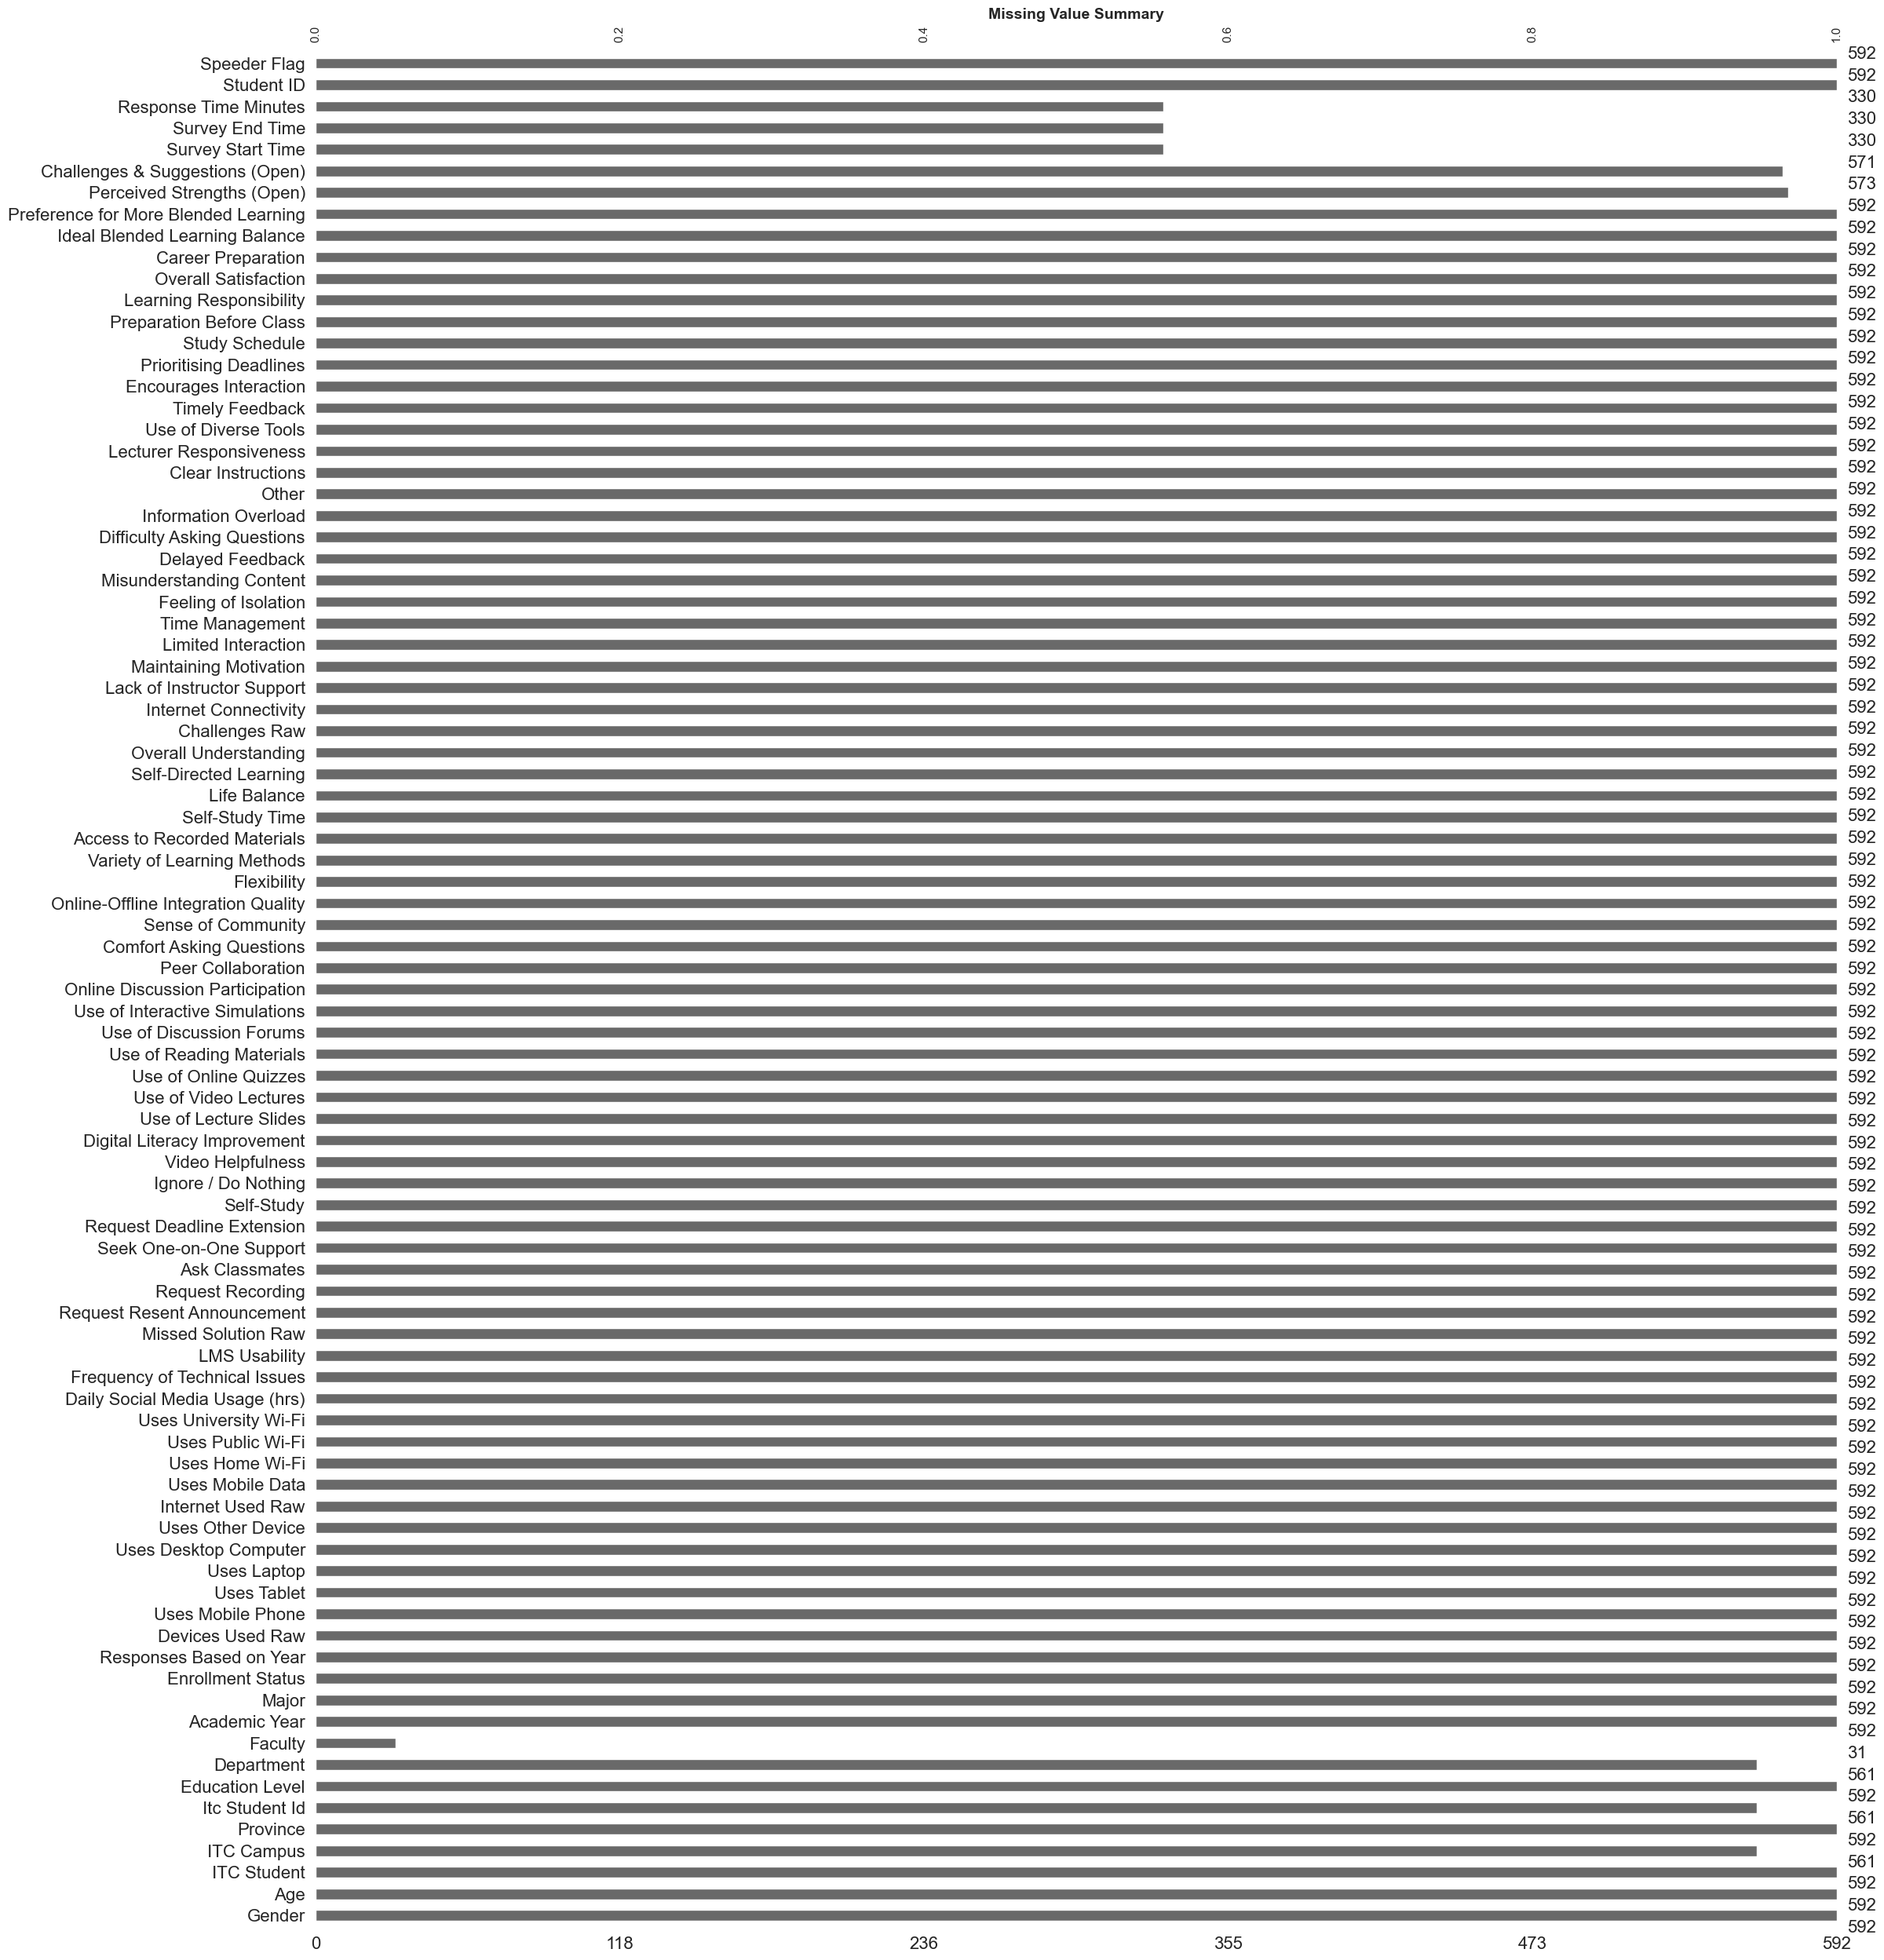

In [8]:
if msno is not None:
    plt.figure(figsize=tuple(plot_cfg.get("missing_bar_figsize", [14, 6])))

    # rename columns using pl() function (pretty label)
    df_pretty = df.rename(columns=lambda x: pl(x))

    msno.bar(df_pretty)

    plt.title("Missing Value Summary", fontsize=14, fontweight='bold')
    plt.xticks(rotation=90)  # rotate labels for readability
    plt.show()
else:
    df_pretty = df.rename(columns=lambda x: pl(x))
    print("missingno is not installed; skipping missing-value bar chart.")


C. Missingness heatmap

Good for seeing whether missingness in some columns is related to others.

<Figure size 1200x800 with 0 Axes>

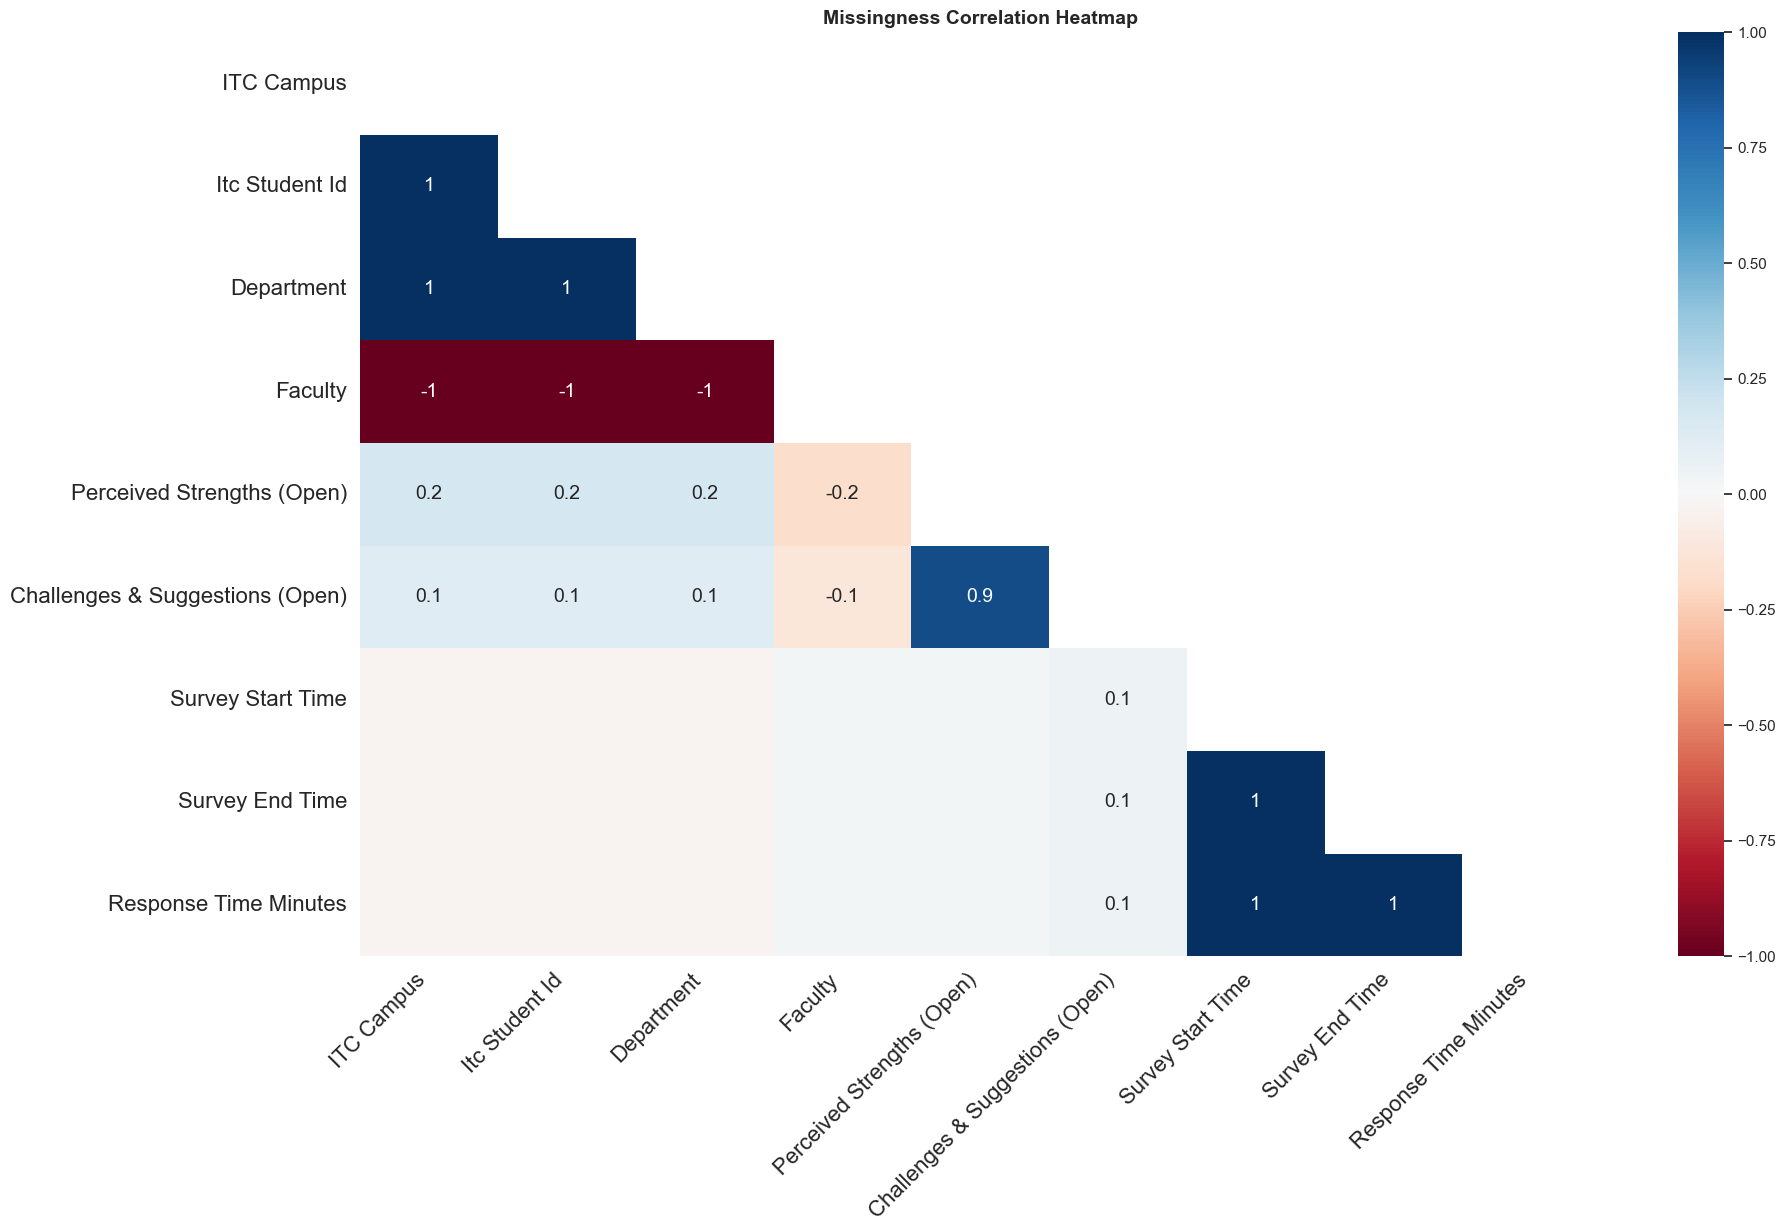

In [9]:
if msno is not None:
    plt.figure(figsize=tuple(plot_cfg.get("missing_heatmap_figsize", [12, 8])))

    msno.heatmap(df_pretty)

    plt.title("Missingness Correlation Heatmap", fontsize=14, fontweight='bold')
    plt.show()
else:
    print("missingno is not installed; skipping missingness correlation heatmap.")


**Note:** The heatmap shows correlations in missing values (not actual data values). 
Strong positive correlations indicate variables that are missing together, while 
negative correlations indicate mutually exclusive missingness. The observed patterns 
suggest structural missingness (e.g., ITC vs non-ITC students) rather than random 
data quality issues.

A. Missingness for clustering inputs only

This is probably the most important one for Chapter 6.

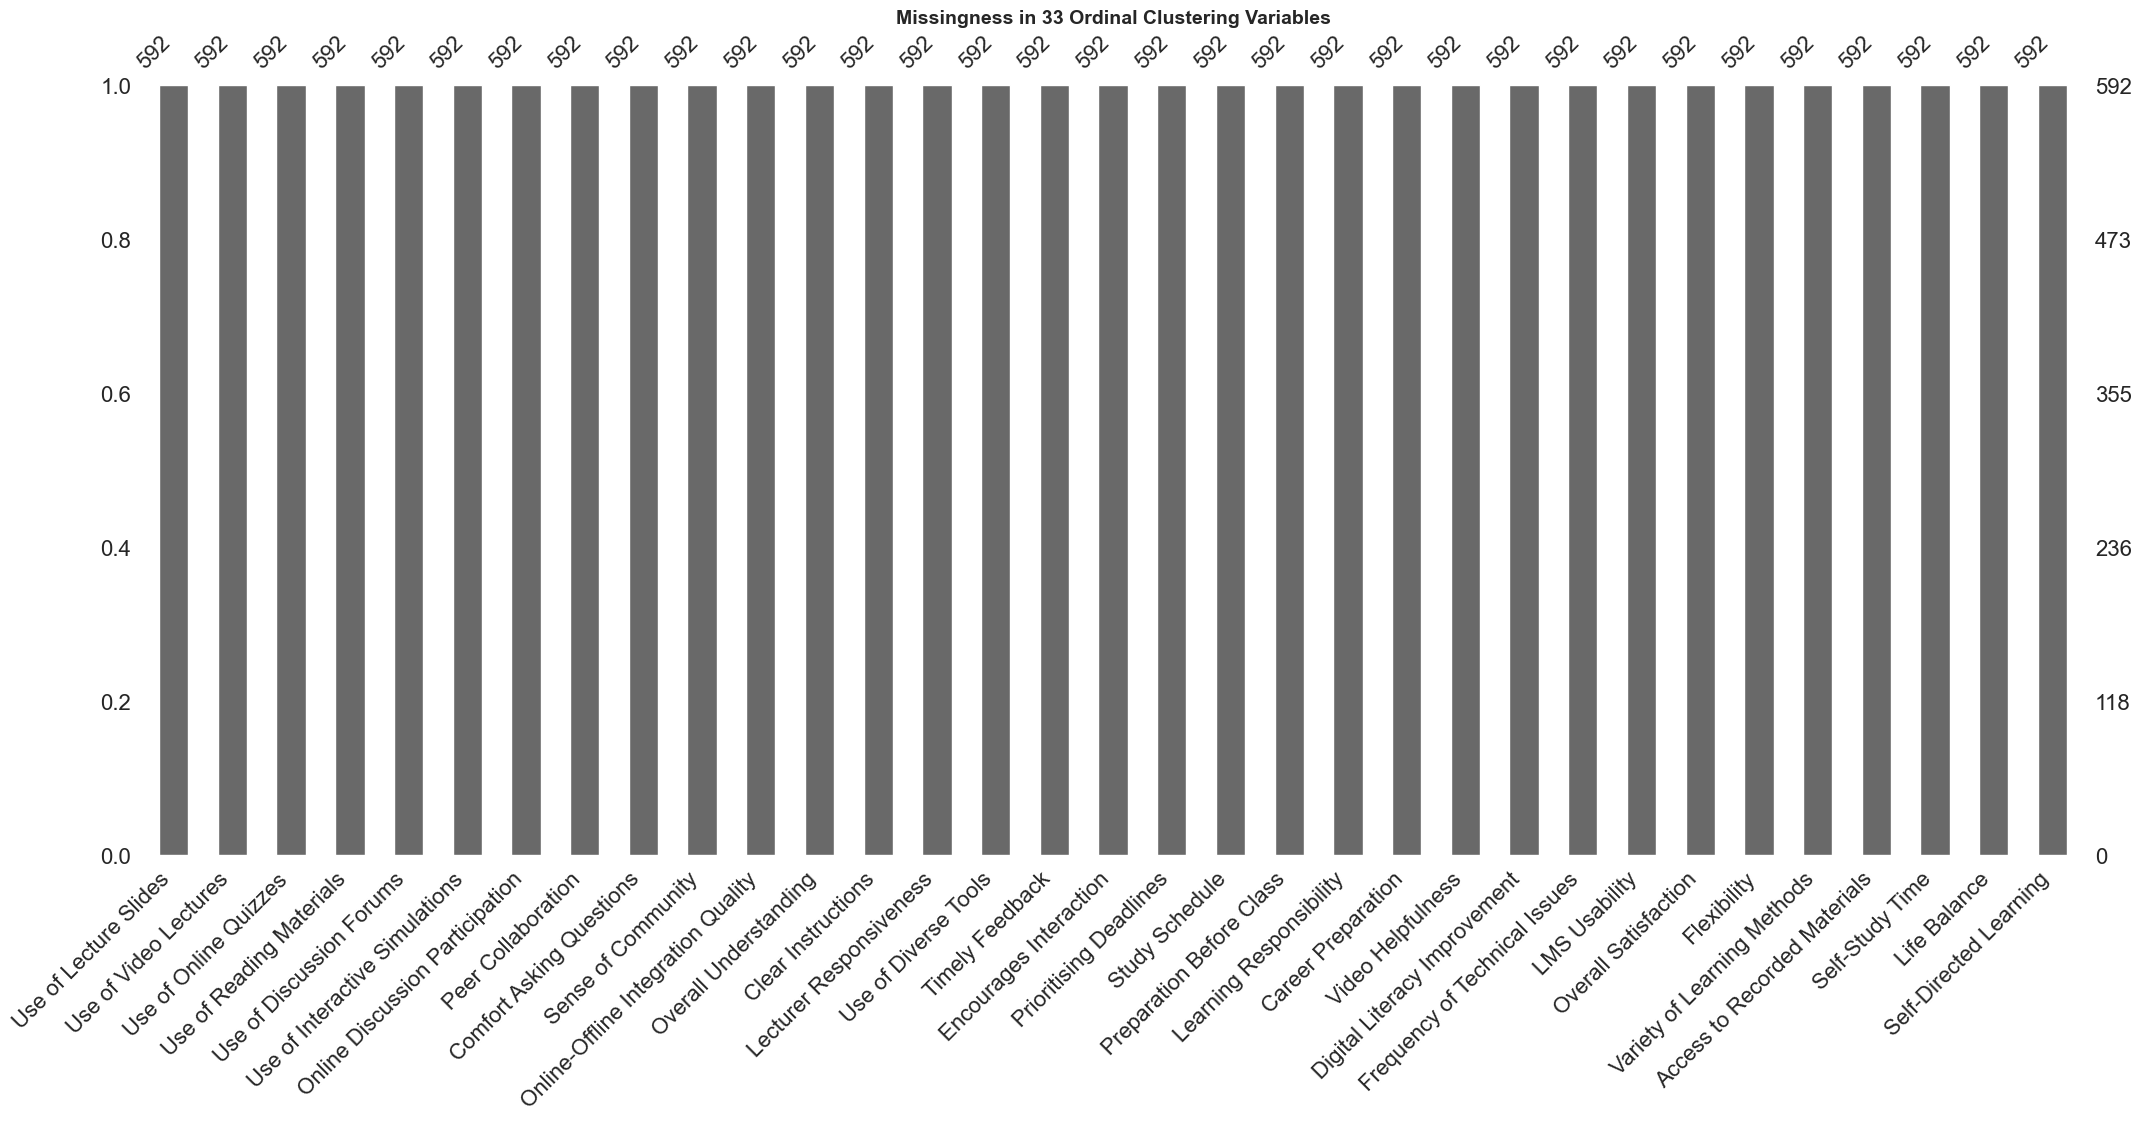

In [10]:
if msno is not None:
    plt.figure(figsize=tuple(plot_cfg.get("ordinal_missing_figsize", [12, 5])))

    df_pretty = df[ordinal_cols].rename(columns=lambda x: pl(x))

    msno.bar(df_pretty)

    plt.title(f"Missingness in {len(ordinal_cols)} Ordinal Clustering Variables", fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')

    plt.show()
else:
    print("missingno is not installed; skipping ordinal missingness bar chart.")


### Data Quality Assessment: Survey Completion Time

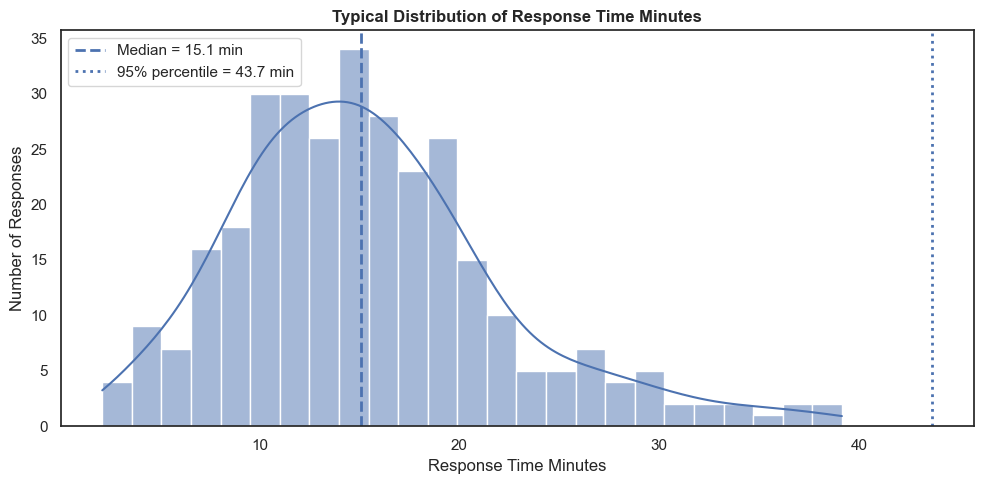

Median duration: 15.10 minutes
95% percentile duration: 43.67 minutes
Responses above configured percentile: 17


In [11]:
duration_col = dq_cfg.get("columns", {}).get("duration", "response_time_minutes")
label = pl(duration_col)
duration_quantile = dq_cfg.get("typical_duration_quantile", 0.95)

# Keep valid duration values
duration_df = df[df[duration_col].notna()].copy()

# Use configured percentile to focus on typical completion time
upper_duration = duration_df[duration_col].quantile(duration_quantile)
duration_typical = duration_df[duration_df[duration_col] <= upper_duration].copy()

plt.figure(figsize=(10, 5))

sns.histplot(
    data=duration_typical,
    x=duration_col,
    bins=25,
    kde=True,
    color=plot_cfg.get("default_plot_color", "#4c72b0")
)

plt.axvline(
    duration_df[duration_col].median(),
    linestyle="--",
    linewidth=2,
    label=f"Median = {duration_df[duration_col].median():.1f} min"
)

plt.axvline(
    upper_duration,
    linestyle=":",
    linewidth=2,
    label=f"{duration_quantile:.0%} percentile = {upper_duration:.1f} min"
)

plt.title(f"Typical Distribution of {label}", fontweight="bold")
plt.xlabel(label)
plt.ylabel("Number of Responses")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Median duration: {duration_df[duration_col].median():.2f} minutes")
print(f"{duration_quantile:.0%} percentile duration: {upper_duration:.2f} minutes")
print(f"Responses above configured percentile: {(duration_df[duration_col] > upper_duration).sum()}")



The distribution of survey completion time is moderately right-skewed. The median completion time is approximately 15 minutes, indicating that most respondents completed the survey within a reasonable duration. The majority of responses fall below the 95th percentile (around 36 minutes), suggesting that extreme durations are limited and likely caused by respondents leaving the survey open rather than actively completing it.

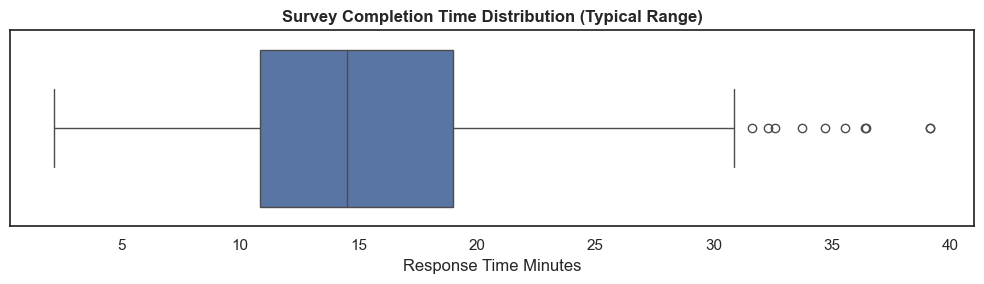

In [12]:
# Remove extreme values using configured percentile
duration_quantile = dq_cfg.get("typical_duration_quantile", 0.95)
upper_duration = duration_df[duration_col].quantile(duration_quantile)
duration_typical = duration_df[duration_df[duration_col] <= upper_duration]

plt.figure(figsize=(10, 3))

sns.boxplot(
    data=duration_typical,
    x=duration_col,
    color=plot_cfg.get("default_plot_color", "#4c72b0")
)

plt.title("Survey Completion Time Distribution (Typical Range)", fontweight="bold")
plt.xlabel(pl(duration_col))

plt.tight_layout()
plt.show()



The typical survey completion time ranges approximately between 10 and 20 minutes, with a median around 15 minutes. A small number of higher values (above 30 minutes) are observed, but these remain within a reasonable range compared to extreme outliers removed earlier. This indicates that most respondents completed the survey within a consistent and realistic time frame.

## 2 Exploratory Data Analysis

This chapter covers univariate distributions (demographic and Likert variables) and bivariate relationships between key demographic groups and outcome variables.

In [13]:
sns.set_theme(style="white", context="talk")
plt.rcParams['axes.grid'] = False


def pct(x):
    return x.value_counts(dropna=False, normalize=True).mul(100)


def missing_summary(df):
    out = pd.DataFrame({
        'missing_n': df.isna().sum(),
        'missing_pct': df.isna().mean() * 100,
        'dtype': df.dtypes.astype(str)
    }).sort_values(['missing_pct', 'missing_n'], ascending=False)
    return out


def add_barh_labels(ax, offset=0.4, fmt='{:.1f}%'):
    for p in ax.patches:
        w = p.get_width()
        y = p.get_y() + p.get_height()/2
        ax.text(w + offset, y, fmt.format(w), va='center', fontsize=10)


def add_bar_labels(ax, fmt='{:.1f}%'):
    for p in ax.patches:
        h = p.get_height()
        x = p.get_x() + p.get_width()/2
        ax.text(x, h + 0.8, fmt.format(h), ha='center', va='bottom', fontsize=9)


In [14]:
X = df[oridinal_cols]
summary = X.describe()
display(summary)

,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
count,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,...,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000
mean,4.094595,3.307432,3.638514,3.069257,2.998311,2.814189,2.891892,3.341216,3.395270,3.216216,...,3.393581,3.319257,3.423986,3.483108,3.690878,3.618243,3.923986,3.945946,3.670608,3.798986
std,0.890543,1.061595,0.903689,0.948916,1.099914,1.117134,0.993278,0.991567,0.813909,0.785146,...,0.933758,0.911165,0.783263,0.780289,0.776594,0.797334,0.870245,0.859180,0.857700,0.802997
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,3.000000,3.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,5.000000,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


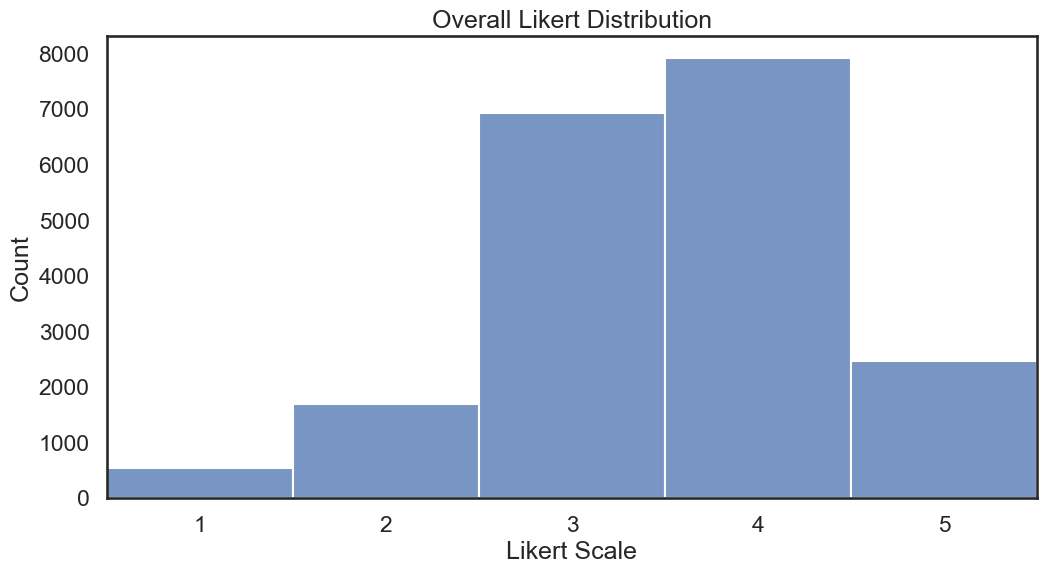

In [15]:
# Overall response tendency across ALL Likert variables and ALL students
plt.figure(figsize=(12, 6))

sns.histplot(
    X.values.flatten(),
    bins=np.arange(
        likert_cfg.get("hist_bin_start", 0.5),
        likert_cfg.get("hist_bin_stop", 6),
        likert_cfg.get("hist_bin_step", 1)
    ),
    discrete=True,
    color=plot_cfg.get("default_plot_color", "#4c72b0")
)

scale_min = likert_cfg.get("scale_min", 1)
scale_max = likert_cfg.get("scale_max", 5)

plt.title("Overall Likert Distribution")
plt.xlabel("Likert Scale")
plt.ylabel("Count")
plt.xticks(list(range(scale_min, scale_max + 1)))
plt.xlim(scale_min - 0.5, scale_max + 0.5)

plt.show()



Missingness and data quality

,missing_n,missing_pct,dtype
faculty,561,94.76,object
survey_start,262,44.26,object
survey_end,262,44.26,object
response_time_minutes,262,44.26,float64
itc_campus,31,5.24,object
itc_student_id,31,5.24,object
department,31,5.24,object
open_challenges_suggestions,21,3.55,object
open_strengths,19,3.21,object
gender,0,0.00,object


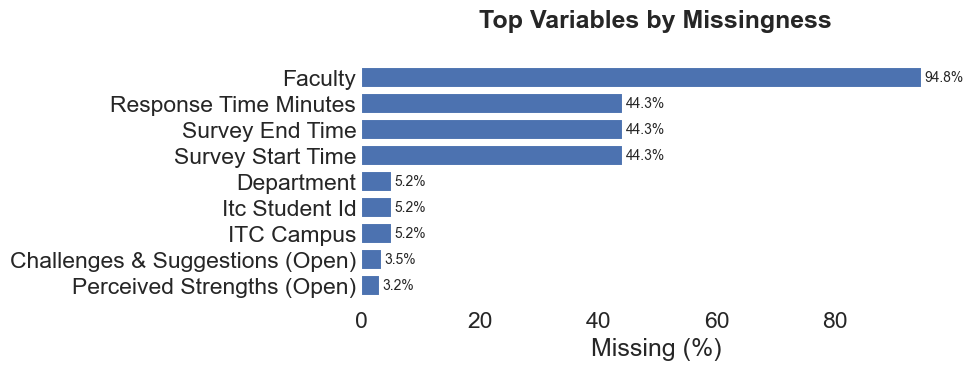


=== Data quality indicators ===
Speeders flagged        : 2
ID anomalies flagged    : 31
count       330.00
mean       1290.62
std       10843.90
min           2.13
25%          10.97
50%          15.10
75%          19.55
max      111858.34
Name: response_time_minutes, dtype: float64


In [16]:
miss_tbl = missing_summary(df)
display(miss_tbl.head(20).round(2))

miss_nonzero = miss_tbl[miss_tbl["missing_n"] > 0].copy()

top_missing_n = dq_cfg.get("top_missing_n", plot_cfg.get("top_missing_n", 15))

if not miss_nonzero.empty:
    top_miss = (
        miss_nonzero
        .head(top_missing_n)
        .sort_values("missing_pct", ascending=True)
    )

    fig, ax = plt.subplots(
        figsize=(10, max(4, len(top_miss) * 0.45))
    )

    ax.barh(
        [pl(c) for c in top_miss.index],
        top_miss["missing_pct"]
    )

    add_barh_labels(ax)

    ax.set_xlabel("Missing (%)")

    ax.set_title(
        "Top Variables by Missingness",
        fontweight="bold",
        pad=20
    )

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()

else:
    print("No missing values detected.")


# Data quality check for metadata variables if present
dq_cols = dq_cfg.get("columns", {})
quality_flags = [
    c for c in [
        dq_cols.get("speeder_flag", "flag_speeder"),
        dq_cols.get("itc_flag", "is_itc_student"),
        dq_cols.get("duration", "response_time_minutes")
    ]
    if c in df.columns
]

if quality_flags:
    print("\n=== Data quality indicators ===")

    speeder_col = dq_cols.get("speeder_flag", "flag_speeder")
    itc_col = dq_cols.get("itc_flag", "is_itc_student")
    duration_col = dq_cols.get("duration", "response_time_minutes")

    if speeder_col in df.columns:
        print(f"Speeders flagged        : {int(df[speeder_col].sum())}")

    if itc_col in df.columns:
        print(f"ID anomalies flagged    : {int((~df[itc_col]).sum())}")

    if duration_col in df.columns:
        print(df[duration_col].describe().round(2))


Numeric variables

=== Numeric descriptive statistics ===


,count,mean,median,std,min,max,skewness
age,592,20.31,20.0,2.27,17,43,3.76


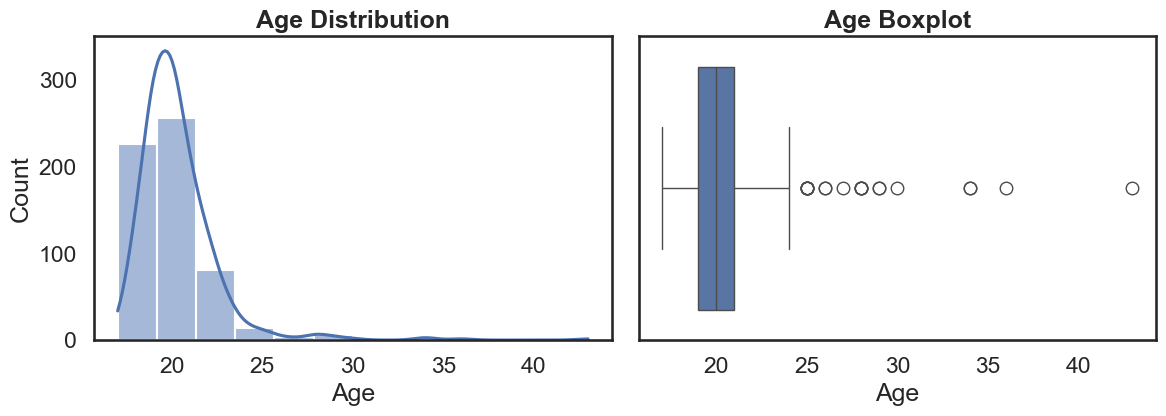

In [17]:
# ── 3.1.2 Numeric variables ───────────────────────────────────────────────────
numeric_vars = settings.numeric_vars
if numeric_vars:
    num_desc = pd.DataFrame({
        'count': df[numeric_vars].count(),
        'mean': df[numeric_vars].mean(),
        'median': df[numeric_vars].median(),
        'std': df[numeric_vars].std(),
        'min': df[numeric_vars].min(),
        'max': df[numeric_vars].max(),
        'skewness': df[numeric_vars].apply(lambda s: skew(s.dropna()) if s.dropna().shape[0] > 2 else np.nan)
    }).round(2)

    print("=== Numeric descriptive statistics ===")
    display(num_desc)

    for col in numeric_vars:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

        sns.histplot(df[col].dropna(), bins=12, kde=True, ax=axes[0], color=plot_cfg.get("default_plot_color", "#4c72b0"))
        axes[0].set_title(f'{pl(col)} Distribution', fontweight='bold')
        axes[0].set_xlabel(pl(col))

        sns.boxplot(x=df[col].dropna(), ax=axes[1], color=plot_cfg.get("default_plot_color", "#4c72b0"))
        axes[1].set_title(f'{pl(col)} Boxplot', fontweight='bold')
        axes[1].set_xlabel(pl(col))

        plt.tight_layout()
        plt.show()



=== Gender ===


,count,percent
Male,391,66.0
Female,192,32.4
Prefer Not To Say,9,1.5


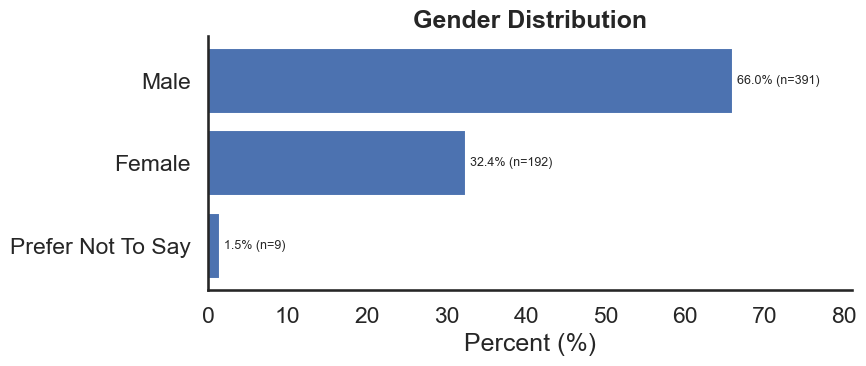


=== ITC Student ===


,count,percent
True,561,94.8
False,31,5.2


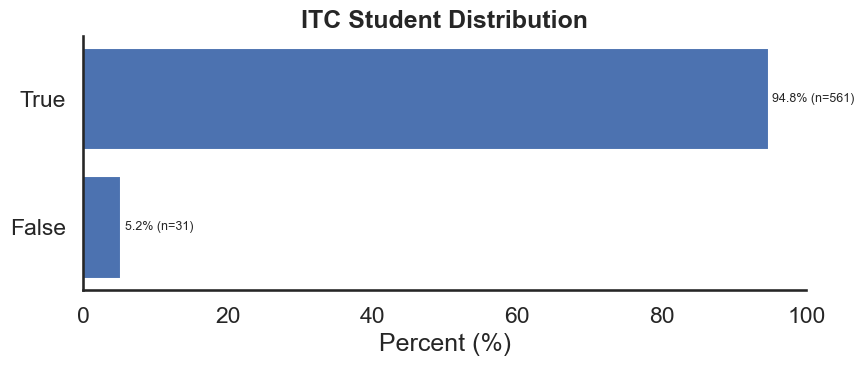


=== Education Level ===


,count,percent
Year2 - Sophomore,309,52.2
Year3 - Junior,89,15.0
Year4 - Senior,84,14.2
Year5 - Final Year,54,9.1
Year1 - Freshman,23,3.9
Master,21,3.5
Other,11,1.9
PHD,1,0.2


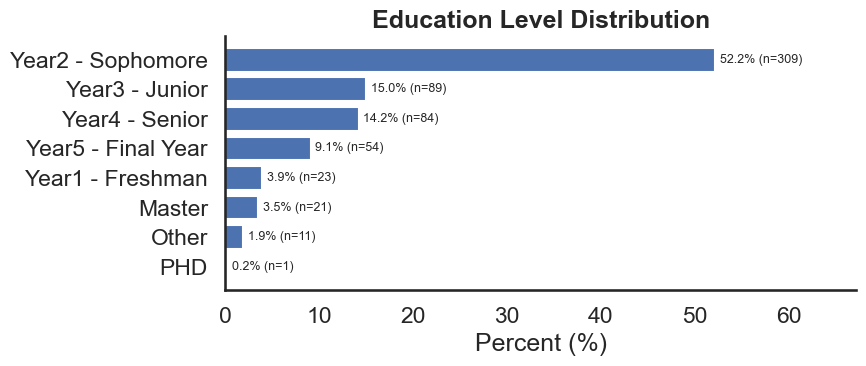


=== Major ===


,count,percent
Engineering,213,36.0
Data Science,177,29.9
Computer Science / IT,80,13.5
Software Engineering,45,7.6
Other,33,5.6
Cybersecurity,28,4.7
Finance,9,1.5
Education,2,0.3
Medicine / Health Sciences,2,0.3
Accounting,1,0.2


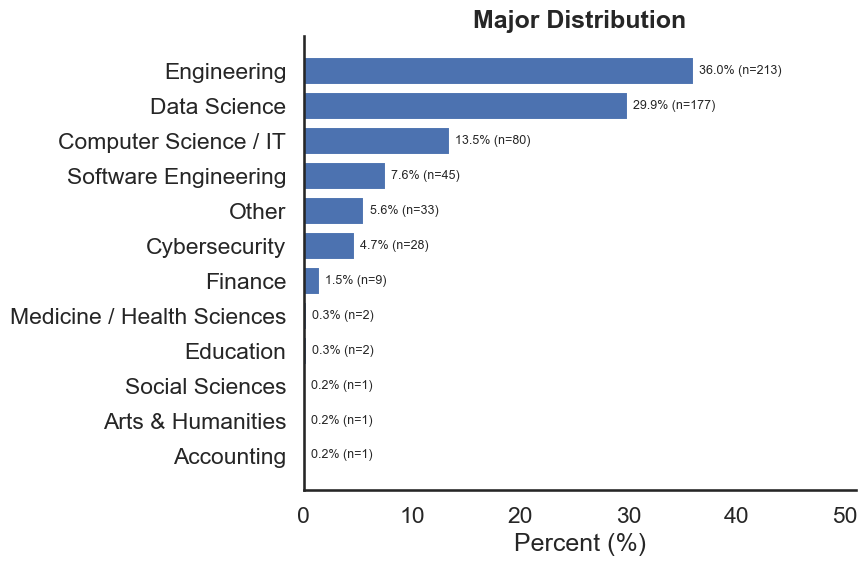


=== Department ===


,count,percent
AMS,165,27.9
GIC,113,19.1
GEE,62,10.5
Foundation Year,54,9.1
GIM,51,8.6
GAR,40,6.8
Missing,31,5.2
GRU,26,4.4
GTR,23,3.9
GCI,11,1.9


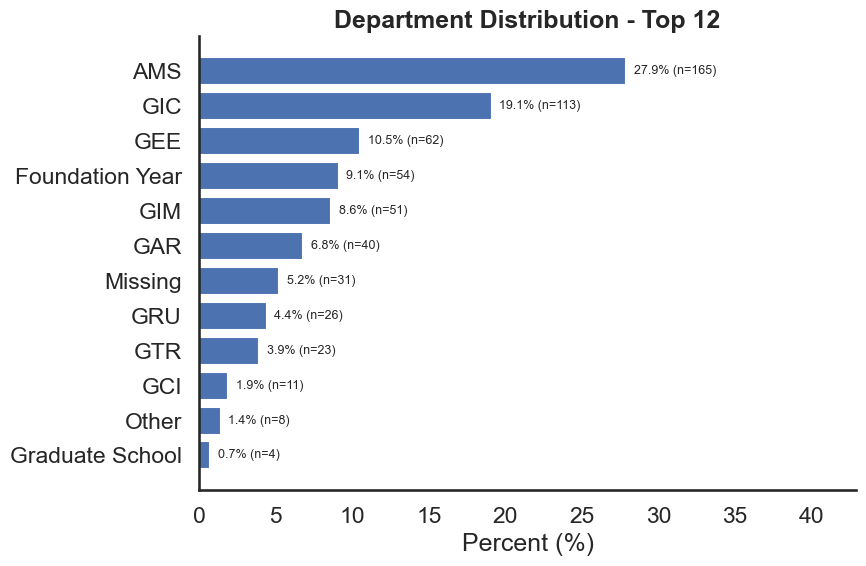


=== Province ===


,count,percent
Phnom Penh,583,98.5
Other,6,1.0
Kep,1,0.2
Tboung Khmum,1,0.2
Battambang,1,0.2


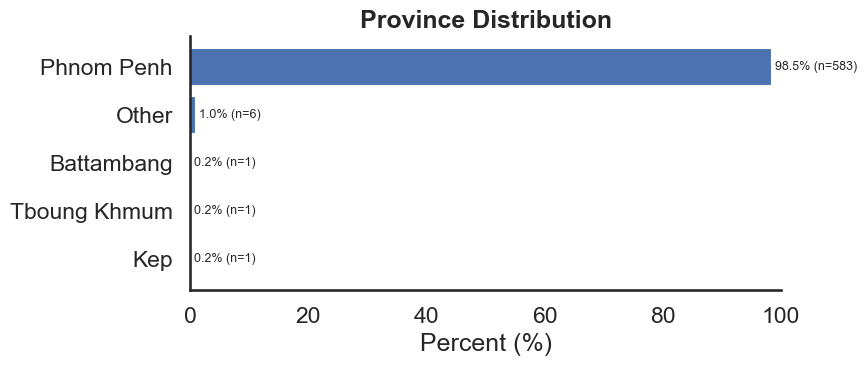


=== ITC Campus ===


,count,percent
ITC Phnom Penh (Main Campus),560,94.6
Missing,31,5.2
ITC Kep Campus,1,0.2


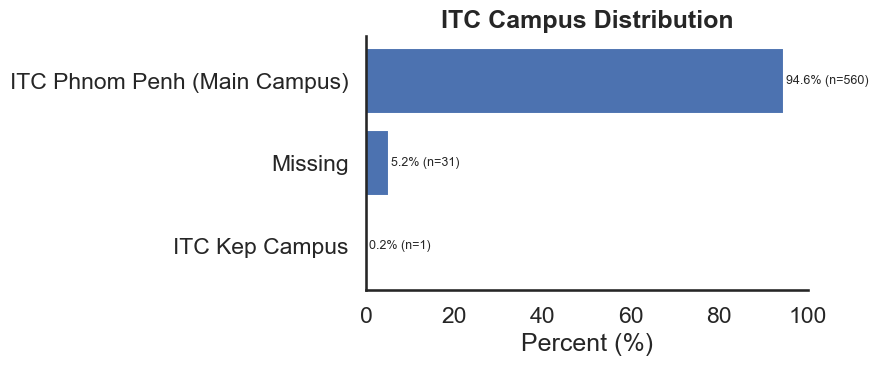


=== Ideal Blended Learning Balance ===


,count,percent
"Mostly Face-to-Face (e.g., 80% In-person, 20% Online)",243,41.0
"More Face-to-Face than Online (e.g., 60% In-person, 40% Online)",170,28.7
"Balanced Half and Half (50% In-person, 50% Online)",124,20.9
"More Online than Face-to-Face (e.g., 40% In-person, 60% Online)",37,6.2
"Mostly Online (e.g., 20% In-person, 80% Online)",18,3.0


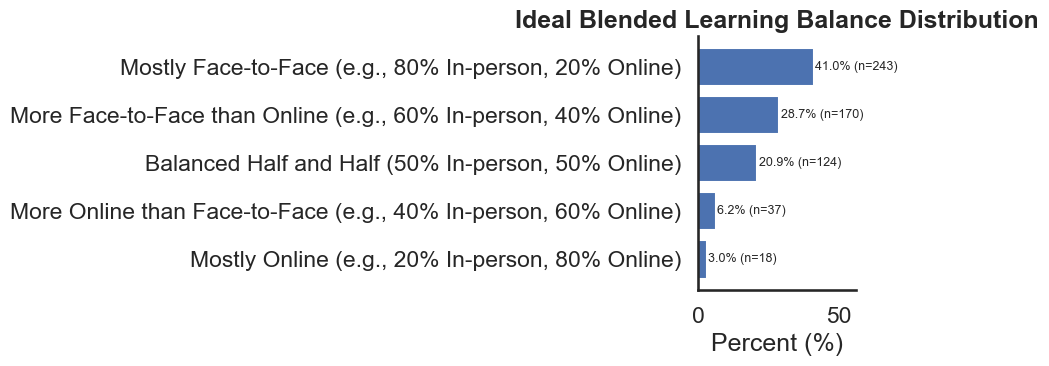


=== Preference for More Blended Learning ===


,count,percent
Yes,320,54.1
Neutral/Unsure,244,41.2
No,28,4.7


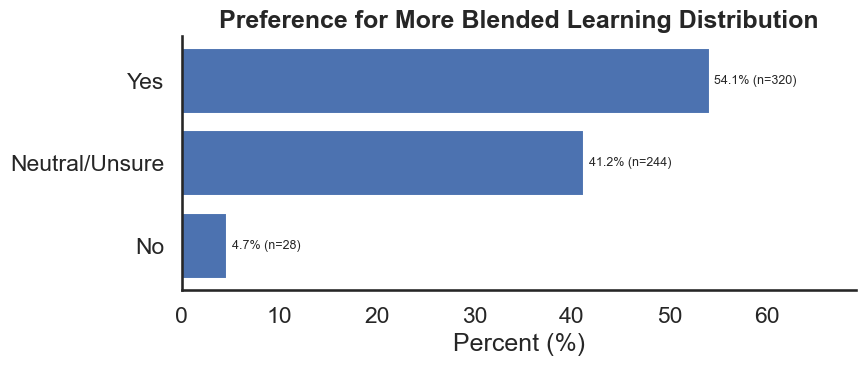


=== Enrollment Status ===


,count,percent
Currently enrolled,467,78.9
On academic leave,74,12.5
Recently graduated,31,5.2
Not currently enrolled,20,3.4


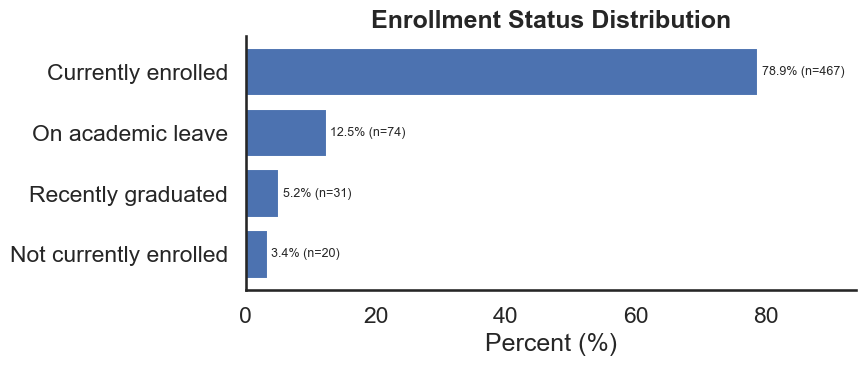

In [18]:
# ── 3.1.3 Nominal categorical variables ───────────────────────────────────────

for col in categorical_cols:
    # Frequency and percentage table
    freq = df[col].value_counts(dropna=False)
    pct_ = (
        df[col]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .round(1)
    )

    out = pd.DataFrame({
        "count": freq,
        "percent": pct_
    })

    # Clean index labels for display
    out.index = [
        "Missing" if pd.isna(x) else str(x)
        for x in out.index
    ]

    print(f"\n=== {pl(col)} ===")
    display(out)

    # Prepare plot data as dataframe
    plot_df = pd.DataFrame({
        "count": freq,
        "percent": pct_
    }).reset_index()

    plot_df.columns = ["category", "count", "percent"]

    plot_df["category_label"] = plot_df["category"].apply(
        lambda x: "Missing" if pd.isna(x) else str(x)
    )

    # Keep only top categories if too many
    top_category_n = plot_cfg.get("top_category_n", 12)
    is_top_limited = len(plot_df) > top_category_n

    if is_top_limited:
        plot_df = (
            plot_df
            .sort_values("count", ascending=False)
            .head(top_category_n)
        )

    # Sort ascending for horizontal bar readability
    plot_df = plot_df.sort_values("percent", ascending=True)

    labels = plot_df["category_label"].tolist()
    values = plot_df["percent"].astype(float).tolist()
    counts = plot_df["count"].astype(int).tolist()

    # Plot
    fig, ax = plt.subplots(
        figsize=(9, max(4, len(plot_df) * 0.5))
    )

    bars = ax.barh(labels, values)

    # Add percent + count labels
    for bar, percent, count in zip(bars, values, counts):
        width = bar.get_width()
        ax.text(
            width + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{percent:.1f}% (n={count})",
            va="center",
            fontsize=9
        )

    ax.set_xlabel("Percent (%)")

    title = f"{pl(col)} Distribution"
    if is_top_limited:
        title += f" - Top {top_category_n}"

    ax.set_title(
        title,
        fontweight="bold"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Give space for labels outside bars
    max_value = max(values) if values else 0
    ax.set_xlim(0, min(100, max_value + 15))

    plt.tight_layout()
    plt.show()

Ordinal categorical variables


=== Academic Year (ordered) ===


,count,percent
academic_year,,
2019–2020,2,0.3
2020–2021,7,1.2
2021–2022,15,2.5
2022–2023,29,4.9
2023–2024,29,4.9
2024–2025,138,23.3
2025–2026,372,62.8


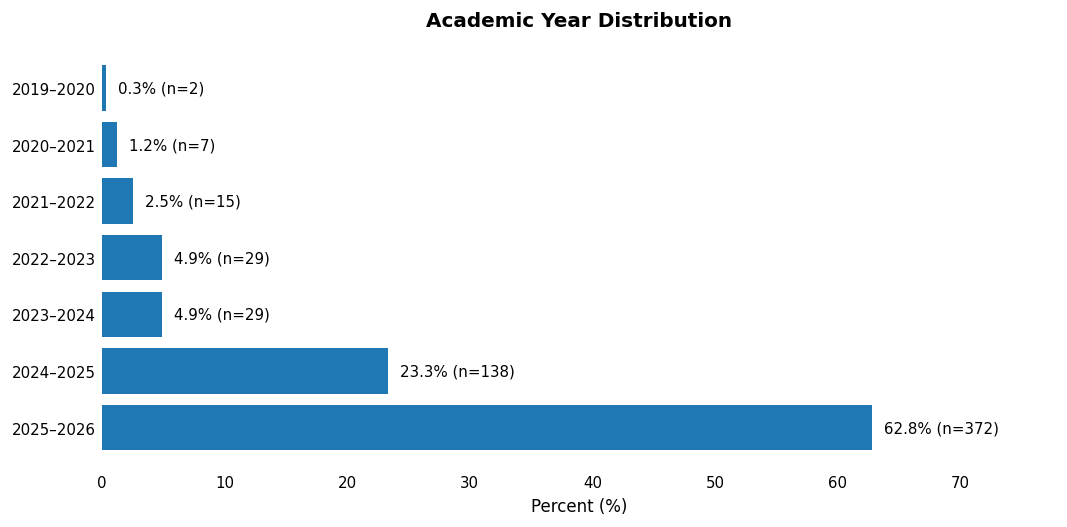


=== Daily Social Media Usage (hrs) (ordered) ===


,count,percent
social_media_hours,,
Less than 1 hour,33,5.6
1 Hour,77,13.0
2 hours,147,24.8
3 hours,143,24.2
4 hours,98,16.6
More than 5 hours,94,15.9


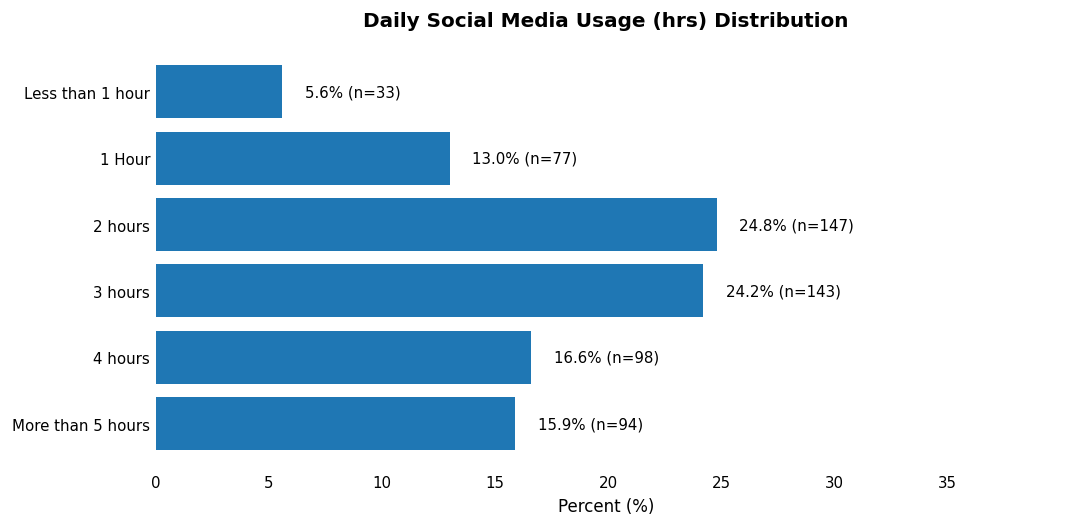

In [57]:
# ── 3.1.4 Ordinal categorical variables ───────────────────────────────────────

ordinal_orders = {
    "social_media_hours": [
        "Less than 1 hour",
        "1 Hour",
        "2 hours",
        "3 hours",
        "4 hours",
        "More than 5 hours"
    ],
    "ACADEMIC_YEAR": [
        "Year 1 - Freshman",
        "Year 2 - Sophomore",
        "Year 3 - Junior",
        "Year 4 - Senior",
        "Year 5 - Final Year",
        "Master",
        "PHD",
        "Other"
    ],
}

for col in original_categorical_cols:
    s = df[col].dropna().astype(str)

    if col in ordinal_orders:
        order = [x for x in ordinal_orders[col] if x in s.unique()]
        freq = s.value_counts().reindex(order, fill_value=0)
    else:
        freq = s.value_counts().sort_index()

    pct_ = (freq / freq.sum() * 100).round(1)

    out = pd.DataFrame({
        "count": freq,
        "percent": pct_
    })

    print(f"\n=== {pl(col)} (ordered) ===")
    display(out)

    plot_df = pd.DataFrame({
        "category": freq.index,
        "count": freq.values,
        "percent": pct_.values
    })

    fig, ax = plt.subplots(
        figsize=(9, max(4.5, len(plot_df) * 0.55))
    )

    bars = ax.barh(
        plot_df["category"],
        plot_df["percent"]
    )

    # Keep ordinal order from top to bottom
    ax.invert_yaxis()

    # Add percent and count labels
    for bar, percent, count in zip(
        bars,
        plot_df["percent"],
        plot_df["count"]
    ):
        width = bar.get_width()

        ax.text(
            width + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{percent:.1f}% (n={int(count)})",
            va="center",
            fontsize=9
        )

    ax.set_xlabel("Percent (%)")
    ax.set_ylabel("")
    ax.set_title(
        f"{pl(col)} Distribution",
        fontweight="bold",
        pad=12
    )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Clean tick marks
    ax.tick_params(axis="both", length=0)

    # Add space for labels
    max_percent = plot_df["percent"].max()
    ax.set_xlim(0, max_percent + 15)

    plt.tight_layout()
    plt.show()

Likert-scale variables

=== Likert descriptive statistics ===


,mean,median,std,min,max,skewness,range_width
use_lecture_slides,4.09,4.0,0.89,1,5,-0.75,4
video_helpfulness,4.01,4.0,0.99,1,5,-0.91,4
self_responsibility,3.96,4.0,0.73,1,5,-0.67,4
benefit_self_study_time,3.95,4.0,0.86,1,5,-0.55,4
benefit_recorded_access,3.92,4.0,0.87,1,5,-0.64,4
self_prioritize_deadlines,3.88,4.0,0.77,1,5,-0.78,4
overall_understanding,3.82,4.0,0.73,1,5,-0.38,4
benefit_self_directed,3.80,4.0,0.80,1,5,-0.45,4
benefit_flexibility,3.69,4.0,0.78,1,5,-0.51,4
benefit_life_balance,3.67,4.0,0.86,1,5,-0.38,4


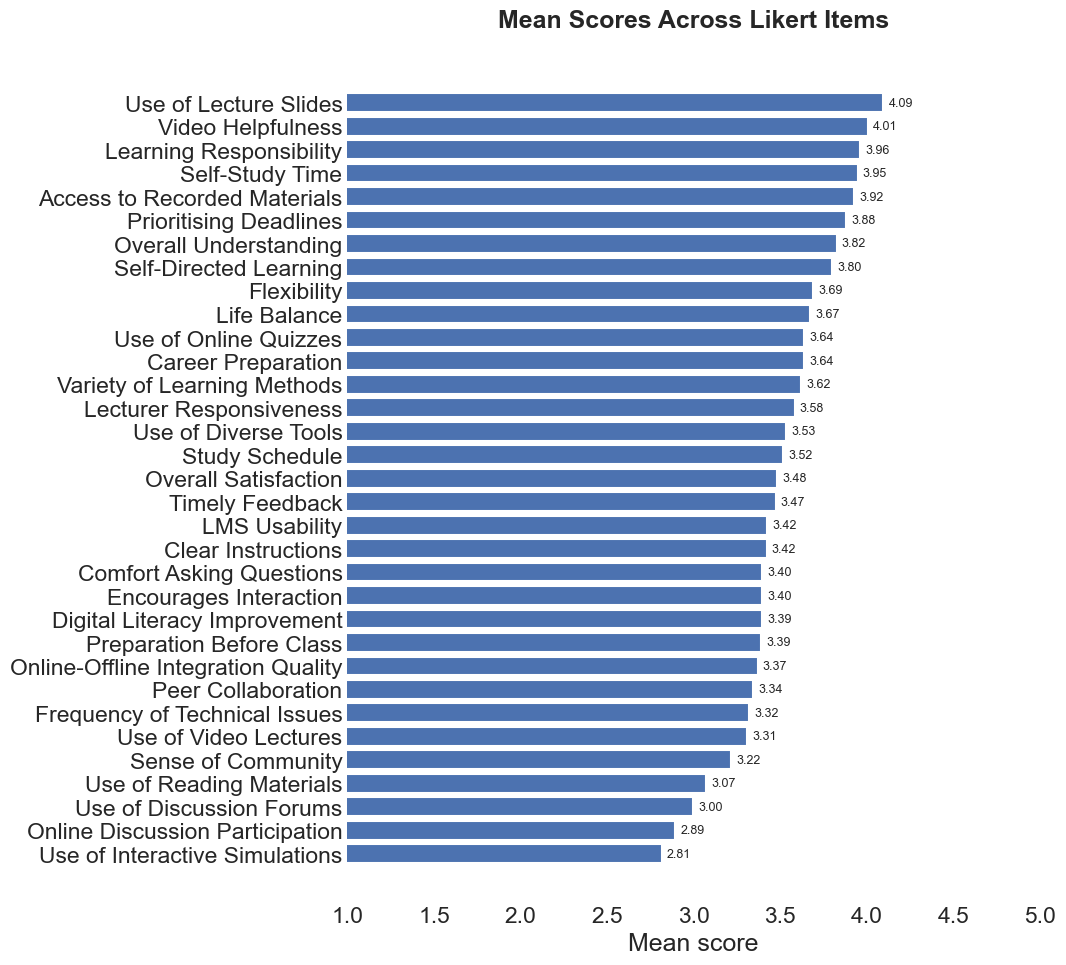

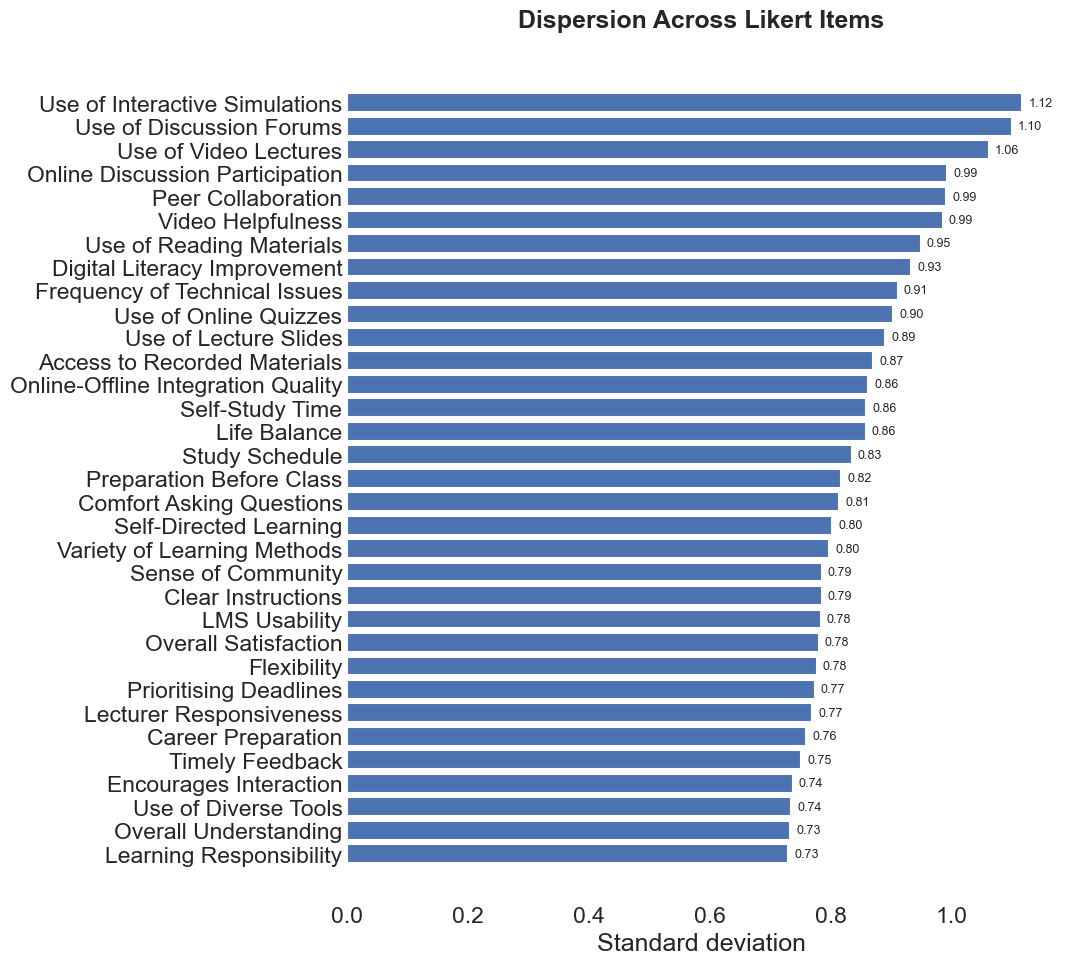

In [20]:
# ── 3.1.5 Likert-scale variables (Ordinal33) ──────────────────────────────────

if oridinal_cols:
    likert_desc = pd.DataFrame({
        'mean': df[oridinal_cols].mean(),
        'median': df[oridinal_cols].median(),
        'std': df[oridinal_cols].std(),
        'min': df[oridinal_cols].min(),
        'max': df[oridinal_cols].max(),
        'skewness': df[oridinal_cols].apply(
            lambda s: skew(s.dropna()) if s.dropna().shape[0] > 2 else np.nan
        )
    }).round(2)

    likert_desc['range_width'] = likert_desc['max'] - likert_desc['min']
    likert_desc = likert_desc.sort_values('mean', ascending=False)

    print("=== Likert descriptive statistics ===")
    display(likert_desc)

    # Mean plot
    mean_s = df[oridinal_cols].mean().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(11, 10))

    ax.barh(
        [pl(c) for c in mean_s.index],
        mean_s.values
    )

    ax.set_xlim(1, 5)
    ax.set_xlabel('Mean score')

    ax.set_title(
        'Mean Scores Across Likert Items',
        fontweight='bold',
        pad=20
    )

    for i, v in enumerate(mean_s.values):
        ax.text(
            v + 0.03,
            i,
            f'{v:.2f}',
            va='center',
            fontsize=9
        )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()

    # Dispersion plot
    std_s = df[oridinal_cols].std().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(11, 10))

    ax.barh(
        [pl(c) for c in std_s.index],
        std_s.values
    )

    ax.set_xlabel('Standard deviation')

    ax.set_title(
        'Dispersion Across Likert Items',
        fontweight='bold',
        pad=20
    )

    for i, v in enumerate(std_s.values):
        ax.text(
            v + 0.01,
            i,
            f'{v:.2f}',
            va='center',
            fontsize=9
        )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()

Binary multi-response variables


=== Devices ===


,count_selected,percent_selected
Uses Other Device,3,0.5
Uses Desktop Computer,63,10.6
Uses Tablet,190,32.1
Uses Mobile Phone,495,83.6
Uses Laptop,504,85.1


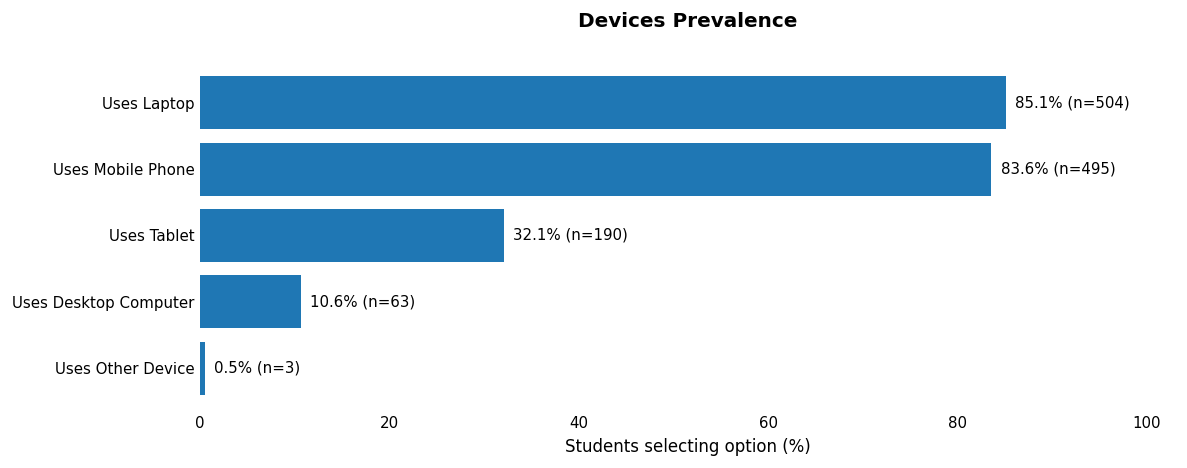


=== Internet Access ===


,count_selected,percent_selected
Uses Public Wi-Fi,131,22.1
Uses University Wi-Fi,277,46.8
Uses Home Wi-Fi,364,61.5
Uses Mobile Data,513,86.7


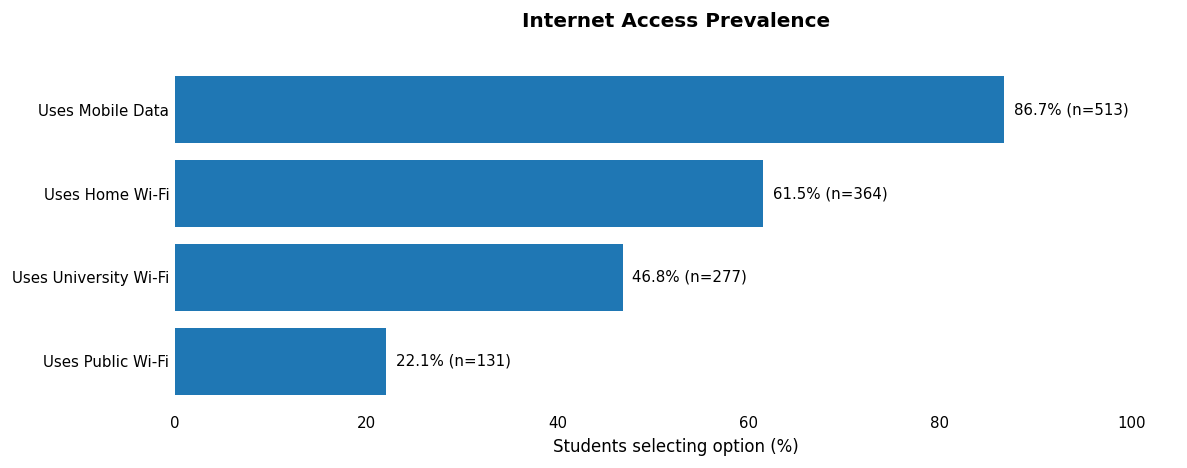


=== Coping Mechanisms ===


,count_selected,percent_selected
Ignore / Do Nothing,42,7.1
Seek One-on-One Support,46,7.8
Request Deadline Extension,146,24.7
Request Resent Announcement,215,36.3
Self-Study,219,37.0
Request Recording,361,61.0
Ask Classmates,363,61.3


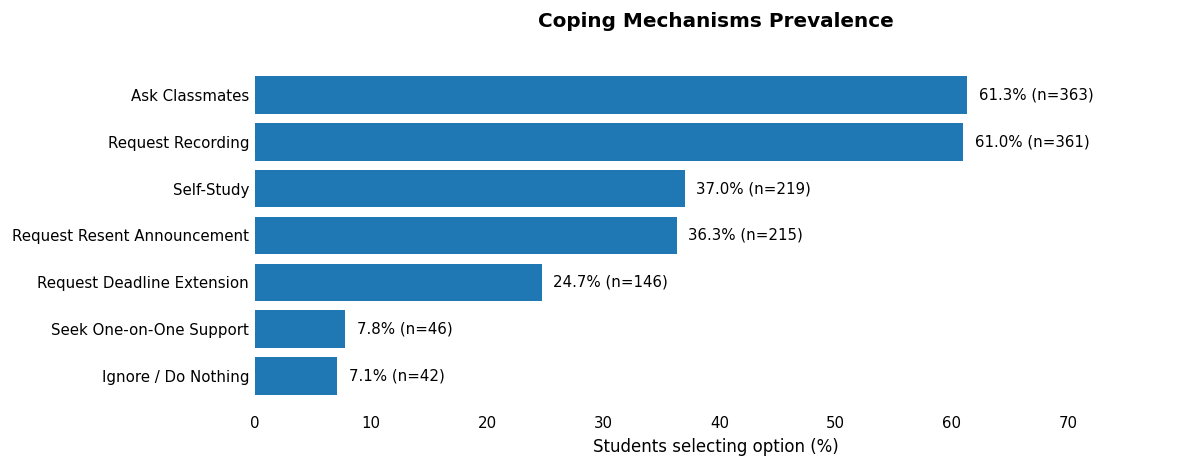


=== Challenges ===


,count_selected,percent_selected
Other,8,1.4
Information Overload,135,22.8
Delayed Feedback,137,23.1
Feeling of Isolation,142,24.0
Time Management,156,26.4
Misunderstanding Content,189,31.9
Limited Interaction,207,35.0
Difficulty Asking Questions,217,36.7
Lack of Instructor Support,237,40.0
Maintaining Motivation,306,51.7


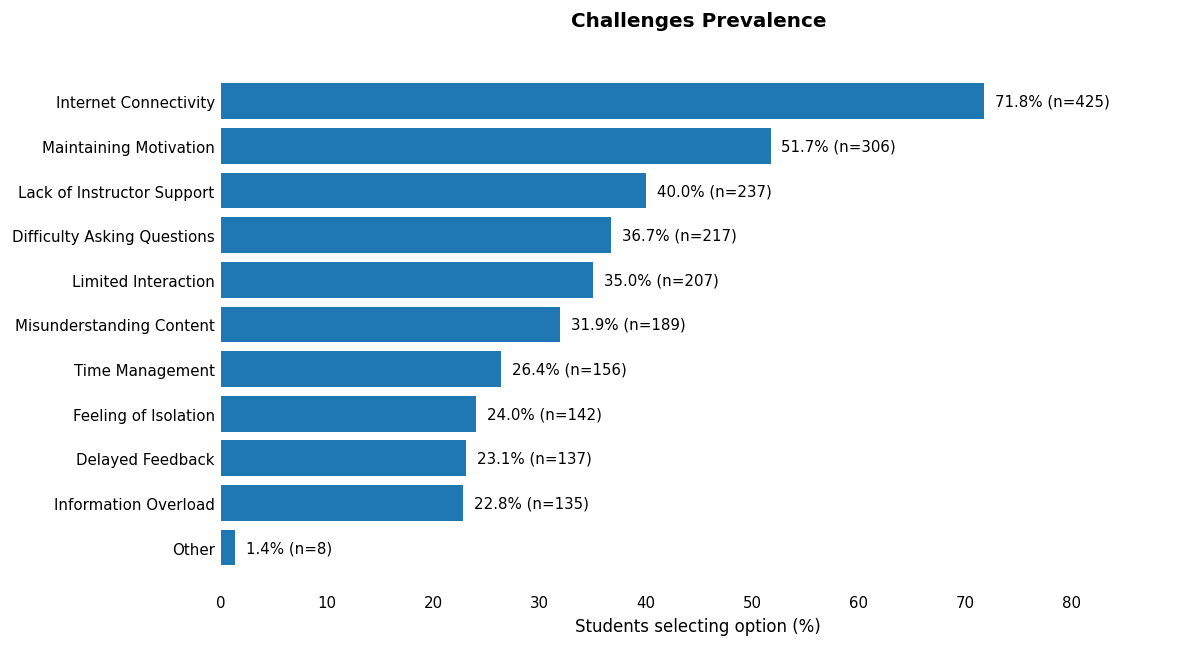


=== Thesis Focus: Reported Blended Learning Challenges ===


,count_selected,percent_selected
Other,8,1.4
Information Overload,135,22.8
Delayed Feedback,137,23.1
Feeling of Isolation,142,24.0
Time Management,156,26.4
Misunderstanding Content,189,31.9
Limited Interaction,207,35.0
Difficulty Asking Questions,217,36.7
Lack of Instructor Support,237,40.0
Maintaining Motivation,306,51.7


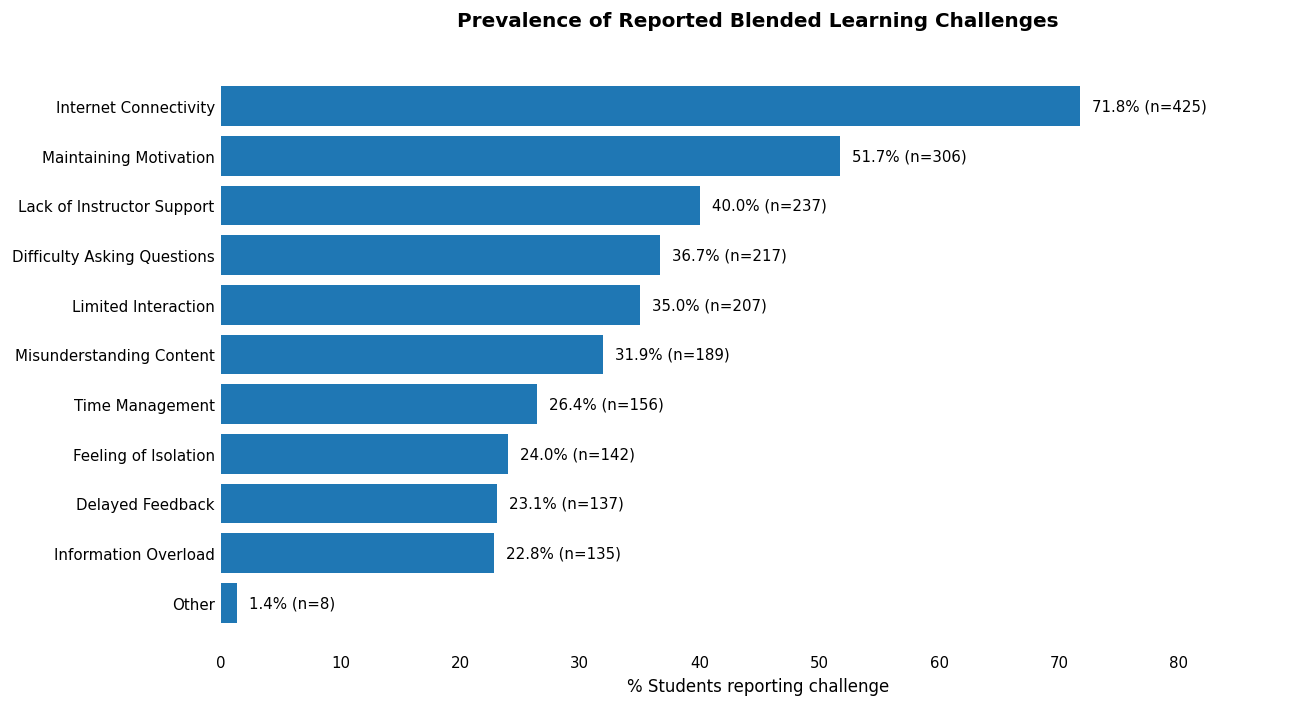

In [58]:
# ── 3.1.6 Binary multi-response variables ─────────────────────────────────────

MULTI_GROUPS = {
    g: [c for c in cols if c in df.columns]
    for g, cols in multi_groups.items()
}

for group_name, cols in MULTI_GROUPS.items():
    if not cols:
        continue

    rates = (df[cols].mean() * 100).sort_values(ascending=True)
    counts = df[cols].sum().reindex(rates.index).astype(int)

    out = pd.DataFrame({
        "count_selected": counts,
        "percent_selected": rates.round(1)
    })

    out.index = [pl(c) for c in out.index]

    print(f"\n=== {pl(group_name)} ===")
    display(out)

    fig, ax = plt.subplots(
        figsize=(10, max(4, len(out) * 0.5))
    )

    bars = ax.barh(
        out.index,
        out["percent_selected"]
    )

    # Add percent and count labels
    for bar, percent, count in zip(
        bars,
        out["percent_selected"],
        out["count_selected"]
    ):
        width = bar.get_width()

        ax.text(
            width + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{percent:.1f}% (n={int(count)})",
            va="center",
            fontsize=9
        )

    ax.set_xlabel("Students selecting option (%)")

    ax.set_title(
        f"{pl(group_name)} Prevalence",
        fontweight="bold",
        pad=20
    )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="both", length=0)

    # Add space for labels
    max_percent = out["percent_selected"].max()
    ax.set_xlim(0, max_percent + 18)

    plt.tight_layout()
    plt.show()


# ── Optional: dedicated thesis-quality challenge prevalence ───────────────────

if "challenges" in MULTI_GROUPS and MULTI_GROUPS["challenges"]:
    ch_cols = MULTI_GROUPS["challenges"]

    ch_rates = (
        df[ch_cols]
        .mean()
        .mul(100)
        .sort_values(ascending=True)
    )

    ch_counts = (
        df[ch_cols]
        .sum()
        .reindex(ch_rates.index)
        .astype(int)
    )

    ch_out = pd.DataFrame({
        "count_selected": ch_counts,
        "percent_selected": ch_rates.round(1)
    })

    ch_out.index = [pl(c) for c in ch_out.index]

    print("\n=== Thesis Focus: Reported Blended Learning Challenges ===")
    display(ch_out)

    fig, ax = plt.subplots(figsize=(11, 6))

    bars = ax.barh(
        ch_out.index,
        ch_out["percent_selected"]
    )

    # Add percent and count labels
    for bar, percent, count in zip(
        bars,
        ch_out["percent_selected"],
        ch_out["count_selected"]
    ):
        width = bar.get_width()

        ax.text(
            width + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{percent:.1f}% (n={int(count)})",
            va="center",
            fontsize=9
        )

    ax.set_xlabel("% Students reporting challenge")

    ax.set_title(
        "Prevalence of Reported Blended Learning Challenges",
        fontweight="bold",
        pad=20
    )

    # Remove grid
    ax.grid(False)

    # Remove bounding box
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove tick marks
    ax.tick_params(axis="both", length=0)

    # Add space for labels
    max_percent = ch_out["percent_selected"].max()
    ax.set_xlim(0, max_percent + 18)

    plt.tight_layout()
    plt.show()

In [22]:
# ── 3.1.7 Summary table by variable type ──────────────────────────────────────

summary_tbl = pd.DataFrame({
    'Variable Type': [
        'Numeric',
        'Nominal categorical',
        'Ordinal categorical',
        'Likert-scale items',
        'Binary multi-response variables'
    ],
    'Count': [
        len(numeric_vars),
        len(categorical_cols),
        len(original_categorical_cols),
        len(oridinal_cols),
        sum(len(v) for v in MULTI_GROUPS.values())
    ],
    'Examples': [
        ', '.join(numeric_vars[:3]) if numeric_vars else '-',
        ', '.join(categorical_cols[:3]) if categorical_cols else '-',
        ', '.join(original_categorical_cols[:3]) if original_categorical_cols else '-',
        ', '.join(oridinal_cols[:3]) if oridinal_cols else '-',
        ', '.join(list(MULTI_GROUPS.keys())[:3]) if MULTI_GROUPS else '-'
    ]
})

display(summary_tbl)

,Variable Type,Count,Examples
0,Numeric,1,age
1,Nominal categorical,10,"gender, is_itc_student, education_level"
2,Ordinal categorical,2,"academic_year, social_media_hours"
3,Likert-scale items,33,"use_lecture_slides, use_video_lectures, use_qu..."
4,Binary multi-response variables,27,"devices, internet_access, coping_mechanisms"


### 2.1 Univariate Analysis

#### 2.1.1 Demographic Overview

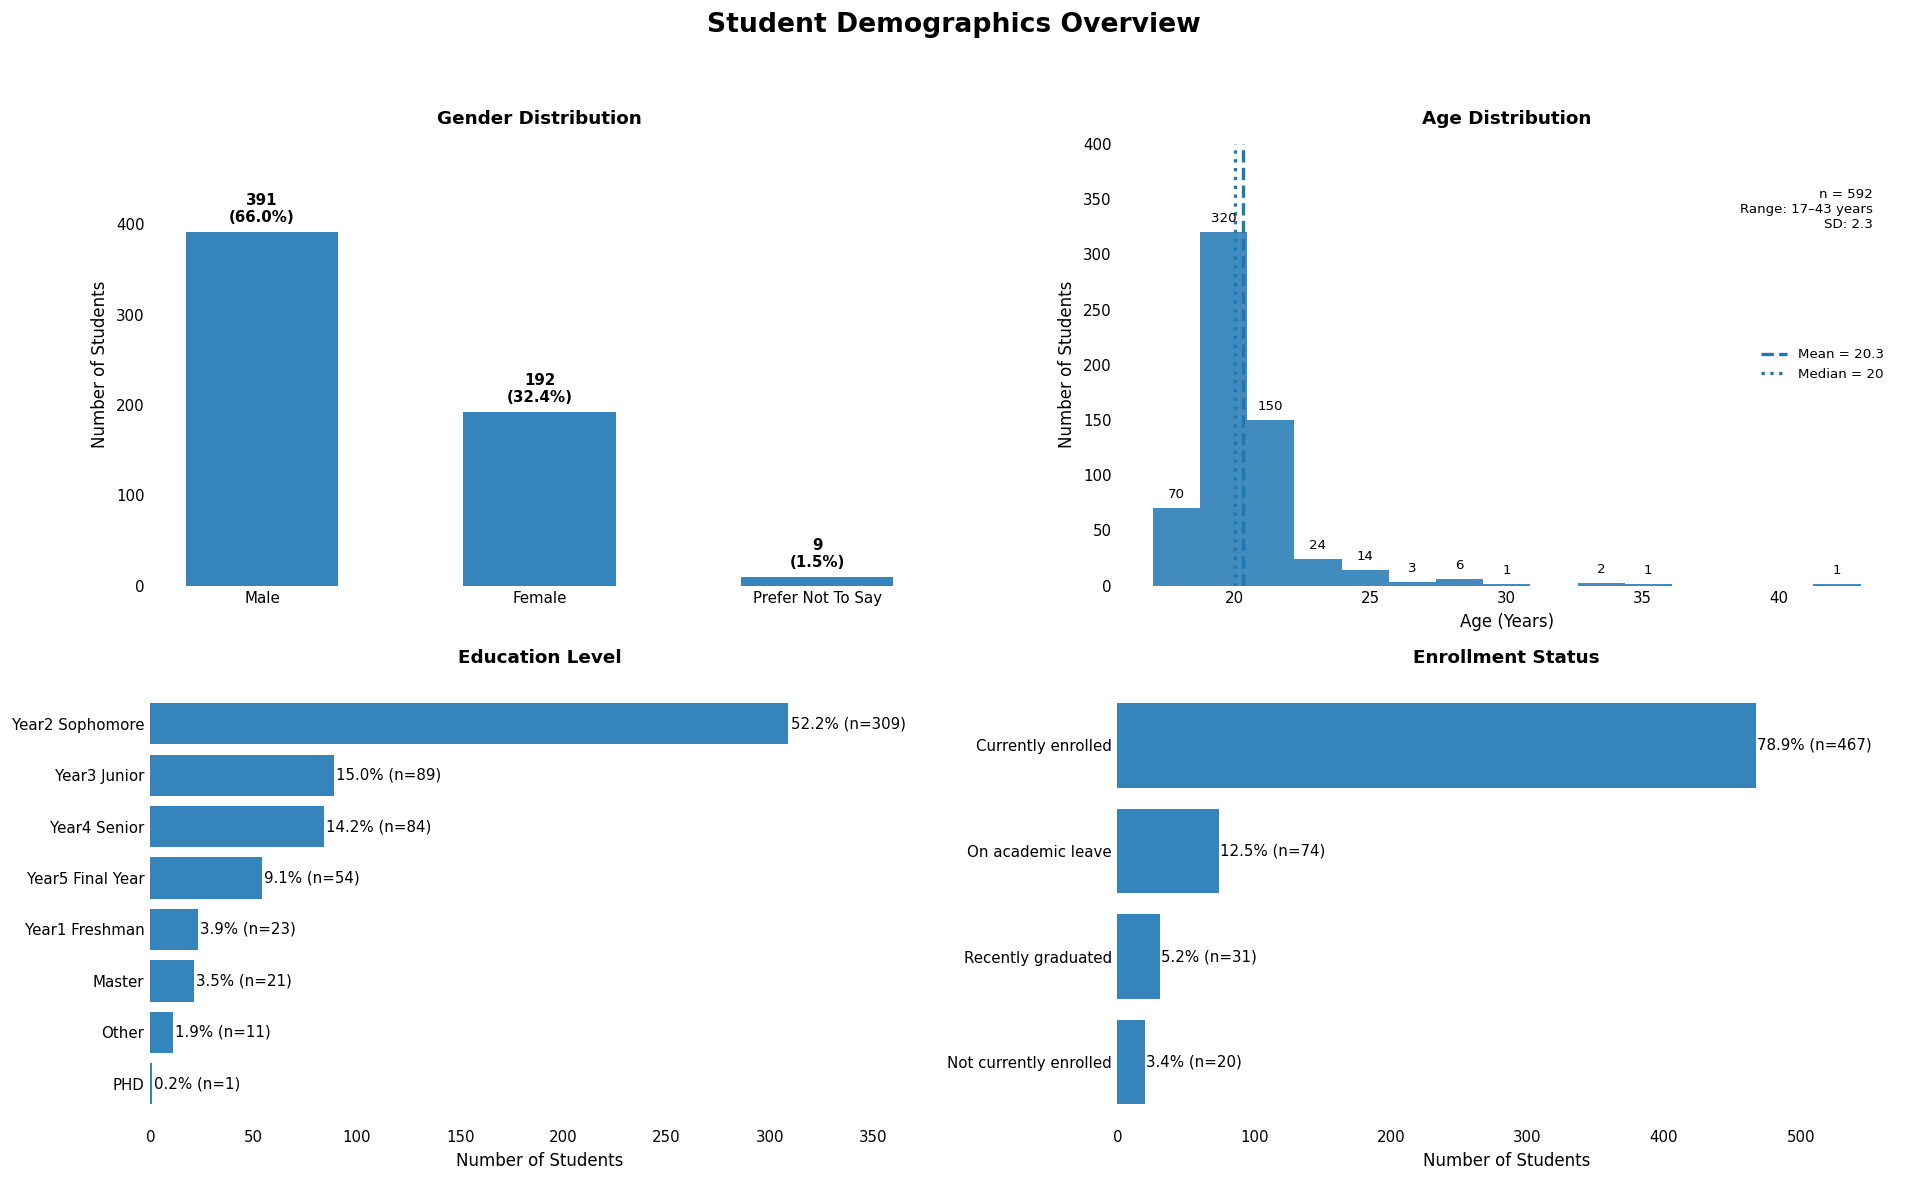


Demographic Summary
--------------------------------------------------
Total responses: 592
Age: mean=20.3, median=20, SD=2.3, range=17–43


In [59]:
# ── 3.1.1 Demographics Overview ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import textwrap

plt.style.use("default")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})

# Helper functions
def clean_axis(ax):
    """Remove plot bounding box and keep a clean thesis style."""
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", length=0)
    ax.grid(False)


def clean_label(x):
    """Clean long labels for plotting."""
    if pd.isna(x):
        return "Missing"
    return str(x)


def add_bar_labels_vertical(ax, bars, counts, total):
    """Add count and percent labels above vertical bars."""
    for bar, count in zip(bars, counts):
        pct = count / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.02,
            f"{int(count)}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )


def add_bar_labels_horizontal(ax, bars, counts, total):
    """Add percent and count labels beside horizontal bars."""
    for bar, count in zip(bars, counts):
        pct = count / total * 100
        width = bar.get_width()

        ax.text(
            width + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(count)})",
            va="center",
            fontsize=9
        )


# Columns
gender_col = col_cfg.get("gender", "gender")
age_col = col_cfg.get("age", "age")
edu_col = col_cfg.get("education_level", "education_level")
enroll_col = col_cfg.get("enrollment_status", "enrollment_status")

total_n = len(df)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Student Demographics Overview",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# ── Gender Distribution ──────────────────────────────────────────────────────
gender_counts = (
    df[gender_col]
    .fillna("Missing")
    .value_counts()
)

bars = axes[0, 0].bar(
    gender_counts.index.astype(str),
    gender_counts.values,
    width=0.55,
    alpha=0.9
)

add_bar_labels_vertical(
    axes[0, 0],
    bars,
    gender_counts.values,
    total_n
)

axes[0, 0].set_title("Gender Distribution", fontweight="bold", pad=12)
axes[0, 0].set_ylabel("Number of Students")
axes[0, 0].set_ylim(0, gender_counts.max() * 1.25)
clean_axis(axes[0, 0])


# ── Age Distribution ─────────────────────────────────────────────────────────
age_data = df[age_col].dropna()

hist_counts, bins, patches = axes[0, 1].hist(
    age_data,
    bins=15,
    alpha=0.85
)

axes[0, 1].axvline(
    age_data.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {age_data.mean():.1f}"
)

axes[0, 1].axvline(
    age_data.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {age_data.median():.0f}"
)

# Add count labels on histogram bars
for count, patch in zip(hist_counts, patches):
    if count > 0:
        axes[0, 1].text(
            patch.get_x() + patch.get_width() / 2,
            count + max(hist_counts) * 0.02,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=8
        )

axes[0, 1].set_title("Age Distribution", fontweight="bold", pad=12)
axes[0, 1].set_xlabel("Age (Years)")
axes[0, 1].set_ylabel("Number of Students")
axes[0, 1].legend(frameon=False, fontsize=8)

axes[0, 1].text(
    0.97,
    0.90,
    f"n = {age_data.shape[0]}\n"
    f"Range: {int(age_data.min())}–{int(age_data.max())} years\n"
    f"SD: {age_data.std():.1f}",
    transform=axes[0, 1].transAxes,
    ha="right",
    va="top",
    fontsize=8
)

axes[0, 1].set_ylim(0, max(hist_counts) * 1.25)
clean_axis(axes[0, 1])


# ── Education Level ──────────────────────────────────────────────────────────
edu_counts = (
    df[edu_col]
    .fillna("Missing")
    .value_counts()
    .sort_values(ascending=True)
)

edu_labels = [
    textwrap.fill(str(label).replace(" - ", "\n"), width=22)
    for label in edu_counts.index
]

bars = axes[1, 0].barh(
    edu_labels,
    edu_counts.values,
    alpha=0.9
)

add_bar_labels_horizontal(
    axes[1, 0],
    bars,
    edu_counts.values,
    total_n
)

axes[1, 0].set_title("Education Level", fontweight="bold", pad=12)
axes[1, 0].set_xlabel("Number of Students")
axes[1, 0].set_ylabel("")

axes[1, 0].set_xlim(0, edu_counts.max() * 1.22)
clean_axis(axes[1, 0])


# ── Enrollment Status ────────────────────────────────────────────────────────
enroll_counts = (
    df[enroll_col]
    .fillna("Missing")
    .value_counts()
    .sort_values(ascending=True)
)

enroll_labels = [
    textwrap.fill(str(label), width=24)
    for label in enroll_counts.index
]

bars = axes[1, 1].barh(
    enroll_labels,
    enroll_counts.values,
    alpha=0.9
)

add_bar_labels_horizontal(
    axes[1, 1],
    bars,
    enroll_counts.values,
    total_n
)

axes[1, 1].set_title("Enrollment Status", fontweight="bold", pad=12)
axes[1, 1].set_xlabel("Number of Students")
axes[1, 1].set_ylabel("")

axes[1, 1].set_xlim(0, enroll_counts.max() * 1.22)
clean_axis(axes[1, 1])


# ── Layout ───────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# ── Summary Statistics ───────────────────────────────────────────────────────
print("\nDemographic Summary")
print("-" * 50)
print(f"Total responses: {total_n}")
print(
    f"Age: mean={age_data.mean():.1f}, "
    f"median={age_data.median():.0f}, "
    f"SD={age_data.std():.1f}, "
    f"range={int(age_data.min())}–{int(age_data.max())}"
)

#### 2.1.2 Academic Profile

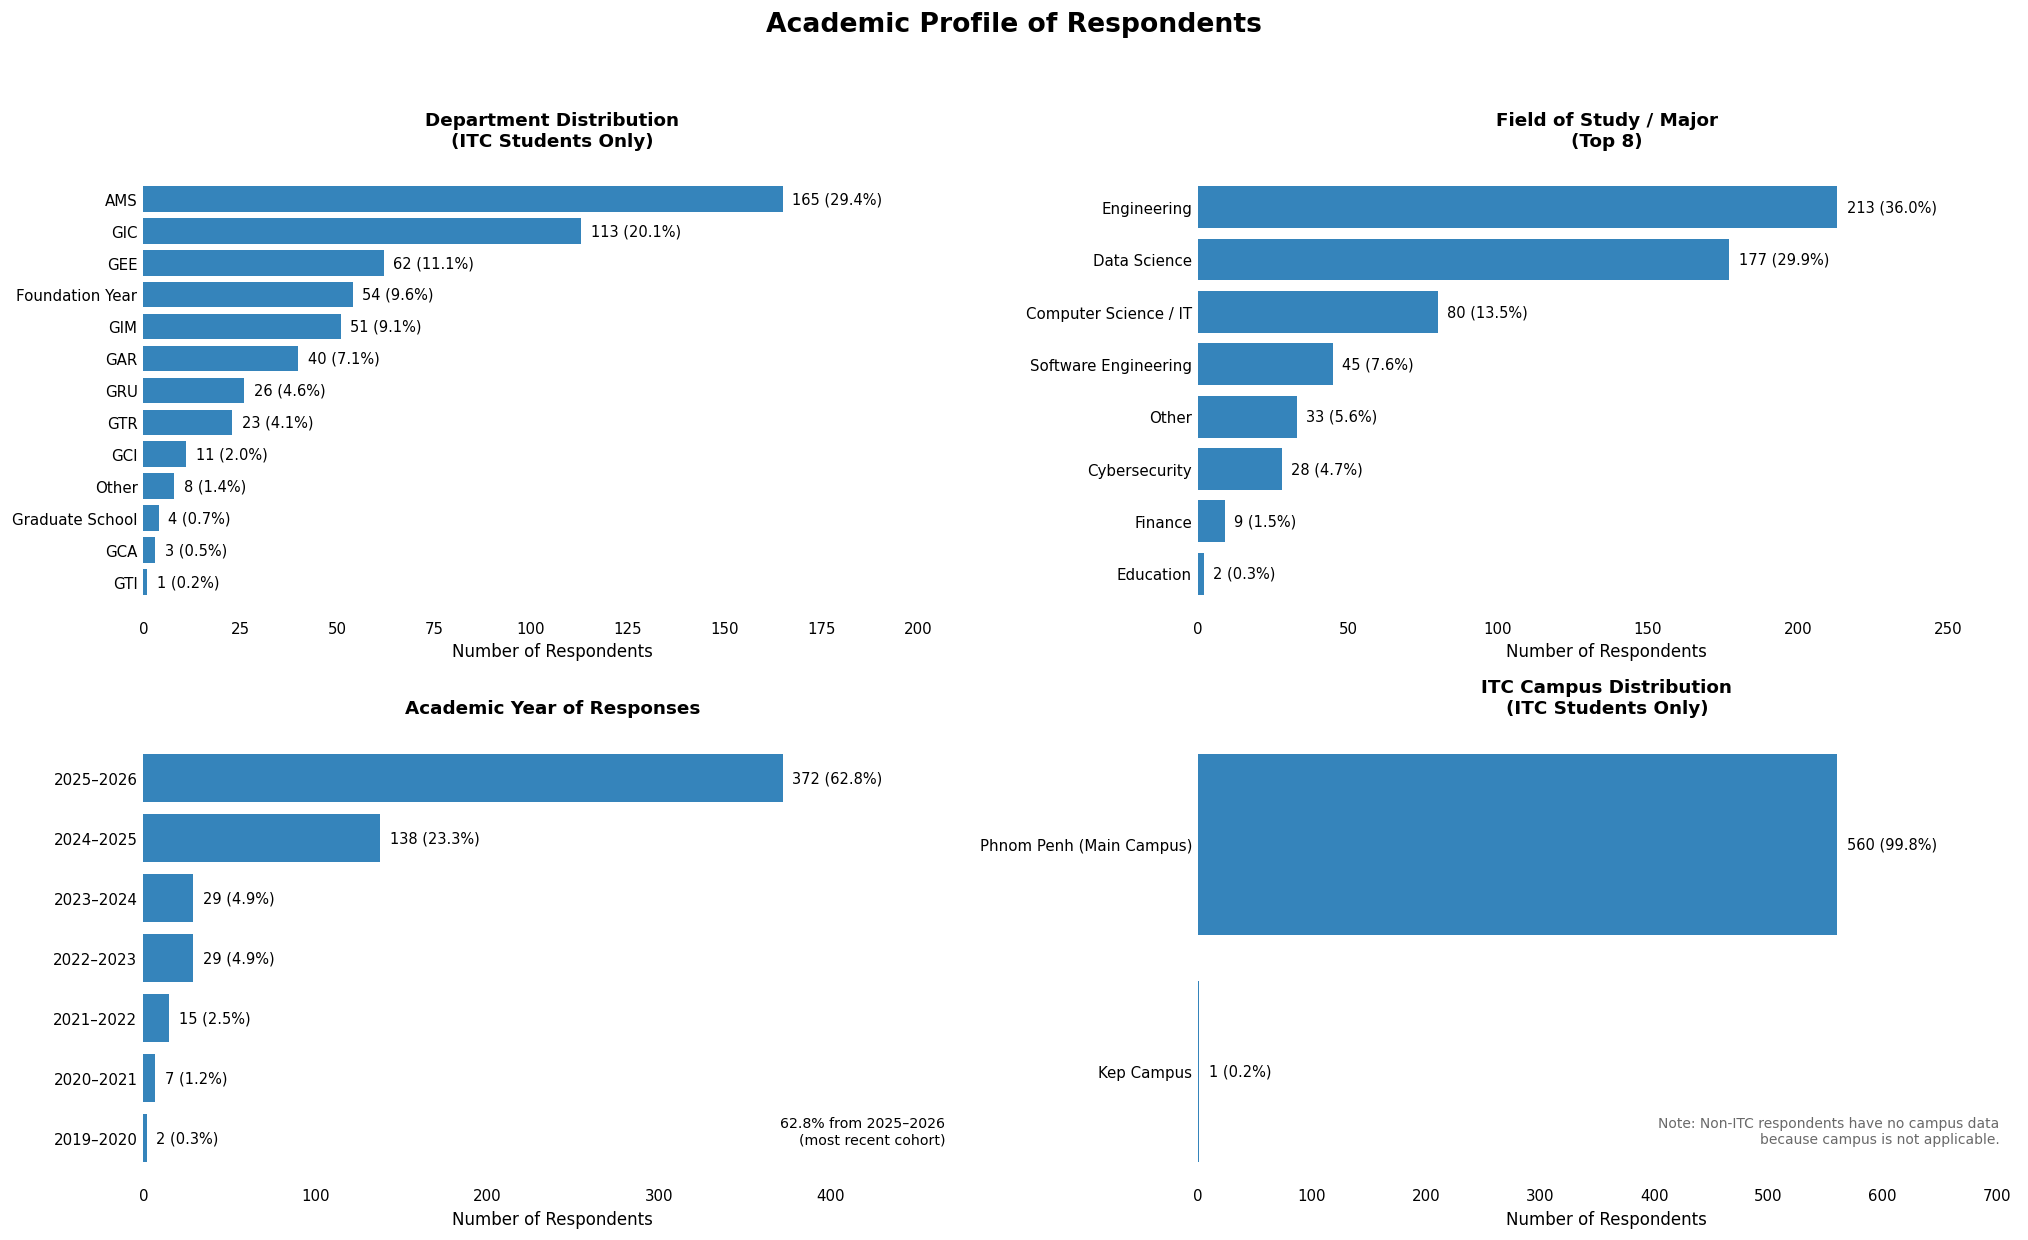

In [60]:
# ── 3.1.2 Academic profile ────────────────────────────────────────────────
import textwrap
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": plot_cfg.get("default_dpi", 120)
})


# ── Helper functions ──────────────────────────────────────────────────────
def clean_axis(ax):
    """Remove plot box and tick marks for a clean thesis style."""
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", length=0)
    ax.grid(False)


def wrap_list(labels, width=28):
    """Wrap long labels."""
    return [textwrap.fill(str(x), width=width) for x in labels]


def add_hbar_labels(ax, bars, counts, total, offset_ratio=0.015):
    """Add count and percent labels to horizontal bars."""
    max_count = max(counts) if len(counts) > 0 else 1
    offset = max_count * offset_ratio

    for bar, count in zip(bars, counts):
        pct = count / total * 100 if total > 0 else 0
        width = bar.get_width()

        ax.text(
            width + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{int(count)} ({pct:.1f}%)",
            va="center",
            fontsize=8.8
        )


def add_vbar_labels(ax, bars, counts, total):
    """Add count and percent labels above vertical bars."""
    max_count = max(counts) if len(counts) > 0 else 1

    for bar, count in zip(bars, counts):
        pct = count / total * 100 if total > 0 else 0

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max_count * 0.02,
            f"{int(count)}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=8.8
        )


# ── Columns ───────────────────────────────────────────────────────────────
dept_col = col_cfg.get("department", "department")
major_col = col_cfg.get("major", "major")
year_col = col_cfg.get("academic_year", "academic_year")
campus_col = col_cfg.get("itc_campus", "itc_campus")

fig, axes = plt.subplots(2, 2, figsize=(17, 10.5))

fig.suptitle(
    "Academic Profile of Respondents",
    fontsize=16,
    fontweight="bold",
    y=0.98
)


# ── Department Distribution ───────────────────────────────────────────────
dept_counts = (
    df[dept_col]
    .dropna()
    .value_counts()
    .sort_values(ascending=True)
)

dept_total = dept_counts.sum()

dept_labels = wrap_list(dept_counts.index, width=32)

bars = axes[0, 0].barh(
    dept_labels,
    dept_counts.values,
    alpha=0.90
)

add_hbar_labels(
    axes[0, 0],
    bars,
    dept_counts.values,
    dept_total
)

axes[0, 0].set_title(
    "Department Distribution\n(ITC Students Only)",
    fontweight="bold",
    pad=12
)

axes[0, 0].set_xlabel("Number of Respondents")
axes[0, 0].set_ylabel("")
axes[0, 0].set_xlim(0, dept_counts.max() * 1.28)
clean_axis(axes[0, 0])


# ── Field of Study / Major ────────────────────────────────────────────────
top_major_n = plot_cfg.get("top_major_n", 8)

major_counts = (
    df[major_col]
    .dropna()
    .value_counts()
    .head(top_major_n)
    .sort_values(ascending=True)
)

major_total = df[major_col].dropna().shape[0]

major_labels = wrap_list(major_counts.index, width=32)

bars = axes[0, 1].barh(
    major_labels,
    major_counts.values,
    alpha=0.90
)

add_hbar_labels(
    axes[0, 1],
    bars,
    major_counts.values,
    major_total
)

axes[0, 1].set_title(
    f"Field of Study / Major\n(Top {top_major_n})",
    fontweight="bold",
    pad=12
)

axes[0, 1].set_xlabel("Number of Respondents")
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlim(0, major_counts.max() * 1.28)
clean_axis(axes[0, 1])


# ── Academic Year of Responses ────────────────────────────────────────────
year_counts = (
    df[year_col]
    .dropna()
    .value_counts()
    .sort_values(ascending=True)
)

year_total = year_counts.sum()

year_labels = wrap_list(year_counts.index, width=22)

bars = axes[1, 0].barh(
    year_labels,
    year_counts.values,
    alpha=0.90
)

add_hbar_labels(
    axes[1, 0],
    bars,
    year_counts.values,
    year_total
)

axes[1, 0].set_title(
    "Academic Year of Responses",
    fontweight="bold",
    pad=12
)

axes[1, 0].set_xlabel("Number of Respondents")
axes[1, 0].set_ylabel("")
axes[1, 0].set_xlim(0, year_counts.max() * 1.28)

# Optional annotation for latest cohort
latest_label = "2025-2026"
latest_match = [
    idx for idx in year_counts.index
    if latest_label in str(idx) or "2025–2026" in str(idx)
]

if latest_match:
    latest_count = int(year_counts.loc[latest_match[0]])
    latest_pct = latest_count / year_total * 100

    axes[1, 0].text(
        0.98,
        0.08,
        f"{latest_pct:.1f}% from 2025–2026\n(most recent cohort)",
        transform=axes[1, 0].transAxes,
        ha="right",
        va="bottom",
        fontsize=8.5
    )

clean_axis(axes[1, 0])


# ── ITC Campus Distribution ───────────────────────────────────────────────
campus_counts = (
    df[campus_col]
    .dropna()
    .value_counts()
    .sort_values(ascending=True)
)

campus_total = campus_counts.sum()

campus_labels = [
    str(label).replace("ITC ", "")
    for label in campus_counts.index
]

bars = axes[1, 1].barh(
    campus_labels,
    campus_counts.values,
    alpha=0.90
)

add_hbar_labels(
    axes[1, 1],
    bars,
    campus_counts.values,
    campus_total
)

axes[1, 1].set_title(
    "ITC Campus Distribution\n(ITC Students Only)",
    fontweight="bold",
    pad=12
)

axes[1, 1].set_xlabel("Number of Respondents")
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlim(0, campus_counts.max() * 1.28)

axes[1, 1].text(
    0.98,
    0.08,
    "Note: Non-ITC respondents have no campus data\nbecause campus is not applicable.",
    transform=axes[1, 1].transAxes,
    ha="right",
    va="bottom",
    fontsize=8.3,
    color="dimgray"
)

clean_axis(axes[1, 1])


# ── Layout ────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### 2.1.3 Technology access

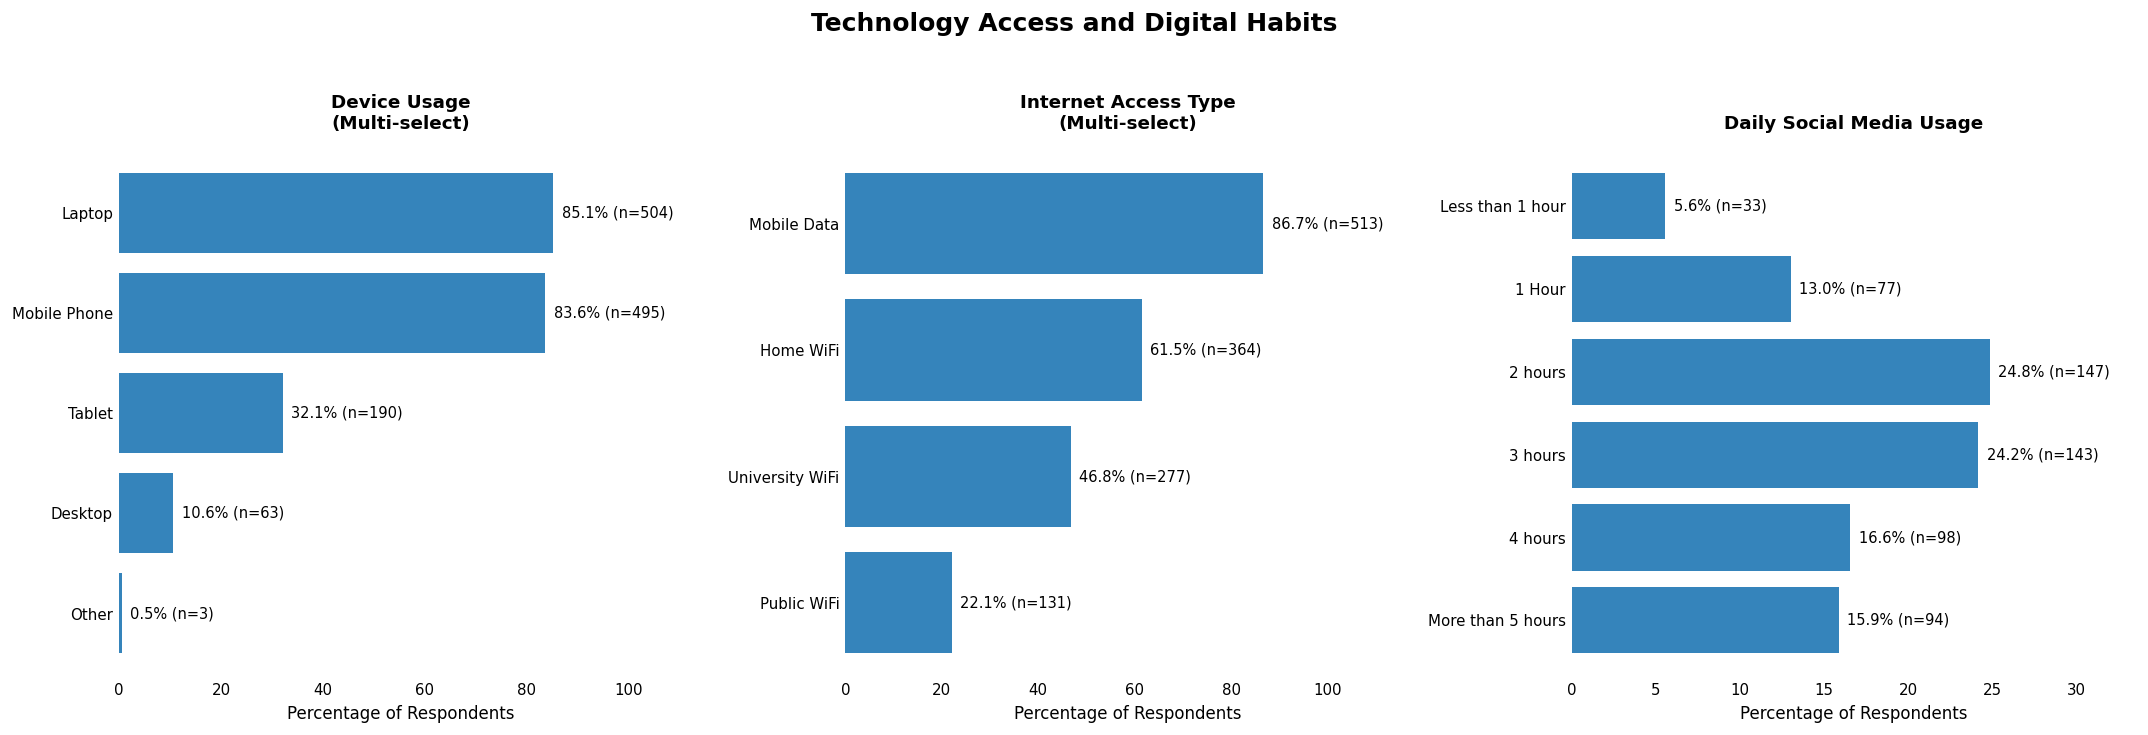

Median social media usage: 4 (configured scale from 1 to 6)


In [66]:
# ── 3.1.3 Technology access ───────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": plot_cfg.get("default_dpi", 120)
})


# ── Helper functions ──────────────────────────────────────────────────────
def clean_axis(ax):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", length=0)
    ax.grid(False)


def add_hbar_labels(ax, bars, values, counts, label_fmt="percent_count"):
    max_val = max(values) if len(values) > 0 else 1
    offset = max_val * 0.02

    for bar, val, count in zip(bars, values, counts):
        if label_fmt == "percent_count":
            txt = f"{val:.1f}% (n={int(count)})"
        else:
            txt = f"{int(count)}"

        ax.text(
            val + offset,
            bar.get_y() + bar.get_height() / 2,
            txt,
            va="center",
            fontsize=8.8
        )


# ── Figure layout ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6.2))

fig.suptitle(
    "Technology Access and Digital Habits",
    fontsize=15,
    fontweight="bold",
    y=0.98
)

total_n = len(df)


# ── Devices ───────────────────────────────────────────────────────────────
device_group = tech_cfg.get("device_group", "devices")
dev_cols = [c for c in tech_cfg.get("device_order", multi_groups.get(device_group, [])) if c in df.columns]
dev_label_map = tech_cfg.get("device_labels", {})

dev_labels = [dev_label_map.get(c, pl(c)) for c in dev_cols]
dev_counts = [df[c].fillna(0).sum() for c in dev_cols]
dev_pcts = [df[c].fillna(0).mean() * 100 for c in dev_cols]

dev_data = sorted(
    zip(dev_labels, dev_counts, dev_pcts),
    key=lambda x: x[2],
    reverse=False
)

dev_labels_s = [x[0] for x in dev_data]
dev_counts_s = [x[1] for x in dev_data]
dev_pcts_s = [x[2] for x in dev_data]

bars = axes[0].barh(
    dev_labels_s,
    dev_pcts_s,
    alpha=0.9
)

add_hbar_labels(
    axes[0],
    bars,
    dev_pcts_s,
    dev_counts_s
)

axes[0].set_xlim(0, max(dev_pcts_s) * 1.30 if dev_pcts_s else 100)
axes[0].set_title(
    "Device Usage\n(Multi-select)",
    fontweight="bold",
    pad=12
)
axes[0].set_xlabel("Percentage of Respondents")
axes[0].set_ylabel("")
clean_axis(axes[0])


# ── Internet Access ───────────────────────────────────────────────────────
internet_group = tech_cfg.get("internet_group", "internet_access")
inet_cols = [c for c in tech_cfg.get("internet_order", multi_groups.get(internet_group, [])) if c in df.columns]
inet_label_map = tech_cfg.get("internet_labels", {})

inet_labels = [inet_label_map.get(c, pl(c)) for c in inet_cols]
inet_counts = [df[c].fillna(0).sum() for c in inet_cols]
inet_pcts = [df[c].fillna(0).mean() * 100 for c in inet_cols]

inet_data = sorted(
    zip(inet_labels, inet_counts, inet_pcts),
    key=lambda x: x[2],
    reverse=False
)

inet_labels_s = [x[0] for x in inet_data]
inet_counts_s = [x[1] for x in inet_data]
inet_pcts_s = [x[2] for x in inet_data]

bars = axes[1].barh(
    inet_labels_s,
    inet_pcts_s,
    alpha=0.9
)

add_hbar_labels(
    axes[1],
    bars,
    inet_pcts_s,
    inet_counts_s
)

axes[1].set_xlim(0, max(inet_pcts_s) * 1.35 if inet_pcts_s else 100)
axes[1].set_title(
    "Internet Access Type\n(Multi-select)",
    fontweight="bold",
    pad=12
)
axes[1].set_xlabel("Percentage of Respondents")
axes[1].set_ylabel("")

mobile_col = "inet_mobile_data"
mobile_data_count = int(df[mobile_col].fillna(0).sum()) if mobile_col in df.columns else 0
mobile_data_pct = df[mobile_col].fillna(0).mean() * 100 if mobile_col in df.columns else 0


clean_axis(axes[1])


# ── Social Media Hours ────────────────────────────────────────────────────
sm_col = col_cfg.get("social_media_hours", "social_media_hours")
sm_order = ordinal_orders.get(sm_col, [])

sm_counts = (
    df[sm_col]
    .value_counts()
    .reindex(sm_order, fill_value=0)
)

sm_total = df[sm_col].notna().sum()
sm_pcts = (sm_counts / sm_total * 100).fillna(0)

bars = axes[2].barh(
    sm_order,
    sm_pcts.values,
    alpha=0.9
)

# Keep logical order from top to bottom
axes[2].invert_yaxis()

for bar, pct, count in zip(bars, sm_pcts.values, sm_counts.values):
    axes[2].text(
        pct + max(sm_pcts.values) * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}% (n={int(count)})",
        va="center",
        fontsize=8.8
    )

axes[2].set_title(
    "Daily Social Media Usage",
    fontweight="bold",
    pad=12
)
axes[2].set_xlabel("Percentage of Respondents")
axes[2].set_ylabel("")
axes[2].set_xlim(0, max(sm_pcts.values) * 1.35 if len(sm_pcts) > 0 else 100)

sm_mapping = tech_cfg.get("social_media_numeric_map", {})
sm_numeric = df[sm_col].map(sm_mapping)
heavy_min_score = tech_cfg.get("heavy_social_media_min_score", 5)
heavy_count = int(sm_numeric.ge(heavy_min_score).sum())
heavy_pct = sm_numeric.ge(heavy_min_score).mean() * 100




clean_axis(axes[2])


# ── Layout ────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# ── Summary printout ──────────────────────────────────────────────────────
print(
    f"Median social media usage: {sm_numeric.median():.0f} "
    f"(configured scale from {min(sm_mapping.values())} to {max(sm_mapping.values())})"
)



### 2.1.4  Non-ITC Student Demographic Profile

ITC: n=561  |  Non-ITC: n=31


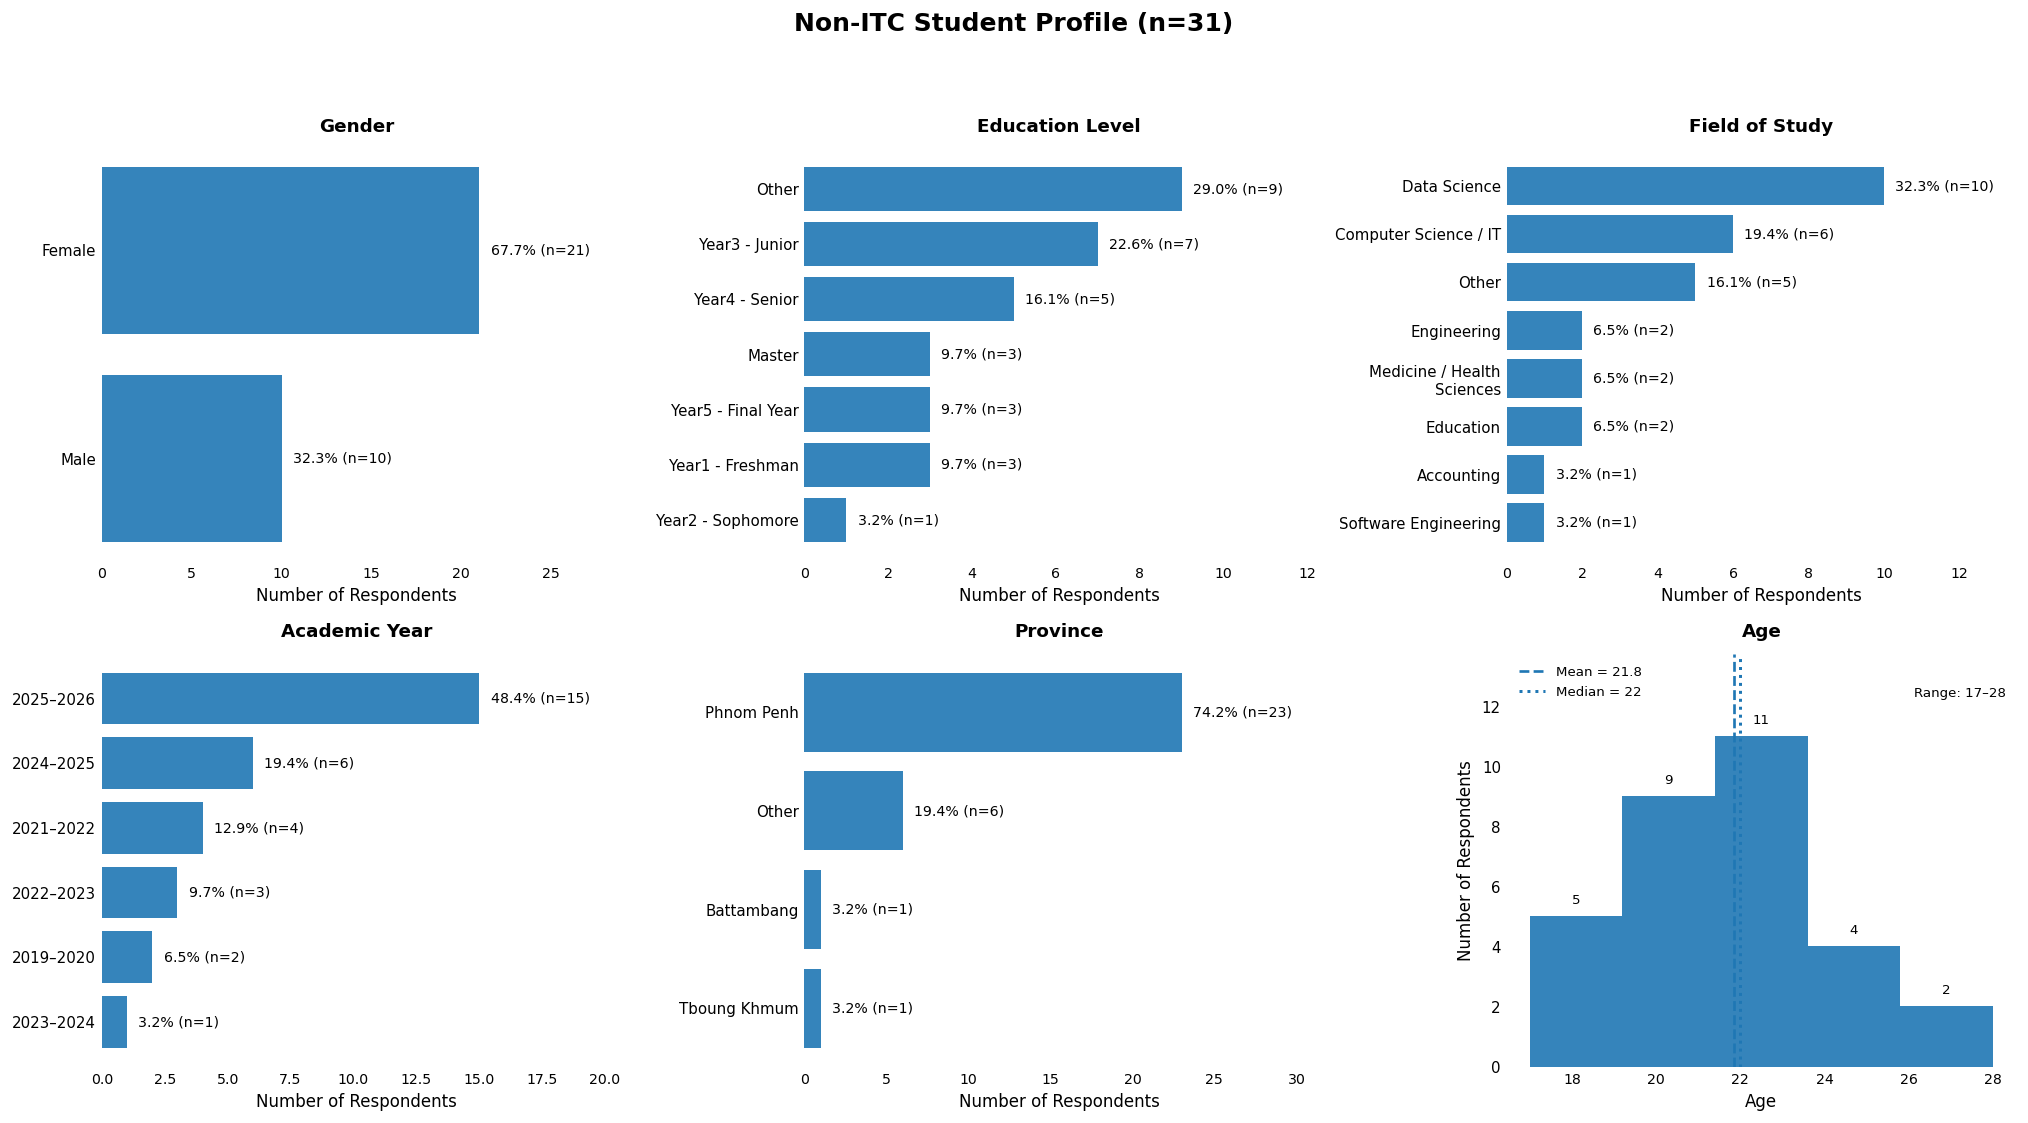


Non-ITC: Female respondents account for 67.7% compared with 30.5% among ITC students.
Non-ITC: The sample is mainly concentrated in Data Science, Computer Science, and related technology fields.
Note: faculty, department, and itc_campus are structurally null for Non-ITC students because these fields are only applicable to ITC respondents.


In [68]:
# ── 3.1.4 Non-ITC student profile ─────────────────────────────────────────
import textwrap
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 9,
    "figure.dpi": plot_cfg.get("default_dpi", 120)
})


# ── Helper functions ──────────────────────────────────────────────────────
def clean_axis(ax):
    """Remove bounding box, grid, and tick marks."""
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", length=0)


def wrap_one(label, width=24):
    """Wrap long label text."""
    return textwrap.fill(str(label), width=width)


def add_hbar_labels(ax, bars, counts, total):
    """Add percent and count labels beside horizontal bars."""
    max_count = max(counts) if len(counts) > 0 else 1
    offset = max_count * 0.03

    for bar, count in zip(bars, counts):
        pct = count / total * 100 if total > 0 else 0

        ax.text(
            bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(count)})",
            va="center",
            fontsize=8.5
        )


# ── Split ITC and Non-ITC students ─────────────────────────────────────────
itc_flag_col = group_cfg.get("itc_flag_col", "is_itc_student")

itc = df[df[itc_flag_col] == True]
non_itc = df[df[itc_flag_col] == False]

print(f"ITC: n={len(itc)}  |  Non-ITC: n={len(non_itc)}")


# ── Panel configuration ───────────────────────────────────────────────────
panels = eda_cfg.get("non_itc_profile", {}).get("panels", [])
top_category_n = eda_cfg.get("non_itc_profile", {}).get("top_category_n", 8)

fig, axes = plt.subplots(2, 3, figsize=(17, 9.5))
axes_flat = axes.flatten()

fig.suptitle(
    f"Non-ITC Student Profile (n={len(non_itc)})",
    fontsize=15,
    fontweight="bold",
    y=0.98
)


# ── Plot each panel ───────────────────────────────────────────────────────
for ax, panel in zip(axes_flat, panels):

    # Panel may be (col, title) or (col, title, color)
    if len(panel) == 2:
        col, title = panel
    else:
        col, title, _ = panel

    if col not in non_itc.columns:
        ax.set_visible(False)
        continue

    data = non_itc[col].dropna()

    if data.empty:
        ax.set_visible(False)
        continue

    # ── Age histogram ─────────────────────────────────────────────────────
    if col == "age":
        age_data = data.astype(float)

        n_bins = min(8, max(3, int(np.sqrt(len(age_data)))))

        counts, bins, patches = ax.hist(
            age_data,
            bins=n_bins,
            alpha=0.90
        )

        mean_age = age_data.mean()
        median_age = age_data.median()

        ax.axvline(
            mean_age,
            linestyle="--",
            linewidth=1.6,
            label=f"Mean = {mean_age:.1f}"
        )

        ax.axvline(
            median_age,
            linestyle=":",
            linewidth=1.8,
            label=f"Median = {median_age:.0f}"
        )

        # Add count labels to histogram bars
        max_count = counts.max() if len(counts) > 0 else 1

        for count, patch in zip(counts, patches):
            if count > 0:
                ax.text(
                    patch.get_x() + patch.get_width() / 2,
                    count + max_count * 0.03,
                    f"{int(count)}",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

        ax.set_title(title, fontweight="bold", pad=10)
        ax.set_xlabel("Age")
        ax.set_ylabel("Number of Respondents")
        ax.set_ylim(0, max_count * 1.25)

        ax.text(
            0.98,
            0.92,
            f"Range: {int(age_data.min())}–{int(age_data.max())}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8
        )

        ax.legend(frameon=False, fontsize=8)
        clean_axis(ax)

    # ── Categorical horizontal bar charts ─────────────────────────────────
    else:
        counts = (
            data.astype(str)
            .value_counts()
            .head(top_category_n)
            .sort_values(ascending=True)
        )

        total_valid = data.shape[0]

        labels = [
            wrap_one(label, width=24)
            for label in counts.index
        ]

        bars = ax.barh(
            labels,
            counts.values,
            alpha=0.90
        )

        add_hbar_labels(
            ax,
            bars,
            counts.values,
            total_valid
        )

        ax.set_title(
            title,
            fontweight="bold",
            pad=10
        )

        ax.set_xlabel("Number of Respondents")
        ax.set_ylabel("")
        ax.set_xlim(0, counts.max() * 1.35)

        clean_axis(ax)


# ── Hide unused panels ────────────────────────────────────────────────────
for ax in axes_flat[len(panels):]:
    ax.set_visible(False)


# ── Layout ────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


# ── Summary statistics ────────────────────────────────────────────────────
non_itc_female_pct = (
    non_itc["gender"]
    .astype(str)
    .str.lower()
    .eq("female")
    .mean() * 100
)

itc_female_pct = (
    itc["gender"]
    .astype(str)
    .str.lower()
    .eq("female")
    .mean() * 100
)

print(
    f"\nNon-ITC: Female respondents account for {non_itc_female_pct:.1f}% "
    f"compared with {itc_female_pct:.1f}% among ITC students."
)

print(
    "Non-ITC: The sample is mainly concentrated in Data Science, Computer Science, "
    "and related technology fields."
)

print(
    "Note: faculty, department, and itc_campus are structurally null for Non-ITC students "
    "because these fields are only applicable to ITC respondents."
)

#### 2.1.5 Distribution of Student Responses (Likert Scale Analysis)

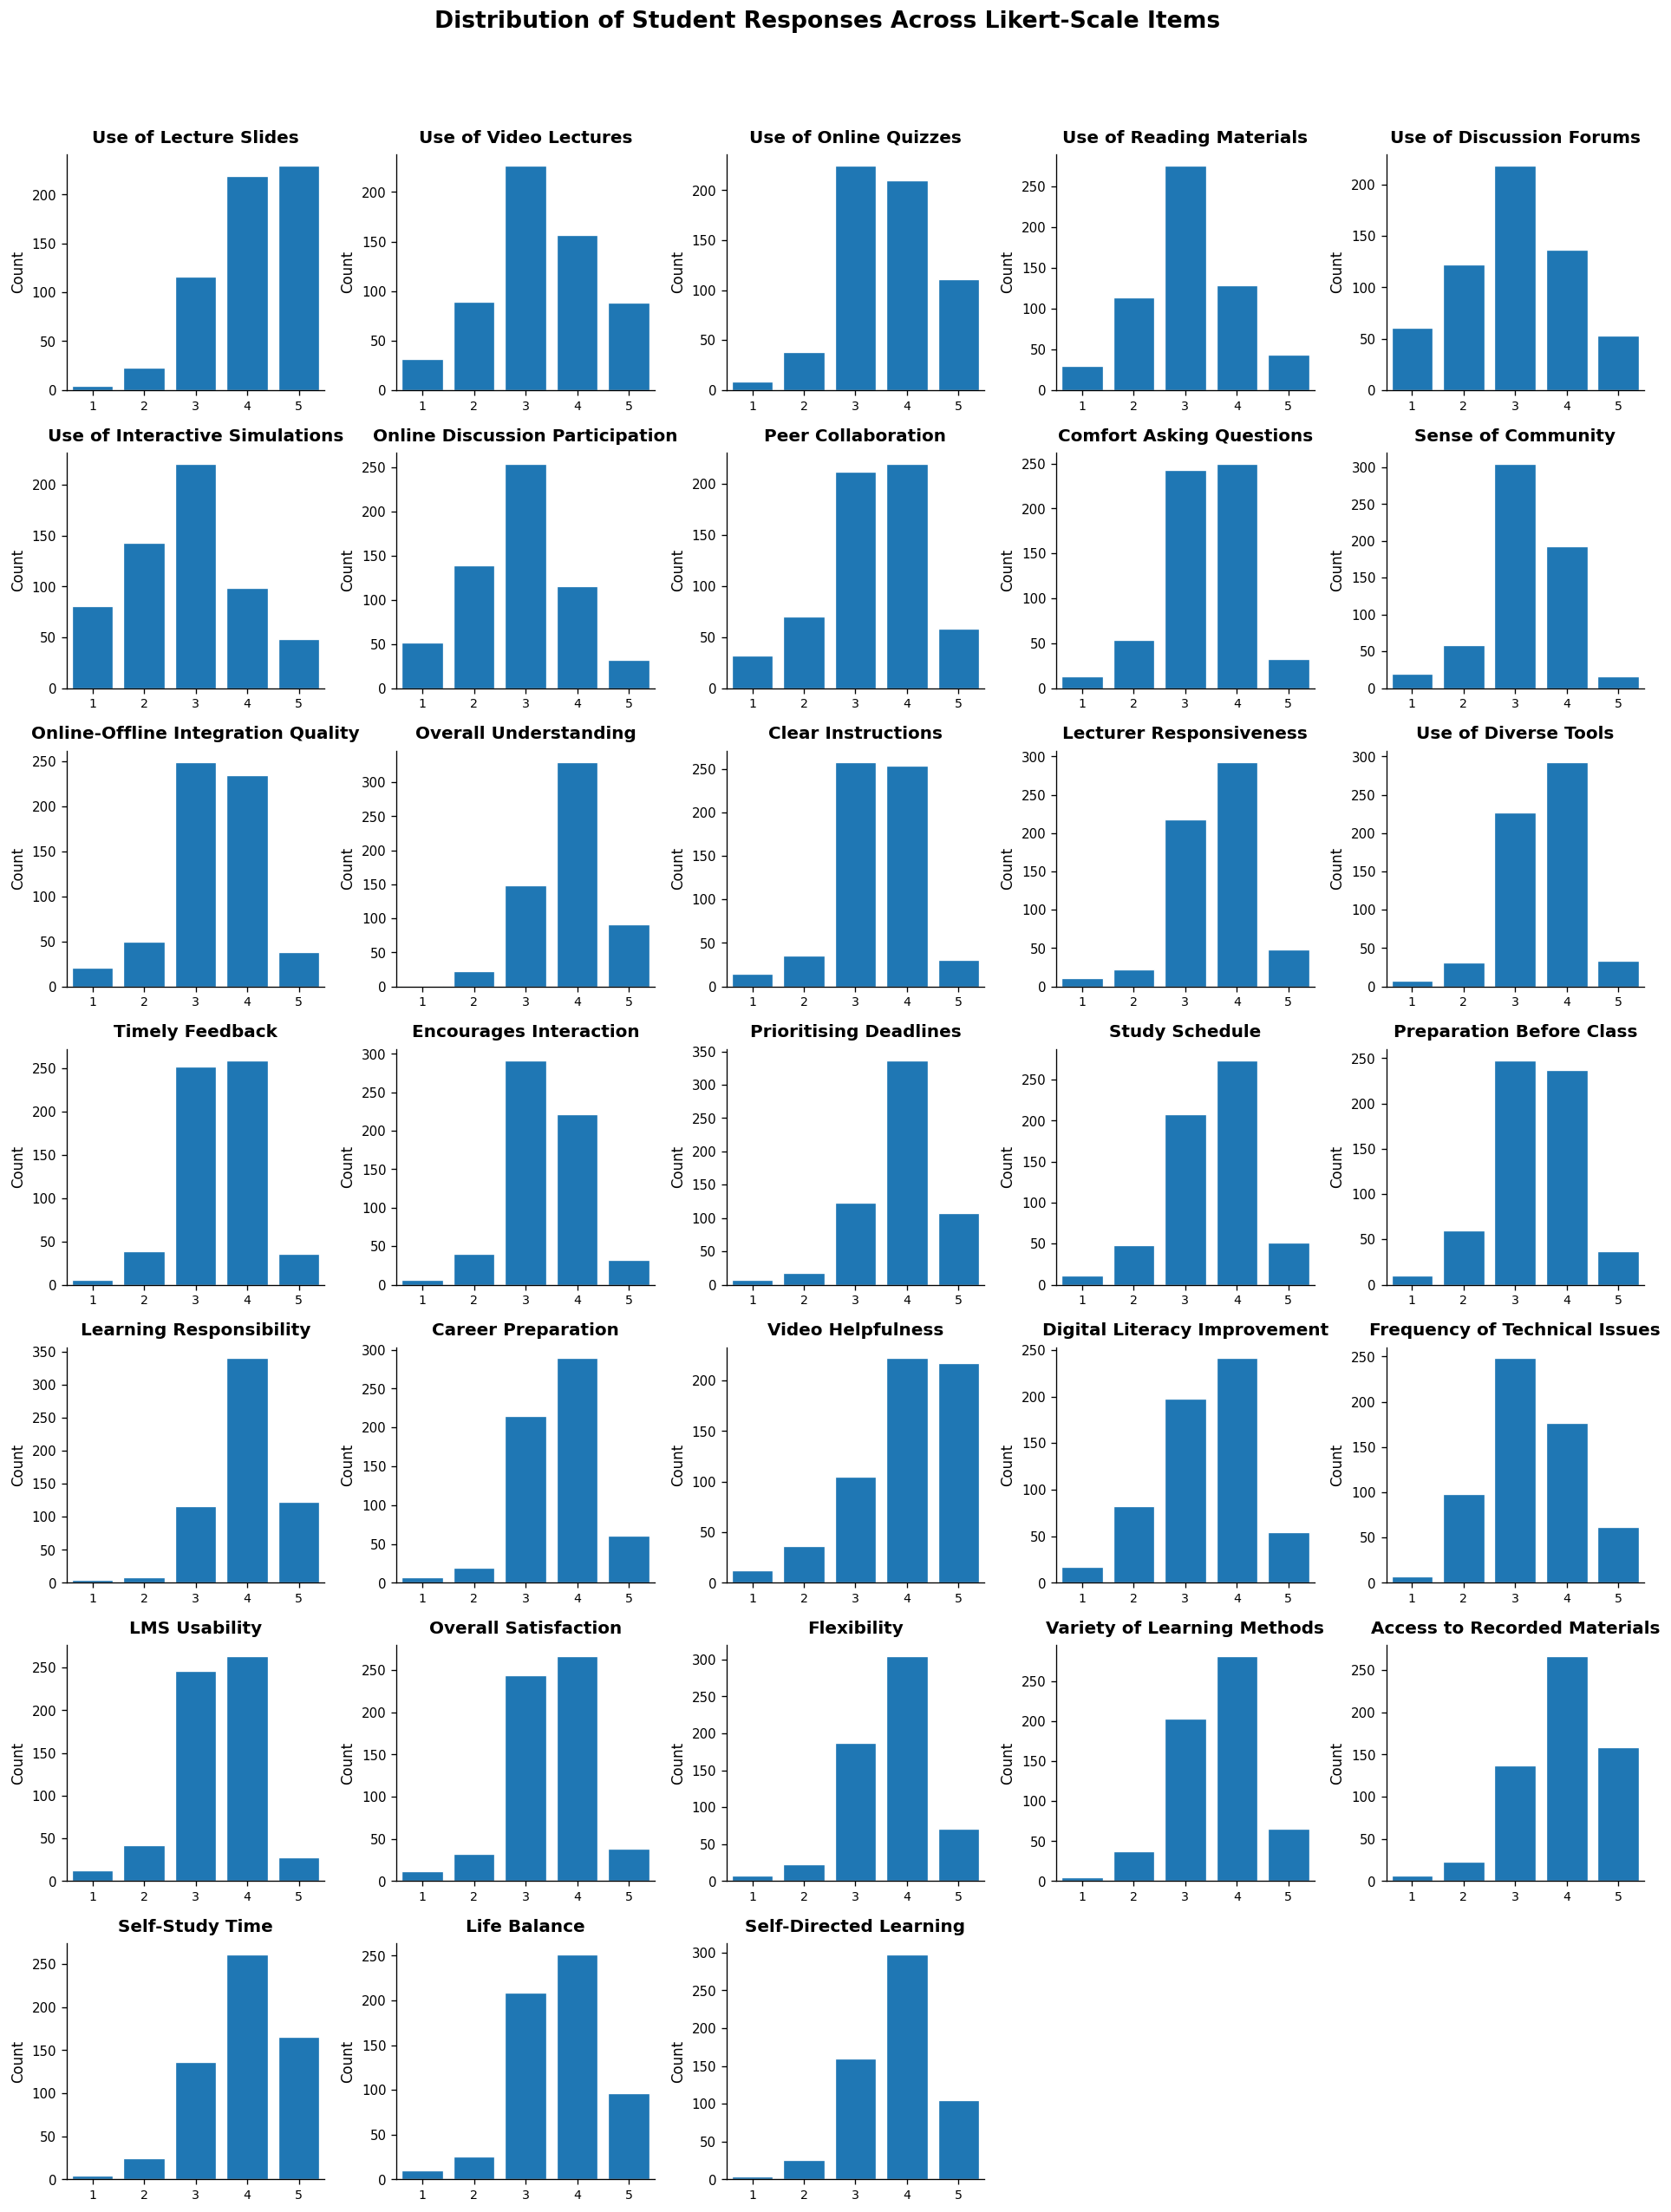

In [27]:
# ── Distribution of Likert-scale responses ────────────────────────────────
import math
import matplotlib.pyplot as plt

cols = ordinal_cols
n_cols = likert_cfg.get("facet_columns", 5)
n_rows = math.ceil(len(cols) / n_cols)
scale_min = likert_cfg.get("scale_min", 1)
scale_max = likert_cfg.get("scale_max", 5)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 3)
)

axes = axes.flatten()

fig.suptitle(
    "Distribution of Student Responses Across Likert-Scale Items",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

for i, col in enumerate(cols):
    vc = df[col].value_counts().sort_index()

    axes[i].bar(
        vc.index,
        vc.values,
        edgecolor="white",
        linewidth=0.8
    )

    axes[i].set_title(
        pl(col),
        fontsize=12,
        fontweight="bold",
        pad=8
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].set_xticks(list(range(scale_min, scale_max + 1)))
    axes[i].set_xlim(scale_min - 0.5, scale_max + 0.5)

    axes[i].grid(False)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


### 2.2 Bivariate Analysis

#### 2.2.1  Satisfaction by Education Level & Enrollment Status

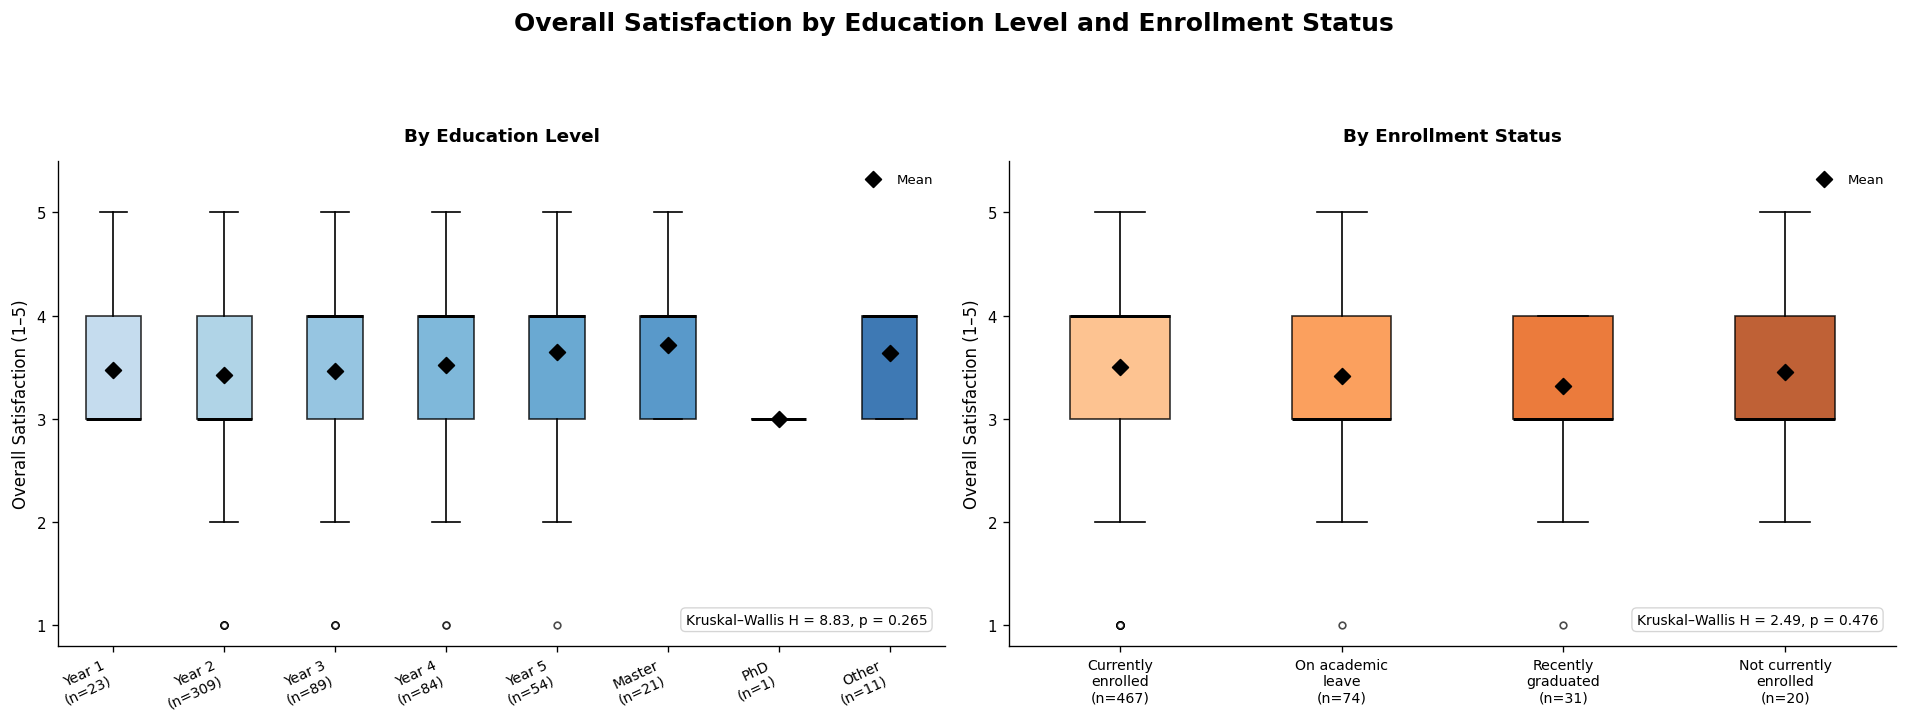


Kruskal–Wallis Test Summary
------------------------------------------------------------
Education level: Kruskal–Wallis H = 8.83, p = 0.265
Enrollment status: Kruskal–Wallis H = 2.49, p = 0.476


In [69]:
# ── 3.2.1 Satisfaction by education level and enrollment status ─────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from scipy.stats import kruskal

plt.style.use("default")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 9,
    "figure.dpi": plot_cfg.get("default_dpi", 120)
})


# ── Helper functions ───────────────────────────────────────────────────────
def wrap_label(label, width=16):
    return textwrap.fill(str(label), width=width)


def clean_edu_label(label):
    label = str(label)
    label = label.replace("Year1", "Year 1")
    label = label.replace("Year2", "Year 2")
    label = label.replace("Year3", "Year 3")
    label = label.replace("Year4", "Year 4")
    label = label.replace("Year5", "Year 5")
    label = label.replace("PHD", "PhD")
    return label


def clean_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def kruskal_text(groups):
    valid_groups = [g for g in groups if len(g) > 0]

    if len(valid_groups) >= 2:
        stat, p = kruskal(*valid_groups)
        return f"Kruskal–Wallis H = {stat:.2f}, p = {p:.3f}"
    else:
        return "Kruskal–Wallis test not available"


def plot_satisfaction_boxplot(ax, data_groups, group_labels, title, box_colors):
    bp = ax.boxplot(
        data_groups,
        labels=group_labels,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.8),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="white",
            markeredgecolor="black",
            alpha=0.7
        )
    )

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.80)

    means = [
        np.mean(g) if len(g) > 0 else np.nan
        for g in data_groups
    ]

    ax.scatter(
        range(1, len(means) + 1),
        means,
        color="black",
        zorder=5,
        s=45,
        marker="D",
        label="Mean"
    )

    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_ylabel("Overall Satisfaction (1–5)")
    ax.set_ylim(0.8, 5.5)

    ax.annotate(
        kruskal_text(data_groups),
        xy=(0.98, 0.04),
        xycoords="axes fraction",
        ha="right",
        va="bottom",
        fontsize=8.3,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgray",
            linewidth=0.8,
            alpha=0.95
        )
    )

    ax.legend(
        fontsize=8,
        frameon=False,
        loc="upper right"
    )

    clean_axis(ax)


# ── Column setup ───────────────────────────────────────────────────────────
rating_col = biv_cfg.get(
    "rating_col",
    col_cfg.get("overall_satisfaction", "overall_satisfaction")
)

education_col = col_cfg.get("education_level", "education_level")
enrollment_col = col_cfg.get("enrollment_status", "enrollment_status")

# Make sure satisfaction is numeric ordinal 1–5
plot_df = df.copy()
plot_df[rating_col] = pd.to_numeric(plot_df[rating_col], errors="coerce")


# ── Figure layout ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))

fig.suptitle(
    "Overall Satisfaction by Education Level and Enrollment Status",
    fontsize=15,
    fontweight="bold",
    y=1.03
)


# ── Education level boxplot ────────────────────────────────────────────────
edu_order_full = biv_cfg.get("education_order", [])

if edu_order_full:
    edu_order_present = [
        e for e in edu_order_full
        if e in plot_df[education_col].dropna().unique()
    ]
else:
    edu_order_present = (
        plot_df[education_col]
        .dropna()
        .value_counts()
        .index
        .tolist()
    )

data_edu = []
labels_edu = []

for e in edu_order_present:
    values = (
        plot_df.loc[plot_df[education_col] == e, rating_col]
        .dropna()
        .values
    )

    if len(values) > 0:
        data_edu.append(values)

        short_label = e.split(" - ")[0] if " - " in str(e) else e
        labels_edu.append(
            f"{clean_edu_label(short_label)}\n(n={len(values)})"
        )

colors_edu = plt.cm.Blues(
    np.linspace(0.30, 0.85, max(len(data_edu), 1))
)

plot_satisfaction_boxplot(
    ax=axes[0],
    data_groups=data_edu,
    group_labels=labels_edu,
    title="By Education Level",
    box_colors=colors_edu
)

plt.setp(
    axes[0].get_xticklabels(),
    rotation=25,
    ha="right"
)


# ── Enrollment status boxplot ──────────────────────────────────────────────
enroll_order = (
    plot_df[enrollment_col]
    .dropna()
    .value_counts()
    .index
    .tolist()
)

data_enroll = []
labels_enroll = []

for s in enroll_order:
    values = (
        plot_df.loc[plot_df[enrollment_col] == s, rating_col]
        .dropna()
        .values
    )

    if len(values) > 0:
        data_enroll.append(values)
        labels_enroll.append(
            f"{wrap_label(s, width=16)}\n(n={len(values)})"
        )

colors_enroll = plt.cm.Oranges(
    np.linspace(0.35, 0.85, max(len(data_enroll), 1))
)

plot_satisfaction_boxplot(
    ax=axes[1],
    data_groups=data_enroll,
    group_labels=labels_enroll,
    title="By Enrollment Status",
    box_colors=colors_enroll
)

plt.setp(
    axes[1].get_xticklabels(),
    rotation=0,
    ha="center"
)


# ── Layout ─────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# ── Print statistical test summary ─────────────────────────────────────────
print("\nKruskal–Wallis Test Summary")
print("-" * 60)
print(f"Education level: {kruskal_text(data_edu)}")
print(f"Enrollment status: {kruskal_text(data_enroll)}")

The purpose is to see whether students from different academic groups show different satisfaction levels.

Across enrollment statuses, overall satisfaction remains mostly concentrated between 3 and 4. Recently graduated respondents show the lowest mean satisfaction score, although the difference appears modest. This may suggest that students who have already completed their studies evaluate the blended learning experience slightly more critically than currently enrolled students.
Kruskal–Wallis p = 0.247.This means the difference in satisfaction across education levels is not statistically significant.

#### 2.2.2  Learning Format Preferences

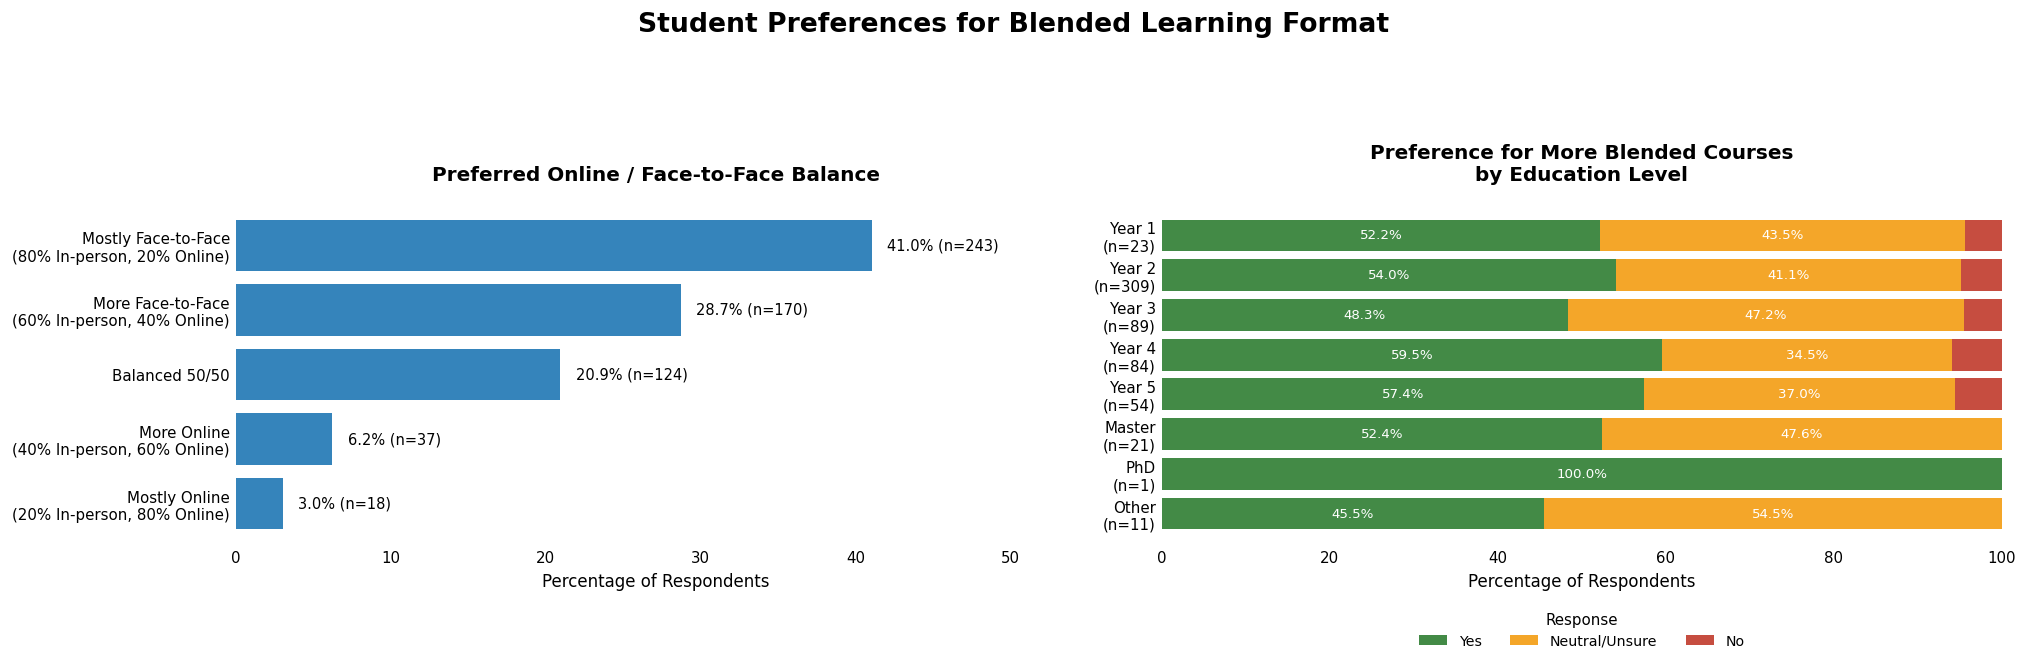

In [75]:
# ── 3.2.3 Learning format preferences ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

plt.style.use("default")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": plot_cfg.get("default_dpi", 120)
})


def clean_axis(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", length=0)


def wrap_label_safe(label, width=26):
    return textwrap.fill(str(label), width=width)


def clean_edu_label(label):
    label = str(label)
    label = label.replace("Year1", "Year 1")
    label = label.replace("Year2", "Year 2")
    label = label.replace("Year3", "Year 3")
    label = label.replace("Year4", "Year 4")
    label = label.replace("Year5", "Year 5")
    label = label.replace("PHD", "PhD")
    label = label.replace(" - ", " ")
    return label


ideal_balance_col = col_cfg.get("ideal_balance", "ideal_balance")
prefer_more_col = col_cfg.get("prefer_more_blended", "prefer_more_blended")
education_col = col_cfg.get("education_level", "education_level")

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

fig.suptitle(
    "Student Preferences for Blended Learning Format",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

balance_counts_raw = df[ideal_balance_col].dropna().value_counts()

balance_label_map = biv_cfg.get("ideal_balance_label_map", {})
balance_order = biv_cfg.get(
    "ideal_balance_order",
    balance_counts_raw.index.tolist()
)

balance_order_present = [
    x for x in balance_order
    if x in balance_counts_raw.index
]

balance_counts = (
    balance_counts_raw
    .reindex(balance_order_present)
    .dropna()
    .astype(int)
)

balance_pct = balance_counts / balance_counts.sum() * 100

balance_labels = [
    balance_label_map.get(
        label,
        wrap_label_safe(label, plot_cfg.get("wrap_width_long", 34))
    )
    for label in balance_counts.index
]

labels_plot = balance_labels[::-1]
pct_plot = balance_pct.values[::-1]
count_plot = balance_counts.values[::-1]

bars = axes[0].barh(
    labels_plot,
    pct_plot,
    alpha=0.90
)

for bar, pct, count in zip(bars, pct_plot, count_plot):
    axes[0].text(
        pct + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}% (n={int(count)})",
        va="center",
        fontsize=8.8
    )

axes[0].set_title(
    "Preferred Online / Face-to-Face Balance",
    fontweight="bold",
    pad=14
)

axes[0].set_xlabel("Percentage of Respondents")
axes[0].set_ylabel("")
axes[0].set_xlim(0, max(balance_pct.max() * 1.32, 50))

pref_order = biv_cfg.get(
    "prefer_blended_order",
    ordinal_orders.get(
        "prefer_more_blended",
        ["Yes", "Neutral/Unsure", "No"]
    )
)

edu_order = [
    e for e in biv_cfg.get("education_order", [])
    if e in df[education_col].dropna().unique()
]

if not edu_order:
    edu_order = (
        df[education_col]
        .dropna()
        .value_counts()
        .index
        .tolist()
    )

pref_edu = (
    df.groupby([education_col, prefer_more_col], observed=True)
      .size()
      .unstack(fill_value=0)
      .reindex(edu_order)
      .fillna(0)
      .astype(int)
)

for response in pref_order:
    if response not in pref_edu.columns:
        pref_edu[response] = 0

pref_edu = pref_edu[pref_order]

row_totals = pref_edu.sum(axis=1)

valid_rows = row_totals[row_totals > 0].index
pref_edu = pref_edu.loc[valid_rows]
row_totals = row_totals.loc[valid_rows]

pref_edu_pct = (
    pref_edu
    .div(row_totals.replace(0, np.nan), axis=0)
    .fillna(0)
    .mul(100)
)

y_positions = np.arange(len(pref_edu_pct))
left = np.zeros(len(pref_edu_pct))

pref_colors = {
    "Yes": "#2e7d32",
    "Neutral/Unsure": "#f39c12",
    "No": "#c0392b"
}

for response in pref_order:
    values = pref_edu_pct[response].values
    counts = pref_edu[response].values

    bars = axes[1].barh(
        y_positions,
        values,
        left=left,
        label=response,
        color=pref_colors.get(response, None),
        alpha=0.90
    )

    for i, (bar, pct, count) in enumerate(zip(bars, values, counts)):
        if pct >= 8:
            axes[1].text(
                left[i] + pct / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if pct >= 18 else "black"
            )

    left += values

edu_labels = [
    f"{clean_edu_label(e.split(' - ')[0] if ' - ' in str(e) else e)}\n(n={int(row_totals.loc[e])})"
    for e in pref_edu_pct.index
]

axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(edu_labels)
axes[1].invert_yaxis()

axes[1].set_title(
    "Preference for More Blended Courses\nby Education Level",
    fontweight="bold",
    pad=14
)

axes[1].set_xlabel("Percentage of Respondents")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 100)

axes[1].legend(
    title="Response",
    fontsize=8.5,
    title_fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=len(pref_order),
    frameon=False
)

overall_yes_count = int((df[prefer_more_col] == "Yes").sum())
overall_valid = int(df[prefer_more_col].notna().sum())

overall_yes = (
    overall_yes_count / overall_valid * 100
    if overall_valid > 0
    else 0
)

for ax in axes:
    clean_axis(ax)

plt.tight_layout(rect=[0, 0.12, 1, 0.93])
plt.show()

### 2.2.4  ITC vs Non-ITC Students — Comparative Analysis

#### 2.2.4.1  Group Sizes & Demographic Breakdown

  ITC vs Non-ITC — Group Sizes
  ITC        :  561  (94.8%)
  Non-ITC    :   31  (5.2%)
  Total      :  592


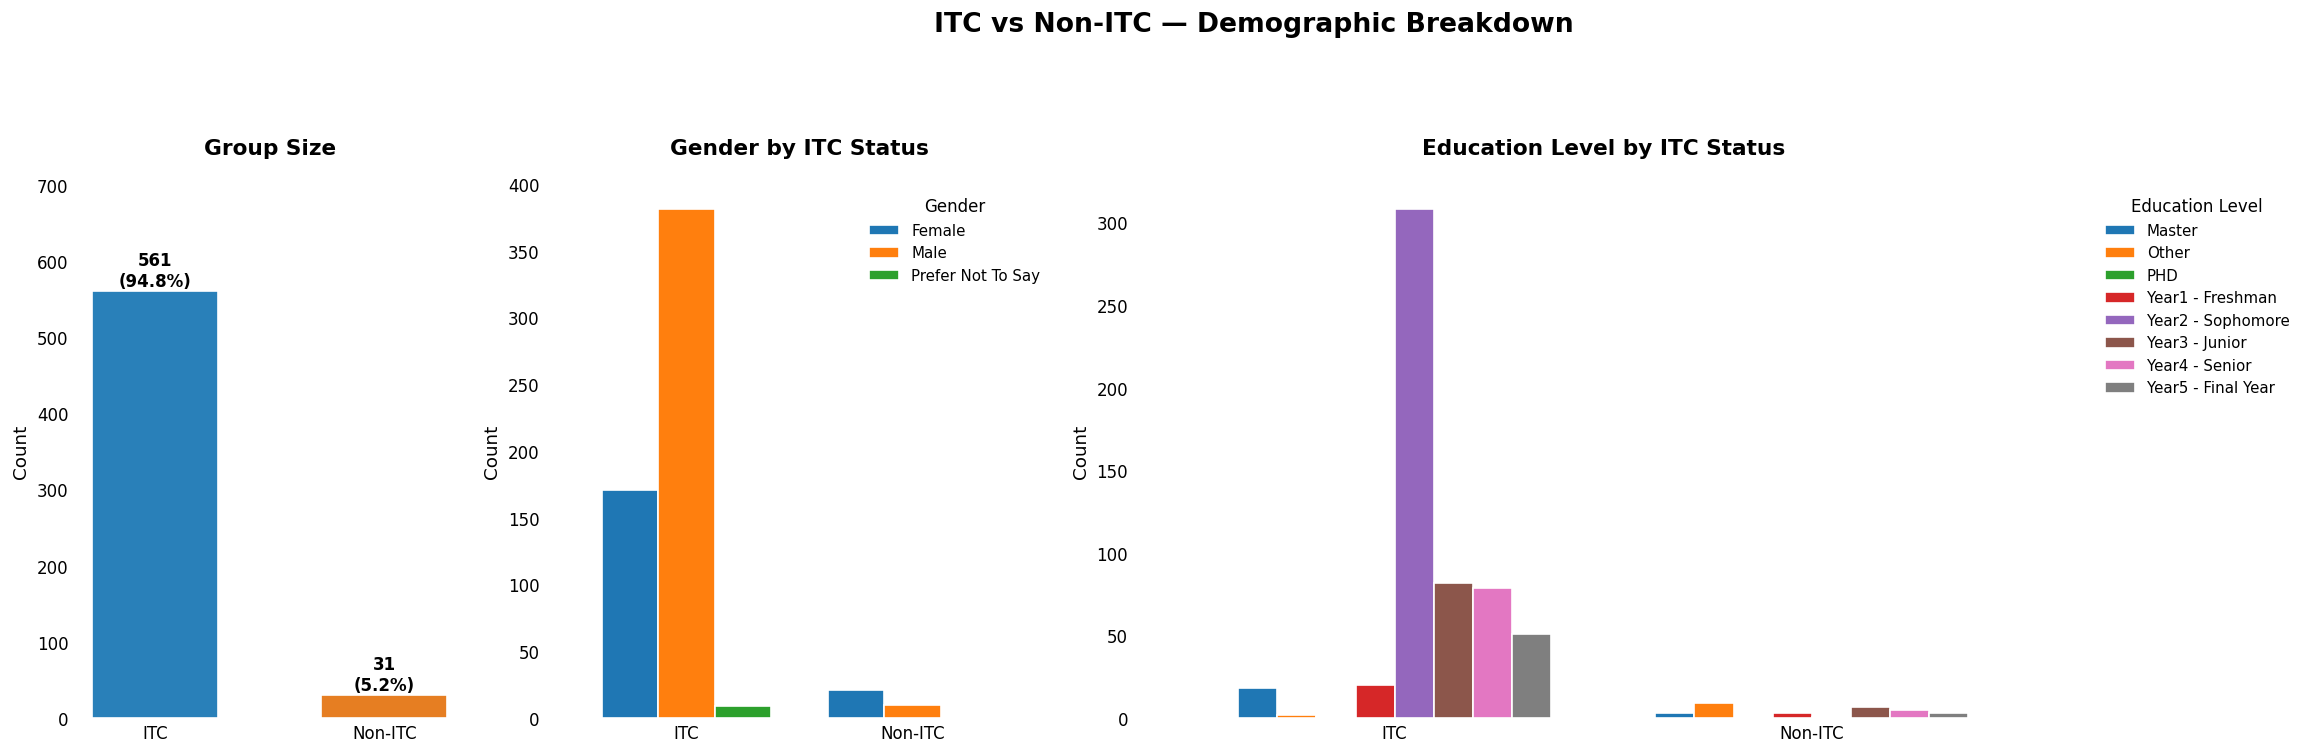

In [30]:
# ── ITC vs Non-ITC: group sizes and demographic overview ───────────────────────

ITC_COL = group_cfg.get("itc_flag_col", "is_itc_student")
GROUP_COL = group_cfg.get("group_col", "itc_group")
ITC_PALETTE = group_cfg.get("palette", {})

# Guard
if ITC_COL not in df.columns:
    print(f"[!] '{ITC_COL}' column not found. Run cleaner first.")

else:
    # --------------------------------------------------
    # Convert boolean → readable labels
    # --------------------------------------------------
    df[GROUP_COL] = make_itc_group(df)

    # --------------------------------------------------
    # Group sizes
    # --------------------------------------------------
    groups = df[GROUP_COL].value_counts().sort_index()
    pcts = groups / groups.sum() * 100

    print("=" * 50)
    print("  ITC vs Non-ITC — Group Sizes")
    print("=" * 50)

    for grp in groups.index:
        print(f"  {grp:<10} : {groups[grp]:>4}  ({pcts[grp]:.1f}%)")

    print(f"  {'Total':<10} : {groups.sum():>4}")

    # --------------------------------------------------
    # Figure layout - larger and clearer
    # --------------------------------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(21, 6),
        gridspec_kw={
            "width_ratios": [1, 1.3, 2.4]
        }
    )

    fig.suptitle(
        "ITC vs Non-ITC — Demographic Breakdown",
        fontsize=16,
        fontweight="bold",
        y=1.04
    )

    # ==================================================
    # Panel 1: Group size
    # ==================================================
    colors = [
        ITC_PALETTE.get(g, "#888888")
        for g in groups.index
    ]

    bars = axes[0].bar(
        groups.index,
        groups.values,
        color=colors,
        edgecolor="white",
        width=0.55
    )

    for bar, val, pct in zip(bars, groups.values, pcts.values):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{val}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    axes[0].set_title(
        "Group Size",
        fontsize=13,
        fontweight="bold",
        pad=18
    )

    axes[0].set_ylabel("Count", fontsize=11)
    axes[0].set_ylim(0, groups.max() * 1.25)
    axes[0].tick_params(axis="x", labelsize=10)
    axes[0].tick_params(axis="y", labelsize=10)

    # ==================================================
    # Panel 2: Gender by ITC status
    # ==================================================
    if "gender" in df.columns:

        gender_itc = (
            df.groupby([GROUP_COL, col_cfg.get("gender", "gender")], observed=True)
              .size()
              .unstack(fill_value=0)
        )

        gender_itc.plot(
            kind="bar",
            ax=axes[1],
            edgecolor="white",
            width=0.75
        )

        axes[1].set_title(
            "Gender by ITC Status",
            fontsize=13,
            fontweight="bold",
            pad=18
        )

        axes[1].set_xlabel("")
        axes[1].set_ylabel("Count", fontsize=11)

        plt.setp(
            axes[1].get_xticklabels(),
            rotation=0,
            fontsize=10
        )

        axes[1].tick_params(axis="y", labelsize=10)

        axes[1].legend(
            title="Gender",
            fontsize=9,
            title_fontsize=10,
            frameon=False
        )

    else:
        axes[1].axis("off")
        axes[1].set_title(
            "Gender column not found",
            fontsize=11,
            fontweight="bold"
        )

    # ==================================================
    # Panel 3: Education level
    # ==================================================
    if "education_level" in df.columns:

        edu_itc = (
            df.groupby([GROUP_COL, col_cfg.get("education_level", "education_level")], observed=True)
              .size()
              .unstack(fill_value=0)
        )

        edu_itc.plot(
            kind="bar",
            ax=axes[2],
            edgecolor="white",
            width=0.75
        )

        axes[2].set_title(
            "Education Level by ITC Status",
            fontsize=13,
            fontweight="bold",
            pad=18
        )

        axes[2].set_xlabel("")
        axes[2].set_ylabel("Count", fontsize=11)

        plt.setp(
            axes[2].get_xticklabels(),
            rotation=0,
            fontsize=10
        )

        axes[2].tick_params(axis="y", labelsize=10)

        axes[2].legend(
            title="Education Level",
            fontsize=9,
            title_fontsize=10,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            frameon=False
        )

    else:
        axes[2].axis("off")
        axes[2].set_title(
            "Education level column not found",
            fontsize=11,
            fontweight="bold"
        )

    # --------------------------------------------------
    # Clean thesis style: no grid, no bounding box
    # --------------------------------------------------
    for ax in axes:
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.tick_params(axis="both", length=0)

    # Leave space for external legend of last chart
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])
    plt.show()


#### 2.2.4.2  All 33 Likert Items — ITC vs Non-ITC Heatmap

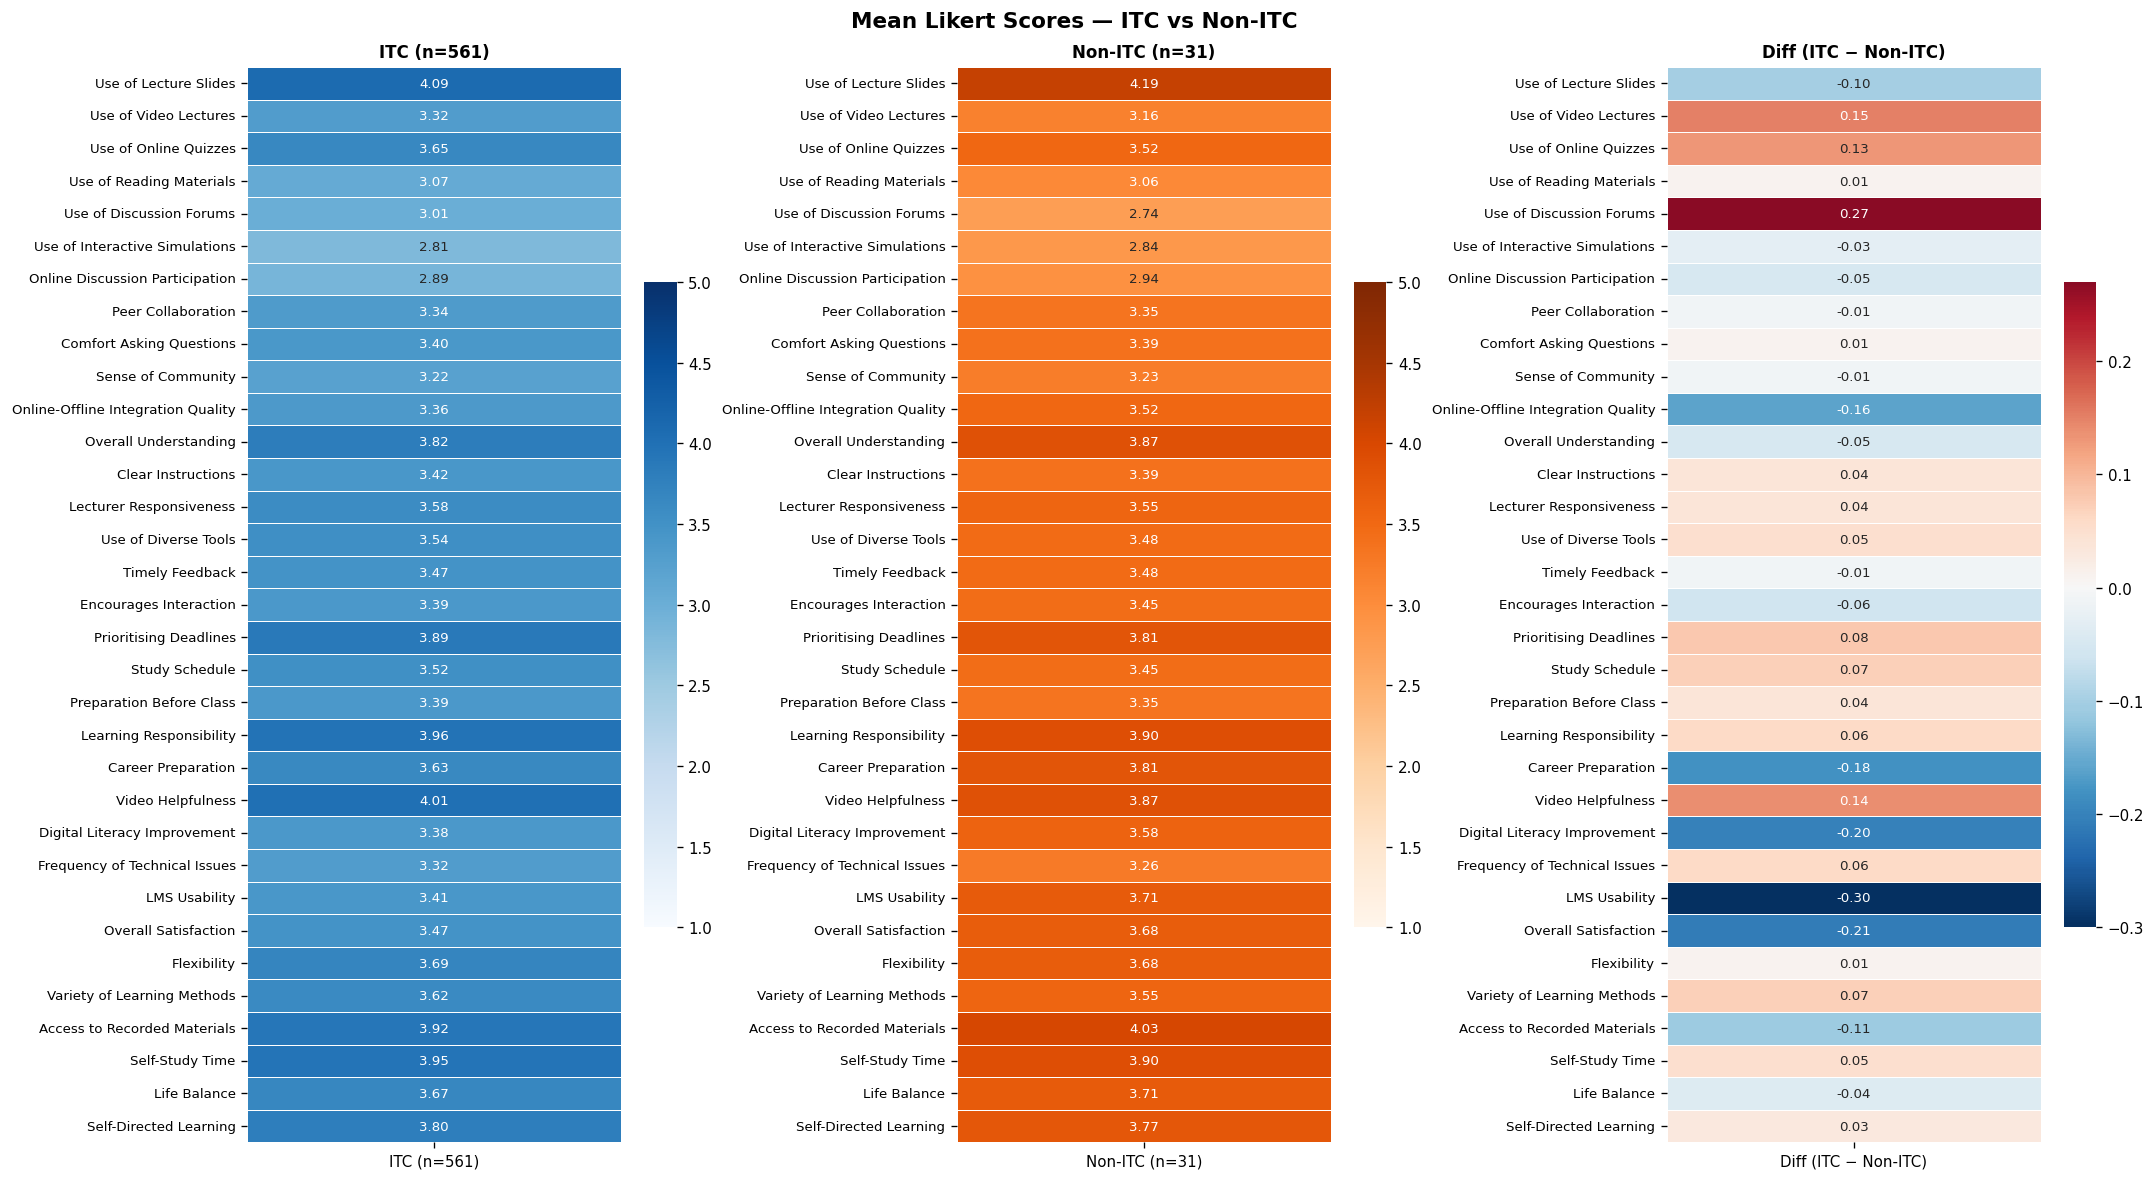


Top 5 items where ITC scores HIGHER than Non-ITC:
Use of Discussion Forums    0.270542
Use of Video Lectures       0.154218
Video Helpfulness           0.143293
Use of Online Quizzes       0.129147
Prioritising Deadlines      0.079466

Top 5 items where Non-ITC scores HIGHER than ITC:
LMS Usability                        -0.301478
Overall Satisfaction                 -0.205049
Digital Literacy Improvement         -0.197401
Career Preparation                   -0.179001
Online-Offline Integration Quality   -0.156058


In [31]:
# ── ITC vs Non-ITC: mean Likert scores across all ordinal items ───────────────

# Use readable label column created earlier
GROUP_COL = group_cfg.get("group_col", "itc_group")

if GROUP_COL not in df.columns:
    df[GROUP_COL] = make_itc_group(df)

# Keep only valid groups
labels_cfg = group_cfg.get("labels", {})
itc_label = labels_cfg.get("itc", "ITC")
non_itc_label = labels_cfg.get("non_itc", "Non-ITC")
analysis_df = df[df[GROUP_COL].isin([itc_label, non_itc_label])].copy()

# --------------------------------------------------
# Mean scores by group
# --------------------------------------------------
itc_means = (
    analysis_df.loc[
        analysis_df[GROUP_COL] == itc_label,
        oridinal_cols
    ]
    .mean()
)

non_itc_means = (
    analysis_df.loc[
        analysis_df[GROUP_COL] == non_itc_label,
        oridinal_cols
    ]
    .mean()
)

diff = itc_means - non_itc_means

itc_n = (analysis_df[GROUP_COL] == itc_label).sum()
non_itc_n = (analysis_df[GROUP_COL] == non_itc_label).sum()

# --------------------------------------------------
# Comparison dataframe
# --------------------------------------------------
compare_df = pd.DataFrame({
    f"ITC (n={itc_n})": itc_means.round(2),
    f"Non-ITC (n={non_itc_n})": non_itc_means.round(2),
    "Diff (ITC − Non-ITC)": diff.round(2),
})

compare_df = compare_df.rename(
    index={col: pl(col) for col in oridinal_cols}
)

# --------------------------------------------------
# Heatmap visualization
# --------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 10),
    gridspec_kw={"width_ratios": [1, 1, 1]}
)

fig.suptitle(
    "Mean Likert Scores — ITC vs Non-ITC",
    fontsize=13,
    fontweight="bold"
)

heatmap_configs = [
    (axes[0], compare_df.columns[0], "Blues", None),
    (axes[1], compare_df.columns[1], "Oranges", None),
    (axes[2], compare_df.columns[2], "RdBu_r", 0),
]

for ax, col, cmap, center in heatmap_configs:
    data = compare_df[[col]]

    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        center=center,
        vmin=(1 if center is None else None),
        vmax=(5 if center is None else None),
        linewidths=0.3,
        annot_kws={"size": 8},
        ax=ax,
        cbar_kws={"shrink": 0.6}
    )

    ax.set_title(
        col,
        fontsize=10,
        fontweight="bold"
    )

    ax.set_xlabel("")
    plt.setp(
        ax.get_yticklabels(),
        fontsize=8
    )

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Top differences summary
# --------------------------------------------------
pretty_diff = diff.rename(
    index={col: pl(col) for col in oridinal_cols}
)

print("\nTop 5 items where ITC scores HIGHER than Non-ITC:")
print(
    pretty_diff
    .sort_values(ascending=False)
    .head(5)
    .to_string()
)

print("\nTop 5 items where Non-ITC scores HIGHER than ITC:")
print(
    pretty_diff
    .sort_values(ascending=True)
    .head(5)
    .to_string()
)


#### 2.2.4.3 Satisfaction, understanding, and key perception items (violin)

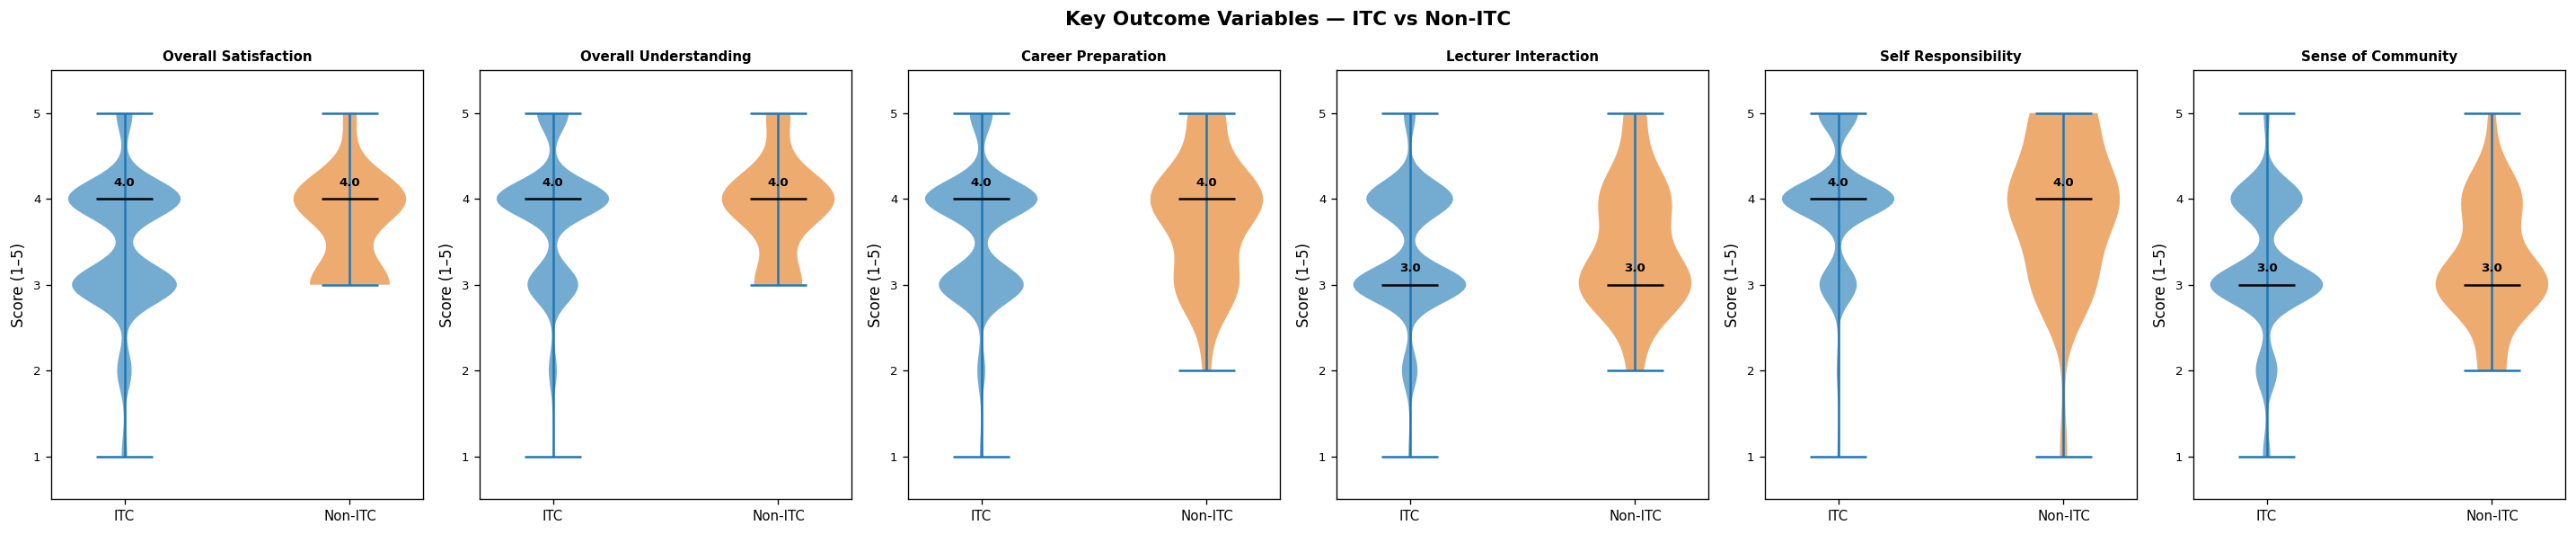

In [32]:
# ── ITC vs Non-ITC: key outcome variables — violin plots ─────────────────────

GROUP_COL = group_cfg.get("group_col", "itc_group")
ITC_COL = group_cfg.get("itc_flag_col", "is_itc_student")
labels_cfg = group_cfg.get("labels", {})
itc_label = labels_cfg.get("itc", "ITC")
non_itc_label = labels_cfg.get("non_itc", "Non-ITC")

if GROUP_COL not in df.columns:
    df[GROUP_COL] = make_itc_group(df)

key_outcomes = [
    (col, label)
    for col, label in group_cfg.get("key_outcomes", [])
    if col in df.columns
]

if not key_outcomes:
    print("[!] No key outcome columns found.")

else:
    fig, axes = plt.subplots(
        1,
        len(key_outcomes),
        figsize=(4 * len(key_outcomes), 5)
    )

    if len(key_outcomes) == 1:
        axes = [axes]

    fig.suptitle(
        "Key Outcome Variables — ITC vs Non-ITC",
        fontsize=13,
        fontweight="bold"
    )

    for ax, (col, title) in zip(axes, key_outcomes):

        itc_data = (
            df.loc[df[GROUP_COL] == itc_label, col]
            .dropna()
            .values
        )

        non_itc_data = (
            df.loc[df[GROUP_COL] == non_itc_label, col]
            .dropna()
            .values
        )

        if len(itc_data) == 0 and len(non_itc_data) == 0:
            ax.set_visible(False)
            continue

        vp = ax.violinplot(
            [itc_data, non_itc_data],
            showmedians=True,
            showmeans=False
        )

        palette = group_cfg.get("palette", {})
        vp["bodies"][0].set_facecolor(palette.get(itc_label, "#2980b9"))
        vp["bodies"][0].set_alpha(0.65)

        vp["bodies"][1].set_facecolor(palette.get(non_itc_label, "#e67e22"))
        vp["bodies"][1].set_alpha(0.65)

        vp["cmedians"].set_color("black")

        ax.set_xticks([1, 2])
        ax.set_xticklabels([itc_label, non_itc_label], fontsize=9)

        ax.set_title(title, fontsize=9, fontweight="bold")
        ax.set_ylabel("Score (1–5)")
        ax.set_ylim(0.5, 5.5)
        ax.yaxis.set_tick_params(labelsize=8)

        for pos, values in [(1, itc_data), (2, non_itc_data)]:
            if len(values):
                median_val = np.median(values)
                ax.text(
                    pos,
                    median_val + 0.15,
                    f"{median_val:.1f}",
                    ha="center",
                    fontsize=8,
                    color="black",
                    fontweight="bold"
                )

    plt.tight_layout()
    plt.show()


#### 2.2.4.4 Challenge prevalence ITC vs Non-ITC (grouped bar)

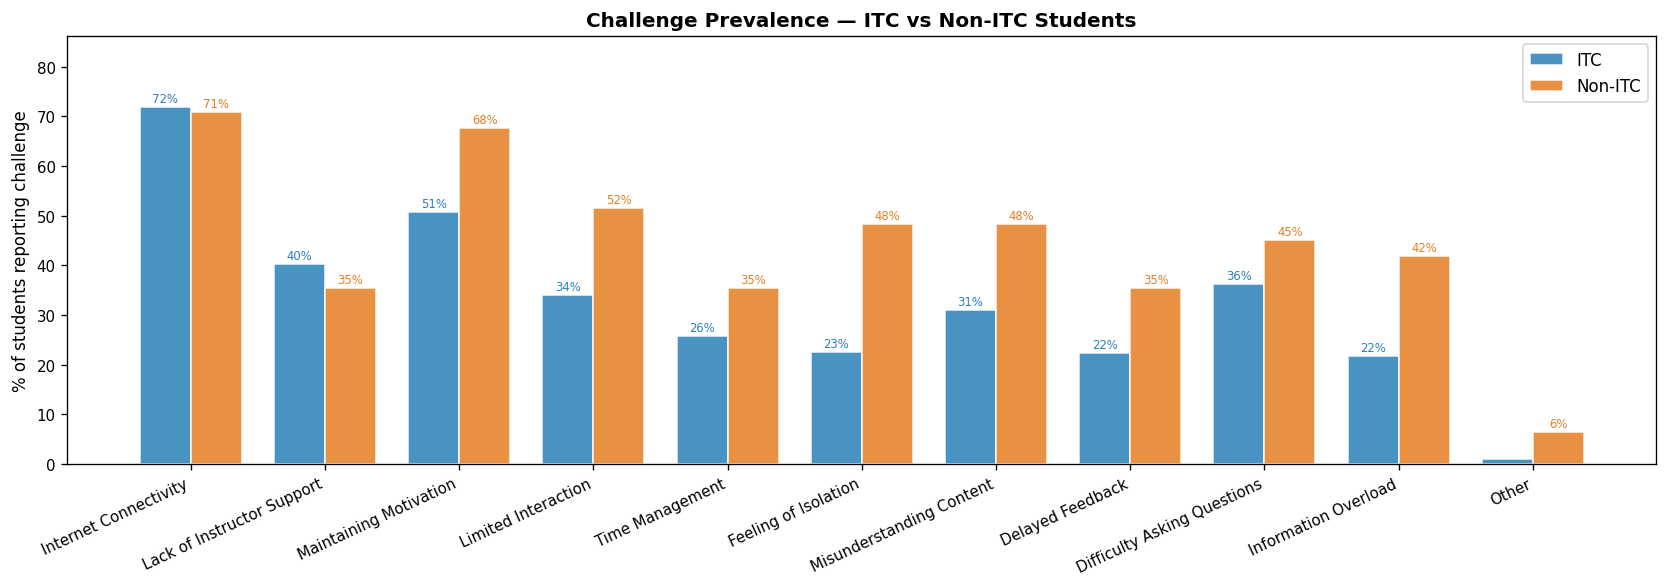


Challenge Prevalence — ITC vs Non-ITC
                             ITC %  Non-ITC %  Diff (ITC−Non)
Lack of Instructor Support    40.3       35.5             4.8
Internet Connectivity         71.8       71.0             0.9
Other                          1.1        6.5            -5.4
Difficulty Asking Questions   36.2       45.2            -9.0
Time Management               25.8       35.5            -9.6
Delayed Feedback              22.5       35.5           -13.0
Maintaining Motivation        50.8       67.7           -16.9
Misunderstanding Content      31.0       48.4           -17.4
Limited Interaction           34.0       51.6           -17.6
Information Overload          21.7       41.9           -20.2
Feeling of Isolation          22.6       48.4           -25.7


In [33]:
# ── Challenge prevalence: ITC vs Non-ITC students ────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GROUP_COL = group_cfg.get("group_col", "itc_group")
ITC_COL = group_cfg.get("itc_flag_col", "is_itc_student")
labels_cfg = group_cfg.get("labels", {})
itc_label = labels_cfg.get("itc", "ITC")
non_itc_label = labels_cfg.get("non_itc", "Non-ITC")

if ITC_COL not in df.columns:
    print(f"[!] '{ITC_COL}' column not found. Cannot compare ITC vs Non-ITC groups.")

else:
    if GROUP_COL not in df.columns:
        df[GROUP_COL] = make_itc_group(df)

    if "MULTI_GROUPS" not in globals():
        if "multi_groups" in globals():
            MULTI_GROUPS = {
                g: [c for c in cols if c in df.columns]
                for g, cols in multi_groups.items()
            }
        else:
            MULTI_GROUPS = {}

    CH_COLS = MULTI_GROUPS.get(group_cfg.get("challenge_group", "challenges"), [])

    if not CH_COLS:
        CH_COLS = [
            c for c in df.columns
            if c.startswith("ch_")
        ]

    if "pl" in globals():
        CH_LABELS_MAP = {
            col: pl(col)
            for col in CH_COLS
        }
    else:
        CH_LABELS_MAP = {
            col: col.replace("_", " ").title()
            for col in CH_COLS
        }

    valid_ch_cols = [
        col for col in CH_COLS
        if col in df.columns
    ]

    if valid_ch_cols:
        itc_rates = (
            df.loc[df[GROUP_COL] == itc_label, valid_ch_cols]
            .fillna(0)
            .mean()
            * 100
        )

        non_itc_rates = (
            df.loc[df[GROUP_COL] == non_itc_label, valid_ch_cols]
            .fillna(0)
            .mean()
            * 100
        )

        labels = [
            CH_LABELS_MAP.get(col, col)
            for col in valid_ch_cols
        ]

        x = np.arange(len(valid_ch_cols))
        width = 0.38

        fig, ax = plt.subplots(figsize=(14, 5))

        bars1 = ax.bar(
            x - width / 2,
            itc_rates.values,
            width,
            label=itc_label,
            color="#2980b9",
            alpha=0.85,
            edgecolor="white"
        )

        bars2 = ax.bar(
            x + width / 2,
            non_itc_rates.values,
            width,
            label=non_itc_label,
            color="#e67e22",
            alpha=0.85,
            edgecolor="white"
        )

        for bar in bars1:
            if bar.get_height() > 2:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1,
                    f"{bar.get_height():.0f}%",
                    ha="center",
                    fontsize=7,
                    color="#2980b9"
                )

        for bar in bars2:
            if bar.get_height() > 2:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1,
                    f"{bar.get_height():.0f}%",
                    ha="center",
                    fontsize=7,
                    color="#e67e22"
                )

        ax.set_xticks(x)
        ax.set_xticklabels(
            labels,
            rotation=25,
            ha="right",
            fontsize=9
        )

        ax.set_ylabel("% of students reporting challenge")

        ax.set_title(
            "Challenge Prevalence — ITC vs Non-ITC Students",
            fontsize=12,
            fontweight="bold"
        )

        ax.legend(fontsize=10)

        max_rate = max(
            itc_rates.max(),
            non_itc_rates.max()
        )

        ax.set_ylim(
            0,
            max_rate * 1.2 if max_rate > 0 else 1
        )

        plt.tight_layout()
        plt.show()

        ch_compare = pd.DataFrame({
            "ITC %": itc_rates.round(1).values,
            "Non-ITC %": non_itc_rates.round(1).values,
            "Diff (ITC−Non)": (
                itc_rates - non_itc_rates
            ).round(1).values,
        }, index=labels)

        ch_compare = ch_compare.sort_values(
            "Diff (ITC−Non)",
            ascending=False
        )

        print("\nChallenge Prevalence — ITC vs Non-ITC")
        print(ch_compare.to_string())

    else:
        print(
            "[!] No valid ch_* binary columns found. "
            "Check preprocessing pipeline or parsed challenge columns."
        )


#### 2.2.4.5 Device and internet access comparison

In [34]:
multi_groups

{'devices': ['device_mobile',
  'device_tablet',
  'device_laptop',
  'device_desktop',
  'device_other'],
 'internet_access': ['inet_mobile_data',
  'inet_home_wifi',
  'inet_public_wifi',
  'inet_university_wifi'],
 'coping_mechanisms': ['miss_resend_announcement',
  'miss_request_recording',
  'miss_ask_classmates',
  'miss_one_on_one',
  'miss_deadline_extension',
  'miss_self_study',
  'miss_ignore',
  'miss_other'],
 'challenges': ['ch_internet',
  'ch_no_instructor_support',
  'ch_motivation',
  'ch_limited_interaction',
  'ch_time_management',
  'ch_isolation',
  'ch_misunderstanding',
  'ch_delayed_feedback',
  'ch_asking_questions',
  'ch_info_overload',
  'ch_other']}

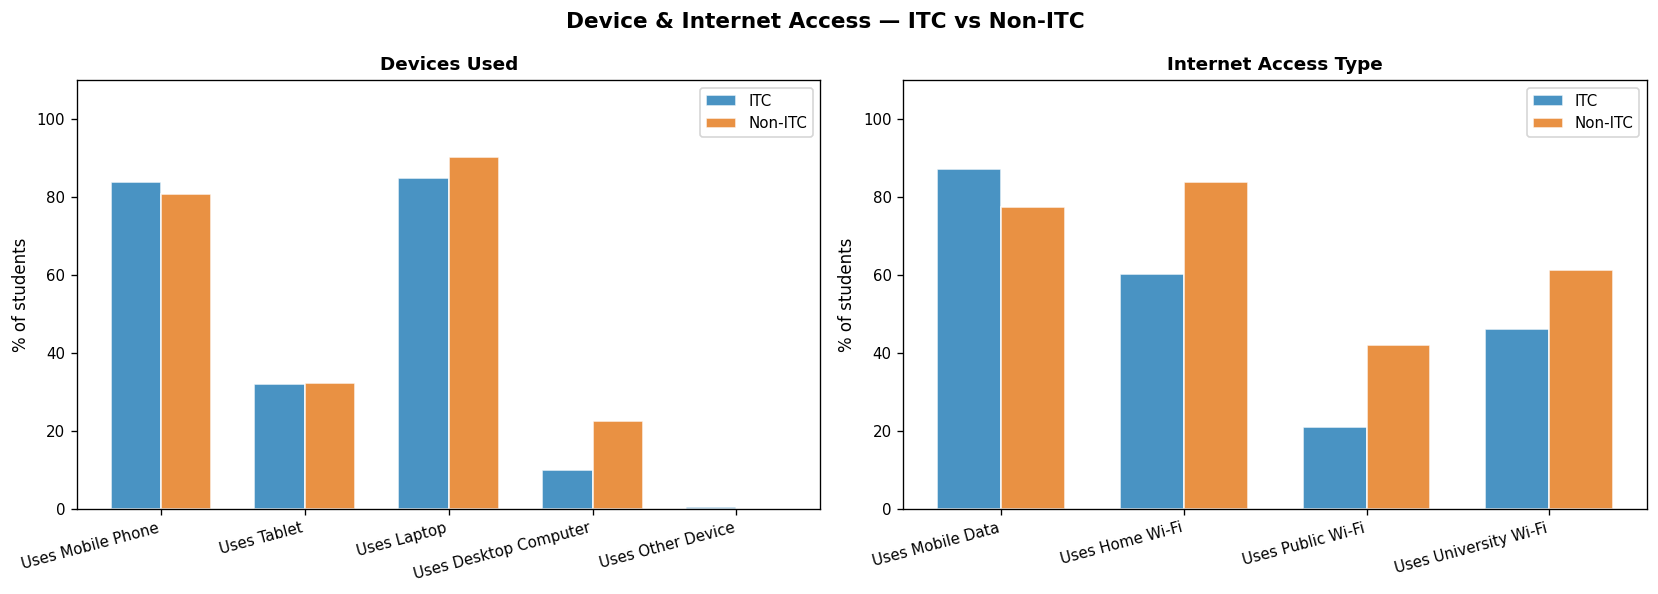

In [35]:
# ── ITC vs Non-ITC: device and internet access patterns ──────────────────────

GROUP_COL = group_cfg.get("group_col", "itc_group")
ITC_COL = group_cfg.get("itc_flag_col", "is_itc_student")
labels_cfg = group_cfg.get("labels", {})
itc_label = labels_cfg.get("itc", "ITC")
non_itc_label = labels_cfg.get("non_itc", "Non-ITC")

# Create readable labels if missing
if GROUP_COL not in df.columns:
    df[GROUP_COL] = make_itc_group(df)

# --------------------------------------------------
# Column groups
# --------------------------------------------------
DEVICE_COLS = [
    col for col in multi_groups[tech_cfg.get("device_group", "devices")]
    if col in df.columns
]

INET_COLS = [
    col for col in multi_groups[tech_cfg.get("internet_group", "internet_access")]
    if col in df.columns
]

DEVICE_LABELS = {
    col: pl(col)
    for col in DEVICE_COLS
}

INET_LABELS = {
    col: pl(col)
    for col in INET_COLS
}

# --------------------------------------------------
# Guard
# --------------------------------------------------
if DEVICE_COLS or INET_COLS:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    fig.suptitle(
        "Device & Internet Access — ITC vs Non-ITC",
        fontsize=13,
        fontweight="bold"
    )

    panel_configs = [
        (
            axes[0],
            DEVICE_COLS,
            DEVICE_LABELS,
            "Devices Used"
        ),
        (
            axes[1],
            INET_COLS,
            INET_LABELS,
            "Internet Access Type"
        ),
    ]

    for ax, cols, labels_map, title in panel_configs:

        if not cols:
            ax.set_visible(False)
            continue

        # --------------------------------------------------
        # Calculate usage rates (%)
        # --------------------------------------------------
        itc_rates = (
            df.loc[
                df[GROUP_COL] == itc_label,
                cols
            ]
            .mean()
            * 100
        )

        non_itc_rates = (
            df.loc[
                df[GROUP_COL] == non_itc_label,
                cols
            ]
            .mean()
            * 100
        )

        labels = [
            labels_map.get(col, col)
            for col in cols
        ]

        x = np.arange(len(cols))
        width = 0.35

        # --------------------------------------------------
        # Bar plots
        # --------------------------------------------------
        ax.bar(
            x - width / 2,
            itc_rates.values,
            width,
            label=itc_label,
            color=group_cfg.get("palette", {}).get(itc_label, "#2980b9"),
            alpha=0.85,
            edgecolor="white"
        )

        ax.bar(
            x + width / 2,
            non_itc_rates.values,
            width,
            label=non_itc_label,
            color=group_cfg.get("palette", {}).get(non_itc_label, "#e67e22"),
            alpha=0.85,
            edgecolor="white"
        )

        # --------------------------------------------------
        # Formatting
        # --------------------------------------------------
        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=15,
            ha="right",
            fontsize=9
        )

        ax.set_ylabel("% of students")

        ax.set_title(
            title,
            fontsize=11,
            fontweight="bold"
        )

        ax.set_ylim(0, 110)

        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

else:
    print(
        "[!] No valid device or internet access columns found. "
        "Check preprocessing pipeline or multi_groups config."
    )


#### 2.2.4.6 Social media hours and academic year distribution

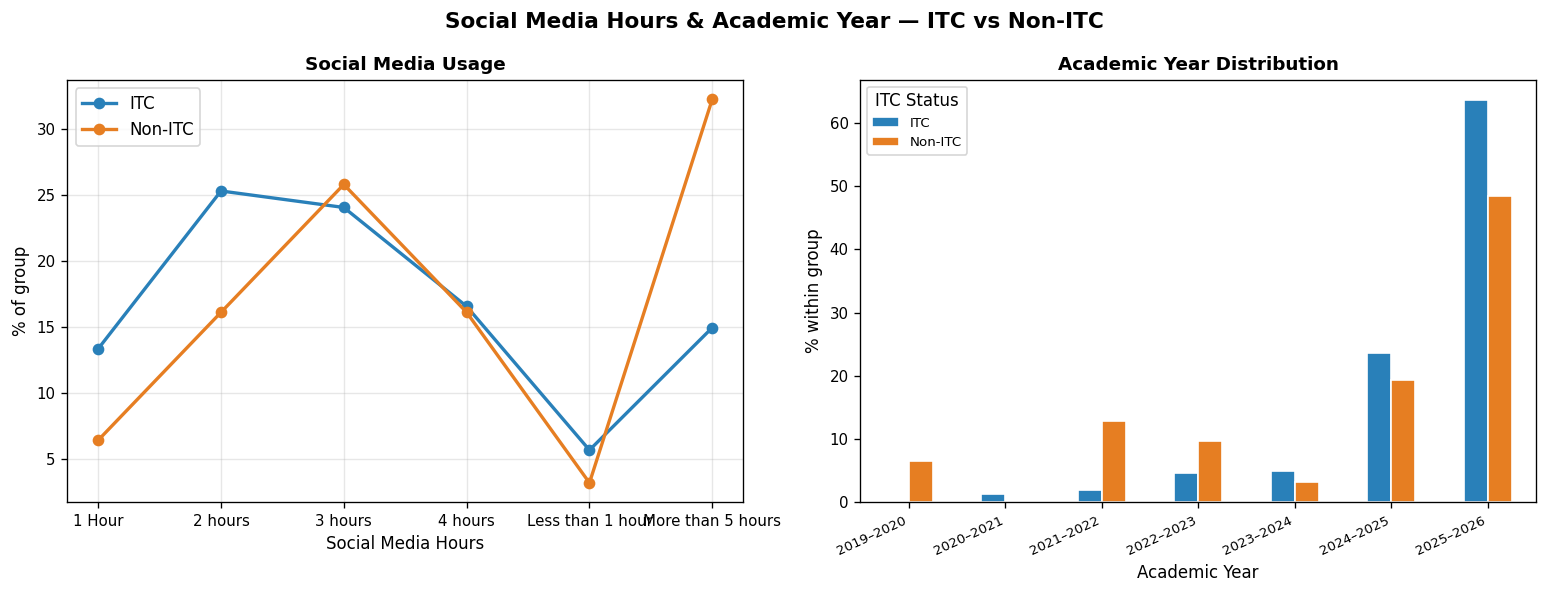

In [36]:
# ── ITC vs Non-ITC: social media hours + academic year ───────────────────────

GROUP_COL = group_cfg.get("group_col", "itc_group")
ITC_COL = group_cfg.get("itc_flag_col", "is_itc_student")
labels_cfg = group_cfg.get("labels", {})
itc_label = labels_cfg.get("itc", "ITC")
non_itc_label = labels_cfg.get("non_itc", "Non-ITC")

# Ensure readable grouping
if GROUP_COL not in df.columns:
    df[GROUP_COL] = make_itc_group(df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Social Media Hours & Academic Year — ITC vs Non-ITC",
    fontsize=13,
    fontweight="bold"
)

# ==================================================
# Panel 1: Social media usage
# ==================================================
sm_col = col_cfg.get("social_media_hours", "social_media_hours")
if sm_col in df.columns:

    for grp, color in [(itc_label, group_cfg.get("palette", {}).get(itc_label, "#2980b9")), (non_itc_label, group_cfg.get("palette", {}).get(non_itc_label, "#e67e22"))]:

        sub = df.loc[df[GROUP_COL] == grp, sm_col].dropna()

        if len(sub) == 0:
            continue

        counts = sub.value_counts().sort_index()

        pct = (counts / counts.sum()) * 100

        axes[0].plot(
            pct.index,
            pct.values,
            "o-",
            color=color,
            lw=2,
            ms=6,
            label=grp
        )

    axes[0].set_xlabel("Social Media Hours")
    axes[0].set_ylabel("% of group")
    axes[0].set_title(
        "Social Media Usage",
        fontsize=11,
        fontweight="bold"
    )
    axes[0].legend()
    axes[0].grid(alpha=0.3)

# ==================================================
# Panel 2: Academic year distribution
# ==================================================
academic_year_col = col_cfg.get("academic_year", "academic_year")
if academic_year_col in df.columns:

    ay_counts = (
        df.groupby([GROUP_COL, academic_year_col], observed=True)
          .size()
          .unstack(fill_value=0)
    )

    ay_pct = ay_counts.div(ay_counts.sum(axis=1), axis=0) * 100

    ay_pct.T.plot(
        kind="bar",
        ax=axes[1],
        edgecolor="white",
        color=["#2980b9", "#e67e22"][:len(ay_pct)]
    )

    axes[1].set_title(
        "Academic Year Distribution",
        fontsize=11,
        fontweight="bold"
    )

    axes[1].set_xlabel("Academic Year")
    axes[1].set_ylabel("% within group")

    plt.setp(
        axes[1].get_xticklabels(),
        rotation=25,
        ha="right",
        fontsize=8
    )

    axes[1].legend(
        title="ITC Status",
        fontsize=8
    )

plt.tight_layout()
plt.show()


### 2.3  Association Analysis — CA 

**Correspondence Analysis (CA)** examines pairwise categorical associations between demographic and preference variables.

Both analyses complement the bivariate distributions in Section 3.2 by showing how categorical variables co-occur and cluster together.

#### 2.3.1  CA — Correspondence Analysis (Pairwise Categorical Relationships)

Pairwise correspondence analysis was used as an exploratory technique to visualize associations between selected categorical variables. Each panel should be interpreted independently. Chi-square tests confirm statistical significance of each association.

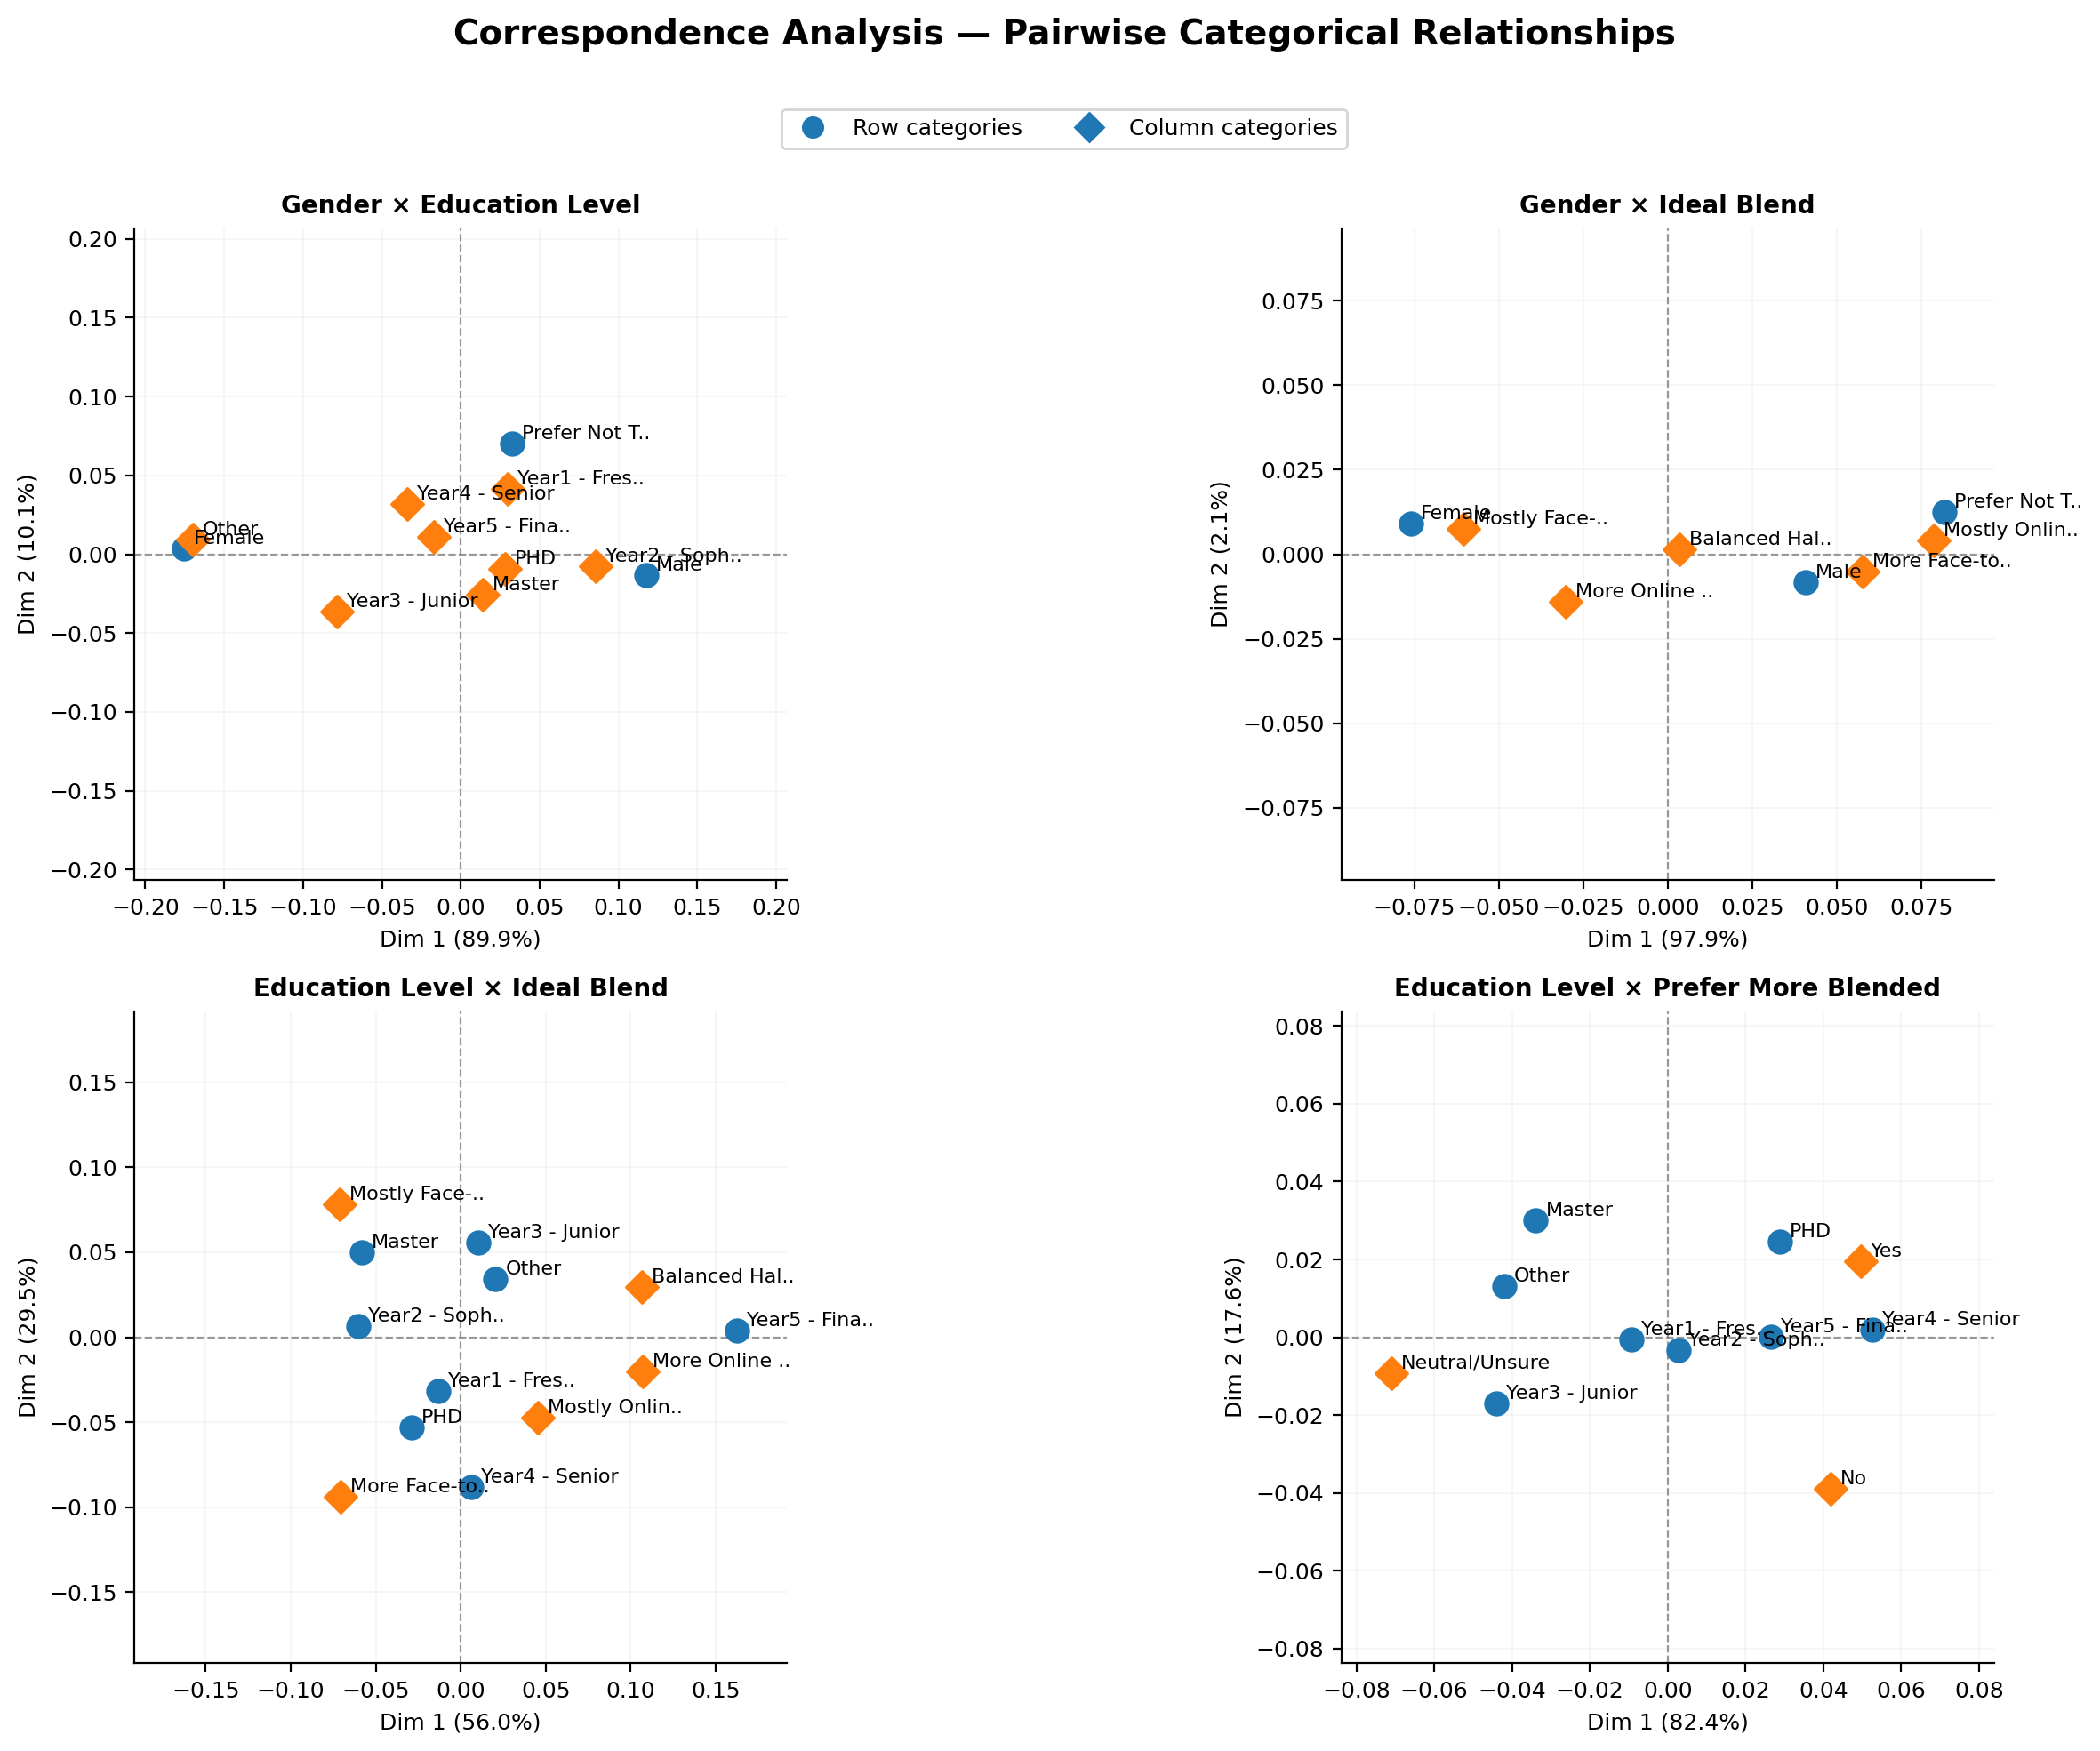

In [37]:
# ── 10.1 CA pairs ────────────────────────────────────────────────────────────
CA_PAIRS = [tuple(pair) for pair in ca_cfg.get("pairs", [])]


# ── 10.2 Short label helper ──────────────────────────────────────────────────
def shorten(label, maxlen=None):
    maxlen = maxlen or ca_cfg.get("short_label_maxlen", 14)
    s = str(label)
    return s if len(s) <= maxlen else s[:maxlen-2] + '..'


# ── 10.3 CA runner ───────────────────────────────────────────────────────────
def run_ca(ctab):
    """
    Perform simple Correspondence Analysis on a contingency table.
    """
    N = ctab.to_numpy(dtype=float)
    grand_total = N.sum()

    if grand_total == 0:
        raise ValueError("Contingency table sum is zero.")

    P = N / grand_total
    r = P.sum(axis=1)
    c = P.sum(axis=0)
    E = np.outer(r, c)

    with np.errstate(divide='ignore', invalid='ignore'):
        S = np.where(E > 0, (P - E) / np.sqrt(E), 0)

    U, s, VT = np.linalg.svd(S, full_matrices=False)
    row_coords = U[:, :2] * s[:2]
    col_coords = VT.T[:, :2] * s[:2]
    eig = s**2

    if eig.sum() == 0:
        inertia = np.array([0.0, 0.0])
    else:
        inertia = eig / eig.sum()

    if row_coords.shape[1] == 1:
        row_coords = np.column_stack([row_coords[:, 0], np.zeros(row_coords.shape[0])])

    if col_coords.shape[1] == 1:
        col_coords = np.column_stack([col_coords[:, 0], np.zeros(col_coords.shape[0])])

    if len(inertia) == 1:
        inertia = np.array([inertia[0], 0.0])

    return row_coords[:, :2], col_coords[:, :2], inertia[:2]


def plot_ca_clean(ax, row_c, col_c, inertia, row_labels, col_labels, title):
    x_row = row_c[:, 0]
    y_row = row_c[:, 1]
    x_col = col_c[:, 0]
    y_col = col_c[:, 1]

    lim = max(
        np.max(np.abs(x_row)) if len(x_row) else 0,
        np.max(np.abs(y_row)) if len(y_row) else 0,
        np.max(np.abs(x_col)) if len(x_col) else 0,
        np.max(np.abs(y_col)) if len(y_col) else 0,
        0.05
    ) * 1.18

    dx = 0.03 * lim
    dy = 0.03 * lim

    ax.scatter(x_row, y_row, s=85, marker='o', zorder=3, label='Row categories')
    ax.scatter(x_col, y_col, s=85, marker='D', zorder=3, label='Column categories')

    for x, y, lab in zip(x_row, y_row, row_labels):
        ax.text(x + dx, y + dy, lab, fontsize=8, ha='left', va='center')

    for x, y, lab in zip(x_col, y_col, col_labels):
        ax.text(x + dx, y + dy, lab, fontsize=8, ha='left', va='center')

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.8)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'Dim 1 ({inertia[0] * 100:.1f}%)', fontsize=9)
    ax.set_ylabel(f'Dim 2 ({inertia[1] * 100:.1f}%)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.10)
    ax.set_aspect('equal', adjustable='box')


# ── 10.5 Thesis-visible CA figure layout ────────────────────────────────────
ca_rows, ca_cols = ca_cfg.get("layout", [2, 2])
fig, axes = plt.subplots(ca_rows, ca_cols, figsize=(14, 10), dpi=200)
axes = np.array(axes).flatten()

fig.suptitle(
    'Correspondence Analysis — Pairwise Categorical Relationships',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

for ax, (row_var, col_var, title) in zip(axes, CA_PAIRS):
    sub = df[[row_var, col_var]].dropna()
    ctab = pd.crosstab(sub[row_var], sub[col_var])
    ctab = ctab.loc[(ctab.sum(axis=1) > 0), (ctab.sum(axis=0) > 0)]

    if ctab.shape[0] < 2 or ctab.shape[1] < 2:
        ax.axis('off')
        ax.set_title(title, fontsize=10, fontweight='bold')
        continue

    row_c, col_c, iner = run_ca(ctab)
    plot_ca_clean(
        ax=ax,
        row_c=row_c,
        col_c=col_c,
        inertia=iner,
        row_labels=[shorten(r) for r in ctab.index],
        col_labels=[shorten(c) for c in ctab.columns],
        title=title
    )

for ax in axes[len(CA_PAIRS):]:
    ax.axis('off')

handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', markersize=8, label='Row categories'),
    plt.Line2D([0], [0], marker='D', linestyle='', markersize=8, label='Column categories')
]

fig.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.935),
    ncol=2,
    frameon=True,
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


#### 2.3.2 Contingency tables + chi-square for each CA pair

In [38]:
# ── 10.6 Contingency tables + chi-square for each CA pair ────────────────────
chi_rows = []

for row_var, col_var, title in CA_PAIRS:
    sub = df[[row_var, col_var]].dropna()

    ctab = pd.crosstab(
        sub[row_var],
        sub[col_var]
    )

    # Drop empty rows and columns
    ctab = ctab.loc[
        (ctab.sum(axis=1) > 0),
        (ctab.sum(axis=0) > 0)
    ]

    # Skip pairs that cannot support chi-square test
    if ctab.shape[0] < 2 or ctab.shape[1] < 2:
        continue

    # Chi-square test of independence
    chi2, pval, dof, expected = chi2_contingency(ctab)

    # Cramer's V effect size
    n = ctab.values.sum()
    min_dim = min(ctab.shape) - 1

    if n > 0 and min_dim > 0:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    else:
        cramers_v = np.nan

    chi_rows.append({
        'Pair': title,
        'Chi2': f'{chi2:.2f}',
        'df': dof,
        'p-value': f'{pval:.4f}',
        "Cramer's V": f'{cramers_v:.3f}',
        f'Significant (α={ca_cfg.get("alpha", 0.05)})': 'Yes' if pval < ca_cfg.get('alpha', 0.05) else 'No'
    })


chi_df = pd.DataFrame(chi_rows)

if not chi_df.empty:
    chi_df = chi_df.set_index('Pair')

print('Chi-Square Tests for CA Pairs\n')
print(chi_df.to_string())


Chi-Square Tests for CA Pairs

                                        Chi2  df p-value Cramer's V Significant (α=0.05)
Pair                                                                                    
Gender × Education Level               30.07  14  0.0075      0.159                  Yes
Gender × Ideal Blend                    8.53   8  0.3832      0.085                   No
Education Level × Ideal Blend          36.98  28  0.1192      0.125                   No
Education Level × Prefer More Blended   6.66  14  0.9472      0.075                   No


### Interpretation of Correspondence Analysis and Chi-Square Tests

Correspondence Analysis (CA) was used to visually explore selected pairwise relationships among categorical variables, including gender, education level, ideal blended learning balance, and preference for more blended learning. The CA maps show the relative positions of row and column categories in a two-dimensional space, where categories located closer together may indicate a stronger descriptive association. Categories positioned near the origin generally represent more average or less distinctive profiles.

The chi-square test results show that only the relationship between **Gender × Education Level** was statistically significant at the 0.05 level, with a p-value of 0.0060. However, the effect size was small based on Cramer's V value of 0.162. This suggests that although gender and education level are statistically associated, the strength of the association is weak.

For the remaining pairs, **Gender × Ideal Blend**, **Education Level × Ideal Blend**, and **Education Level × Prefer More Blended**, the chi-square tests were not statistically significant at the 0.05 level. Their Cramer's V values were also small, indicating weak associations. Therefore, these CA plots should mainly be interpreted as descriptive visualizations rather than strong evidence of categorical relationships.

Overall, the results suggest that students' ideal blended learning balance and preference for more blended learning do not strongly differ by gender or education level in this dataset. The only statistically significant categorical relationship observed was between gender and education level, but its practical strength was limited.

## 3. Multivariate Analysis — Spearman Correlation 

### 3.1  Spearman Correlation — 33 Ordinal Variables 

In [39]:
# variables
corr_features = ordinal_cols if corr_cfg.get("features", "ordinal_columns") == "ordinal_columns" else corr_cfg.get("features", ordinal_cols)

# Compute configured correlation
corr = df[corr_features].apply(pd.to_numeric, errors="coerce").corr(method=corr_cfg.get("method", "spearman"))

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
corr_lower = corr.mask(mask)

# Heatmap values
z = corr_lower.values
z_plot = np.where(pd.isna(z), None, z)

# Labels
short_labels = [pl(col) for col in corr_features]

# Text labels
text = np.where(pd.isna(z), "", np.round(z, 2))

# Plot
fig = px.imshow(
    z_plot,
    x=short_labels,
    y=short_labels,
    color_continuous_scale=corr_cfg.get("color_scale", "RdBu_r"),
    zmin=corr_cfg.get("zmin", -1),
    zmax=corr_cfg.get("zmax", 1),
    title=f"{corr_cfg.get('method', 'Spearman').title()} Correlation Heatmap (Ordinal Variables)"
)

fig.update_traces(
    text=text,
    texttemplate="%{text}",
    textfont=dict(size=11, family="Arial Black")
)

fig.update_layout(
    width=corr_cfg.get("heatmap_width", 1400),
    height=corr_cfg.get("heatmap_height", 1200),
    title_x=0.5,
    font=dict(size=12)
)

fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    tickangle=35,
    tickfont=dict(size=12, family="Arial Black")
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    tickfont=dict(size=12, family="Arial Black")
)

fig.show()


### 3.2  PCA-Based Visualization of the ordinal variables 

- PCA on the 33 ordinal Likert variables only
- StandardScaler before PCA
- PCA used for visualization and interpretation only

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. Prepare ordinal data
# ---------------------------------------------------------
pca_features = ordinal_cols if pca_cfg.get("features", "ordinal_columns") == "ordinal_columns" else pca_cfg.get("features", ordinal_cols)
X_ord = df[pca_features].copy().dropna()
idx_ord = X_ord.index

print("Input shape:", X_ord.shape)
print("Total nulls :", X_ord.isna().sum().sum())

# ---------------------------------------------------------
# 2. Standardize ordinal variables before PCA
# ---------------------------------------------------------
scaler_ord = StandardScaler()
X_sc = scaler_ord.fit_transform(X_ord)

# ---------------------------------------------------------
# 3. Full PCA for explained variance analysis
# ---------------------------------------------------------
pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_sc)

explained_var = pca_full.explained_variance_ratio_
cumvar = np.cumsum(explained_var)
variance_threshold = pca_cfg.get("variance_threshold", 0.80)
k_80 = int(np.searchsorted(cumvar, variance_threshold)) + 1

print(f"Components to reach {variance_threshold:.0%} cumulative variance: k = {k_80}")


Input shape: (592, 33)
Total nulls : 0
Components to reach 80% cumulative variance: k = 19


####  3.2.1 Scree Plot

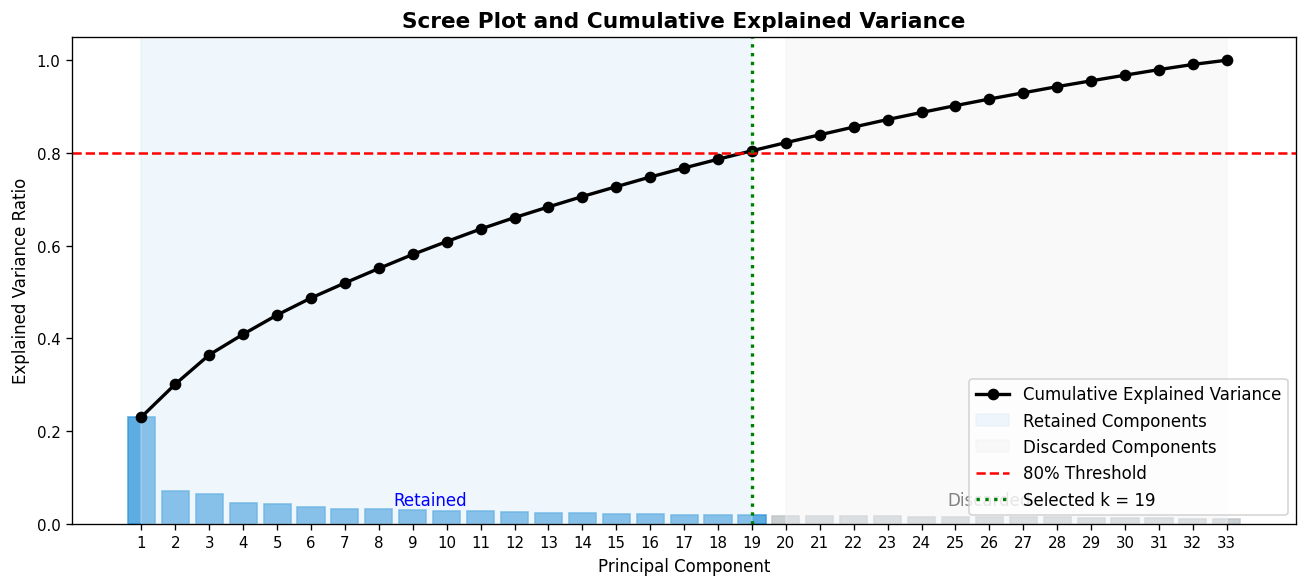

In [41]:
# ---------------------------------------------------------
# 4. Scree plot with cumulative explained variance
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))

# cumulative variance line
ax.plot(
    range(1, len(cumvar) + 1),
    cumvar,
    marker='o',
    linestyle='-',
    linewidth=2,
    color='black',
    label='Cumulative Explained Variance'
)

# individual variance bars
bars = ax.bar(
    range(1, len(explained_var) + 1),
    explained_var,
    alpha=0.80
)

# color retained vs discarded
for i, bar in enumerate(bars):
    if i < k_80:
        bar.set_color('#3498db')   # retained
    else:
        bar.set_color('#bdc3c7')   # discarded

# highlight retained and discarded regions
ax.axvspan(1, k_80, color='#d6eaf8', alpha=0.35, label='Retained Components')
if k_80 < len(explained_var):
    ax.axvspan(k_80 + 1, len(explained_var), color='#f2f3f4', alpha=0.45, label='Discarded Components')

# threshold and selected k
ax.axhline(variance_threshold, color='red', linestyle='--', linewidth=1.5, label=f'{variance_threshold:.0%} Threshold')
ax.axvline(k_80, color='green', linestyle=':', linewidth=2, label=f'Selected k = {k_80}')

# labels
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot and Cumulative Explained Variance', fontsize=13, fontweight='bold')

# small annotations
ax.text(max(k_80 / 2, 1), 0.04, 'Retained', ha='center', fontsize=10, color='blue')
if k_80 < len(explained_var):
    ax.text((k_80 + len(explained_var)) / 2, 0.04, 'Discarded', ha='center', fontsize=10, color='gray')
ax.set_xticks(range(1, len(explained_var) + 1))
ax.grid(False)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()



#### 3.2.1.2 PCA biplot

Purpose: Intuition + direction
Note: 
A biplot has:

- points (students)
- arrows (variables)

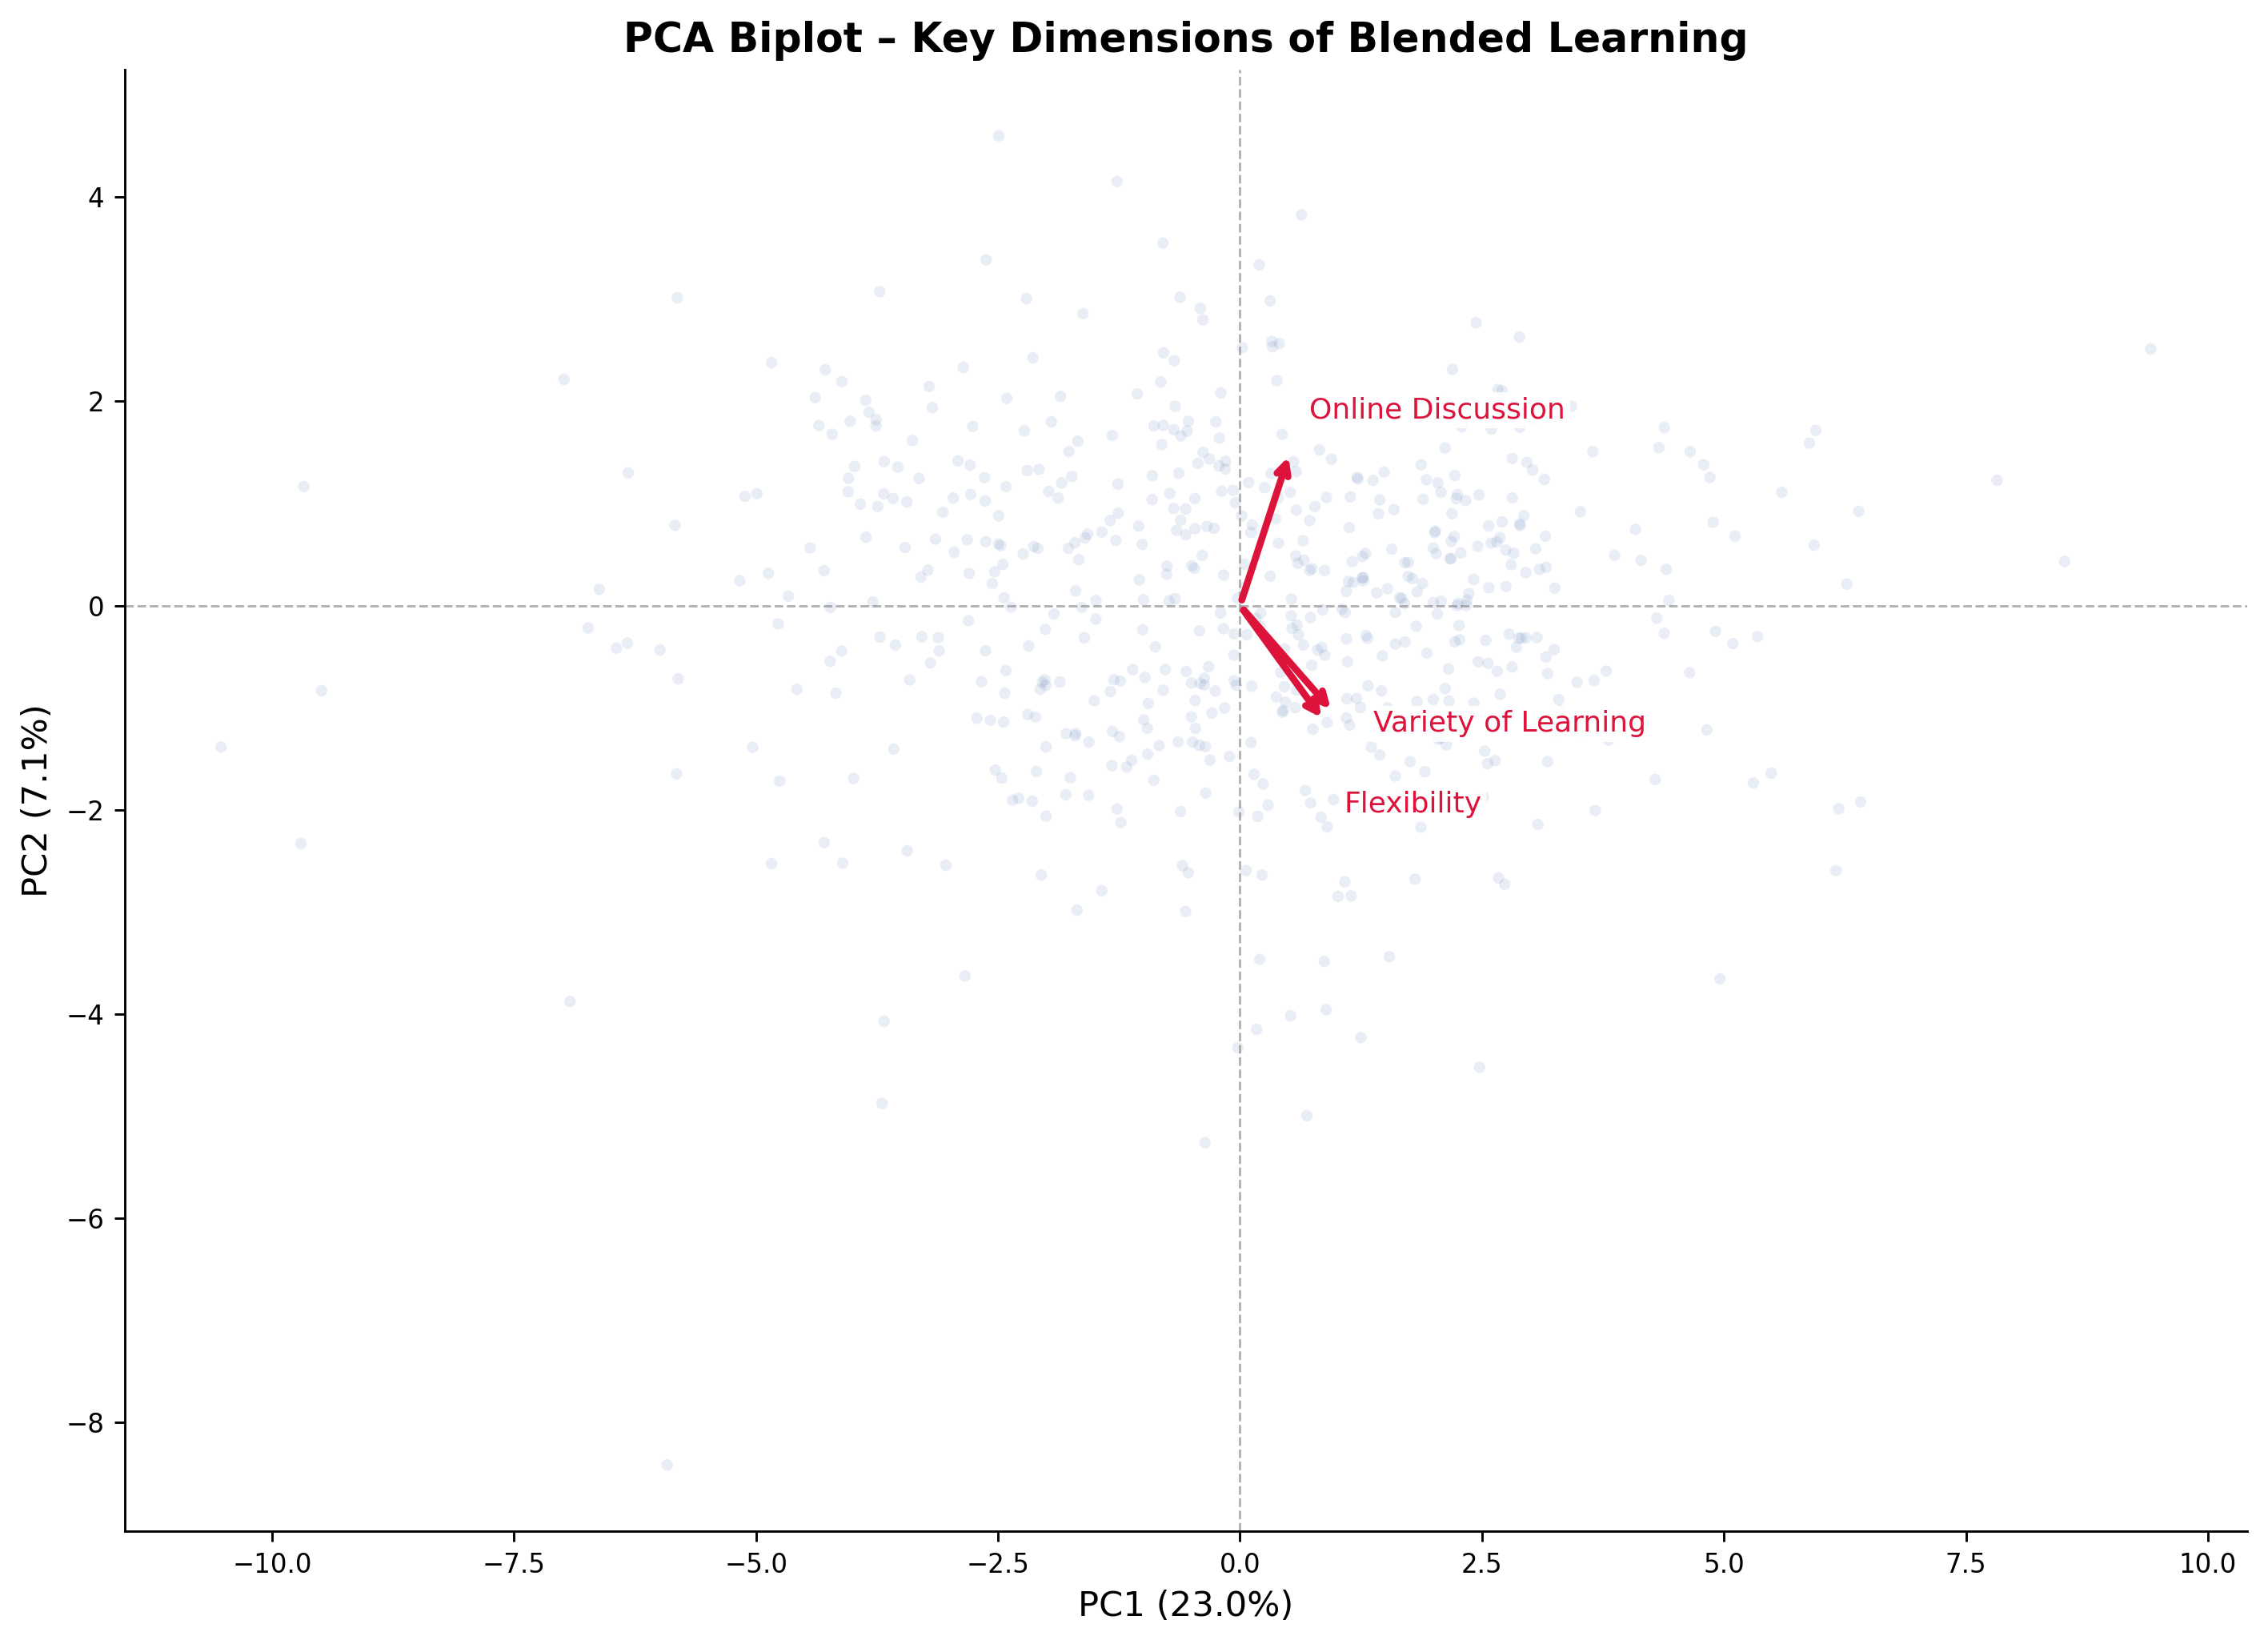

In [42]:
# ---------------------------------------------------------
# FINAL INTERPRETABLE PCA BIPLOT (THESIS VERSION)
# ---------------------------------------------------------

pca_2 = PCA(n_components=pca_cfg.get("biplot_components", 2), random_state=RANDOM_STATE)
scores_2d = pca_2.fit_transform(X_sc)
loadings = pca_2.components_.T

selected_vars = [
    v for v in pca_cfg.get("biplot_selected_vars", [])
    if v in pca_features
]
selected_idx = [pca_features.index(v) for v in selected_vars]
label_map = pca_cfg.get("biplot_label_map", {})
offsets = pca_cfg.get("biplot_offsets", {})
scale = pca_cfg.get("arrow_scale", 4.8)

fig, ax = plt.subplots(figsize=(11, 8), dpi=260)

ax.scatter(
    scores_2d[:, 0],
    scores_2d[:, 1],
    s=16,
    alpha=0.12,
    color='#4c72b0',
    edgecolors='none'
)

for i in selected_idx:
    x = loadings[i, 0] * scale
    y = loadings[i, 1] * scale

    raw = pca_features[i]
    label = label_map.get(raw, pl(raw))
    dx, dy = offsets.get(label, [0.2, 0.2])

    ax.annotate(
        '',
        xy=(x, y),
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle='->',
            color='crimson',
            lw=2.4
        )
    )

    ax.text(
        x + dx,
        y + dy,
        label,
        fontsize=10,
        color='crimson',
        ha='left',
        va='center',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.9,
            pad=1.5
        )
    )

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)

ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)

ax.set_title(
    'PCA Biplot – Key Dimensions of Blended Learning',
    fontsize=14,
    fontweight='bold'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()


PC1 (horizontal)

All arrows point to the right

Meaning: PC1 represents overall perceived benefits of blended learning

PC2 (vertical)

Clear separation:
- Up (positive PC2) → Online Discussion
- Down (negative PC2) → Flexibility + Variety

Meaning:PC2 represents a contrast between interactive learning and self-paced learning

The PCA biplot reveals two primary dimensions of blended learning. The first principal component (PC1) reflects overall perceived benefits, with all variables contributing positively, indicating that higher values correspond to more favorable learning experiences. The second principal component (PC2) differentiates between interaction-based learning and self-paced learning. Online discussion loads positively on PC2, while flexibility and variety of learning methods load negatively, suggesting a distinction between students who benefit from interactive engagement and those who prefer flexible, independent learning approaches.

#### 3.2.1.3 PCA loadings heatmap

Purpose: full variable detail

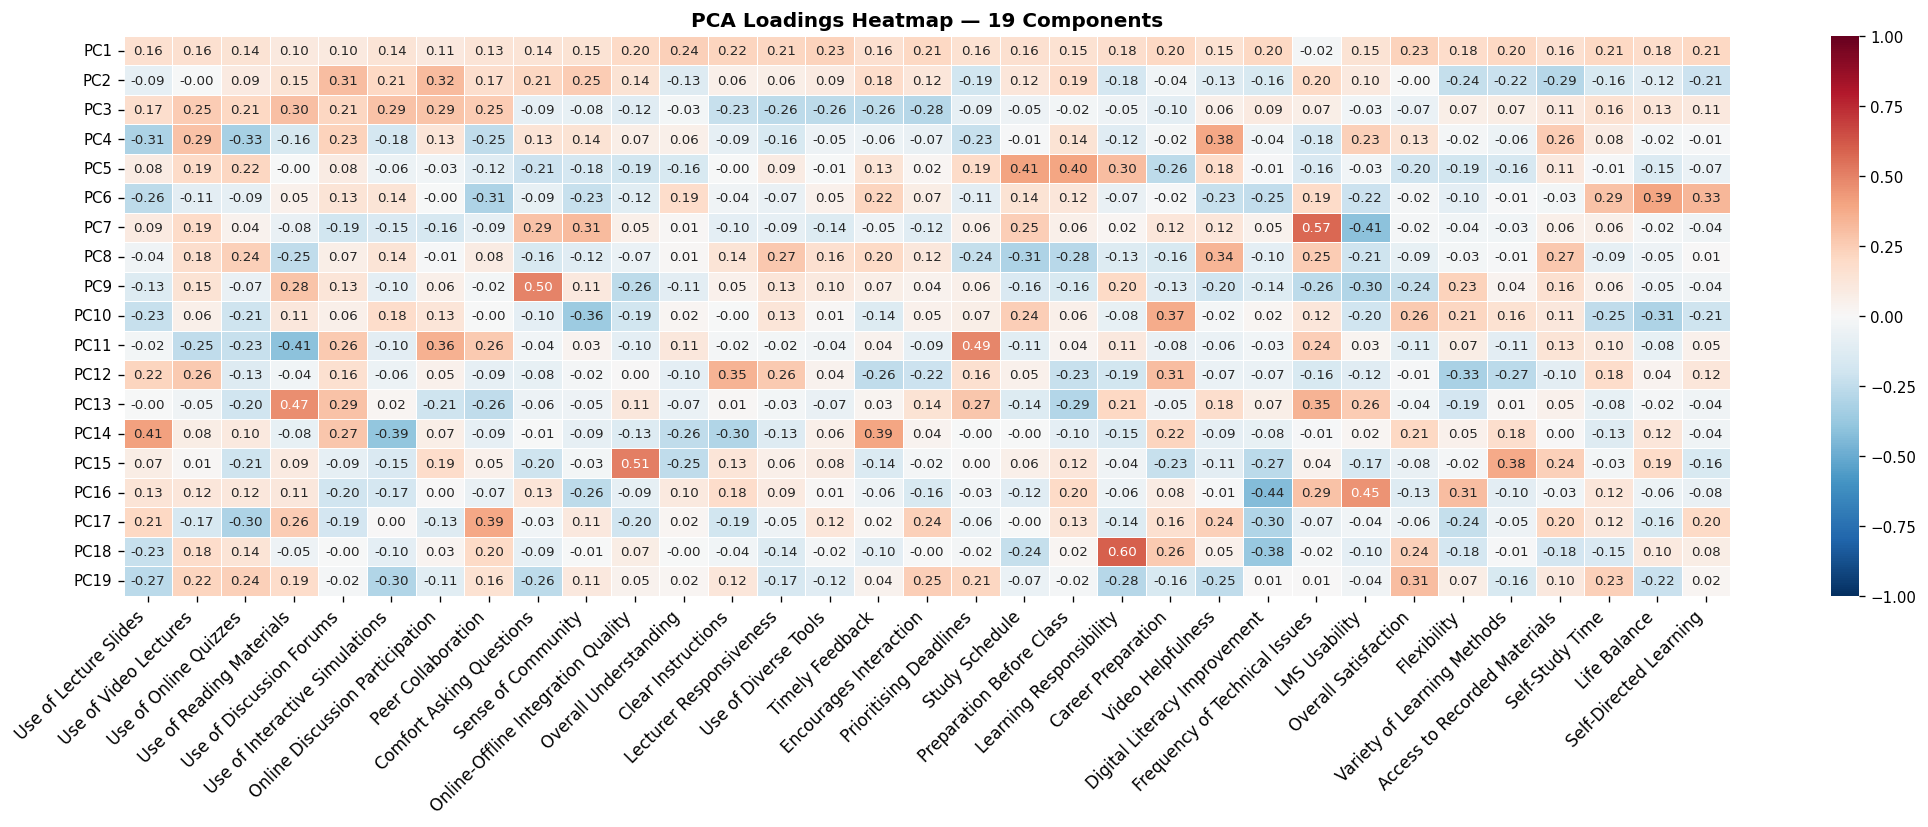

In [43]:
# ── 5.5 PCA Loadings Heatmap (configured max components) ───────────────
pca_k = PCA(n_components=min(k_80, pca_cfg.get("full_heatmap_max_components", 19)), random_state=RANDOM_STATE)
pca_k.fit(X_sc)
loadings_df = pd.DataFrame(
    pca_k.components_,
    columns=[pl(c) for c in pca_features],
    index=[f'PC{i+1}' for i in range(pca_k.n_components_)]
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, annot_kws={'size': 8}, ax=ax)
ax.set_title(f'PCA Loadings Heatmap — {pca_k.n_components_} Components',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout(); plt.show()


The PCA loadings heatmap reveals that the first principal component (PC1) captures a general dimension of blended learning effectiveness, with consistently positive contributions from most variables. This suggests that PC1 reflects overall student perceptions of learning quality and benefits.

In contrast, the second principal component (PC2) differentiates between interaction-based learning (e.g., discussion participation, collaboration) and self-paced learning (e.g., recorded materials, flexibility). This indicates the presence of two distinct learning modes within the blended learning environment.

Subsequent components capture more localized patterns of variation across subsets of variables, confirming that student experiences are multi-dimensional and complex.

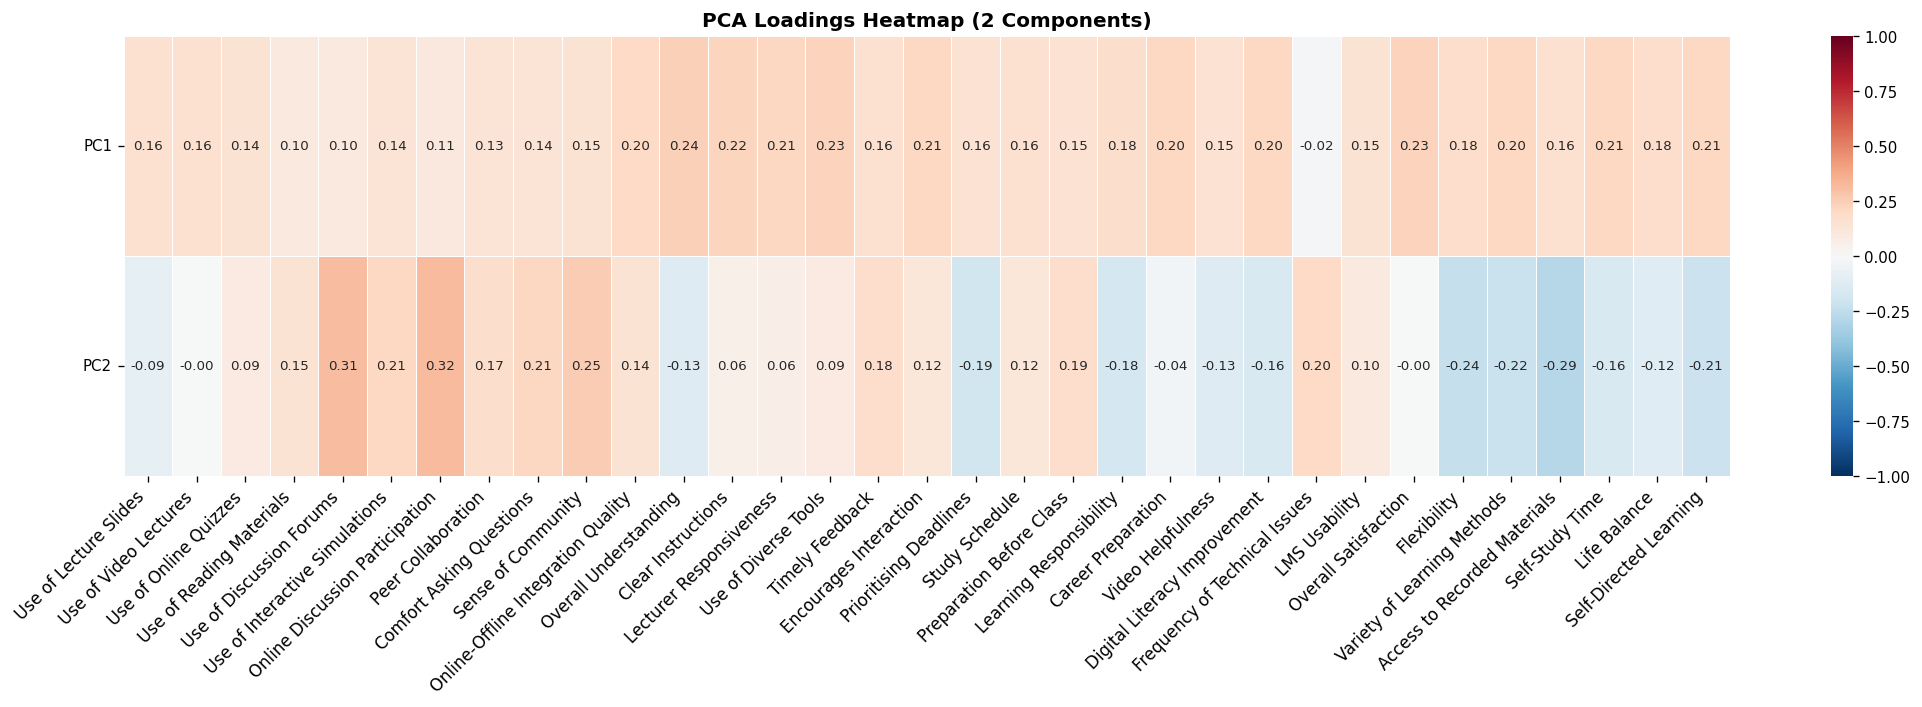

In [44]:
# ---------------------------------------------------------
#  PCA loadings heatmap
# ---------------------------------------------------------
n_heatmap = min(k_80, pca_cfg.get("readable_heatmap_components", 2))

pca_k = PCA(n_components=n_heatmap, random_state=RANDOM_STATE)
pca_k.fit(X_sc)

loadings_df = pd.DataFrame(
    pca_k.components_,
    columns=[pl(c) for c in pca_features],
    index=[f'PC{i+1}' for i in range(pca_k.n_components_)]
)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    loadings_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={'size': 8},
    ax=ax
)

ax.set_title(f'PCA Loadings Heatmap ({n_heatmap} Components)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 3.3 Exploratory Validation — Gower Distance and Hierarchical Clustering

This subsection was moved from `Gower_refactored.ipynb` into the main EDA notebook to avoid maintaining a separate duplicate exploratory notebook.

Gower-style distance with hierarchical clustering is used here as an exploratory validation check for ordinal Likert response patterns. It is **not** the final segmentation model; the final student segments remain produced by K-Modes in the segmentation notebook.


In [45]:
# ── Gower-style hierarchical clustering configuration ───────────────────────
gower_cfg = eda_cfg.get("gower_hierarchical", {})

if not gower_cfg.get("enabled", True):
    print("Gower hierarchical section is disabled in config.json.")
else:
    gower_features_source = gower_cfg.get("features_source", "ordinal_column_scales")
    if gower_features_source == "ordinal_column_scales":
        gower_features = list(settings.ordinal_column_scales.keys())
    else:
        gower_features = list(gower_cfg.get("features", ordinal_cols))

    missing_gower_features = [col for col in gower_features if col not in df.columns]
    if missing_gower_features:
        raise KeyError(f"Missing Gower input columns: {missing_gower_features}")

    K_RANGE_GOWER = range(
        int(gower_cfg.get("hierarchical", {}).get("k_range", [2, 6])[0]),
        int(gower_cfg.get("hierarchical", {}).get("k_range", [2, 6])[1]) + 1,
    )
    K_GOWER = int(gower_cfg.get("hierarchical", {}).get("final_k", 2))
    GOWER_CLUSTER_COL = gower_cfg.get("output_cluster_column", "gower_cluster")

    print(f"Gower features: {len(gower_features)}")
    print(f"K search range : {list(K_RANGE_GOWER)}")
    print(f"Final K        : {K_GOWER}")


Gower features: 33
K search range : [2, 3, 4, 5, 6]
Final K        : 2


Input shape: (592, 33)
Total nulls : 0


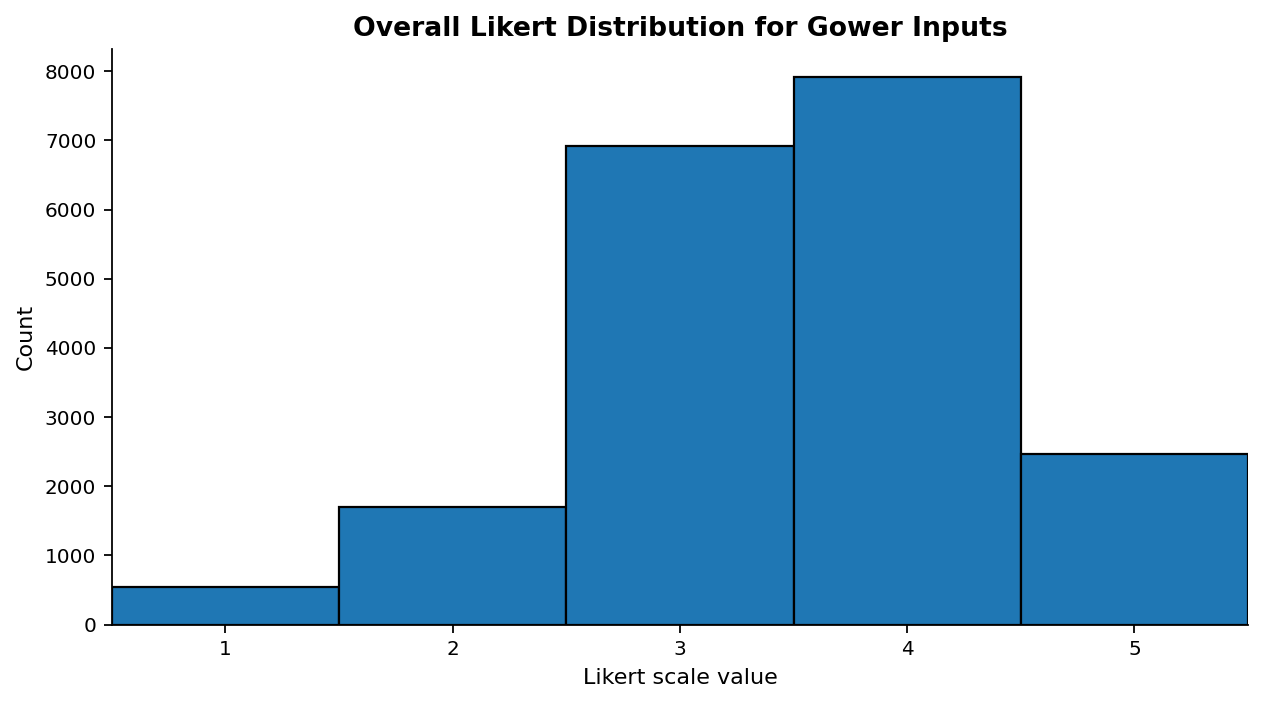

In [46]:
# ── Gower input preparation ─────────────────────────────────────────────────
X_gower = df[gower_features].copy().apply(pd.to_numeric, errors="coerce")

print("Input shape:", X_gower.shape)
print("Total nulls :", int(X_gower.isna().sum().sum()))

missing_strategy = gower_cfg.get("missing_strategy", "median")
if X_gower.isna().sum().sum() > 0:
    if missing_strategy == "median":
        X_gower = X_gower.fillna(X_gower.median(numeric_only=True))
        print("Missing values filled with column medians.")
    elif missing_strategy == "drop_rows":
        before_rows = len(X_gower)
        X_gower = X_gower.dropna(axis=0)
        print(f"Dropped rows with missing Gower inputs: {before_rows - len(X_gower)}")
    else:
        raise ValueError(f"Unsupported Gower missing strategy: {missing_strategy}")

X_gower = X_gower.astype(float)

vis_cfg = gower_cfg.get("visualisation", {})
fig, ax = plt.subplots(
    figsize=tuple(vis_cfg.get("likert_distribution_figsize", [8, 4.5])),
    dpi=int(vis_cfg.get("dpi", 160)),
)

ax.hist(
    X_gower.values.flatten(),
    bins=np.array(vis_cfg.get("histogram_bins", [0.5, 1.5, 2.5, 3.5, 4.5, 5.5])),
    edgecolor="black",
)

ax.set_title("Overall Likert Distribution for Gower Inputs", fontsize=12, weight="bold")
ax.set_xlabel("Likert scale value")
ax.set_ylabel("Count")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlim(0.5, 5.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [47]:
# ── Numeric Gower-style distance and hierarchical clustering ────────────────
from scipy.cluster.hierarchy import dendrogram, fcluster
from sklearn.metrics import silhouette_score

scale_min = float(gower_cfg.get("scale_min", 1))
scale_max = float(gower_cfg.get("scale_max", 5))
chunk_size = int(gower_cfg.get("distance", {}).get("chunk_size", 128))
linkage_method = gower_cfg.get("hierarchical", {}).get("linkage_method", "average")

D_gower = numeric_gower_distance_matrix(
    X_gower,
    scale_min=scale_min,
    scale_max=scale_max,
    chunk_size=chunk_size,
)
Z_gower = fit_hierarchical_from_distance(D_gower, method=linkage_method)

print("Gower-style distance matrix:", D_gower.shape)
print("Linkage matrix              :", Z_gower.shape)
print("Linkage method              :", linkage_method)


Gower-style distance matrix: (592, 592)
Linkage matrix              : (591, 4)
Linkage method              : average


In [48]:
# ── Gower hierarchical diagnostics search ───────────────────────────────────
gower_diag_results = []
gower_criterion = gower_cfg.get("hierarchical", {}).get("criterion", "maxclust")
cluster_sizes_col = gower_cfg.get("diagnostics", {}).get("cluster_sizes_column", "cluster_sizes")

for k in K_RANGE_GOWER:
    labels = fcluster(Z_gower, t=k, criterion=gower_criterion)
    counts = pd.Series(labels).value_counts().sort_index()

    silhouette = silhouette_score(D_gower, labels, metric="precomputed")
    largest_cluster_pct = counts.max() / counts.sum() * 100
    smallest_cluster_pct = counts.min() / counts.sum() * 100

    gower_diag_results.append({
        "k": int(k),
        "silhouette": float(silhouette),
        "largest_cluster_pct": float(largest_cluster_pct),
        "smallest_cluster_pct": float(smallest_cluster_pct),
        cluster_sizes_col: {int(idx): int(value) for idx, value in counts.to_dict().items()},
    })

gower_diag_df = pd.DataFrame(gower_diag_results)
display(gower_diag_df)


,k,silhouette,largest_cluster_pct,smallest_cluster_pct,cluster_sizes
0,2,0.464073,99.831081,0.168919,"{1: 591, 2: 1}"
1,3,0.373755,97.466216,0.168919,"{1: 577, 2: 14, 3: 1}"
2,4,0.353593,97.466216,0.168919,"{1: 577, 2: 7, 3: 7, 4: 1}"
3,5,0.323201,97.466216,0.168919,"{1: 577, 2: 7, 3: 2, 4: 5, 5: 1}"
4,6,0.320085,97.466216,0.168919,"{1: 577, 2: 6, 3: 1, 4: 2, 5: 5, 6: 1}"


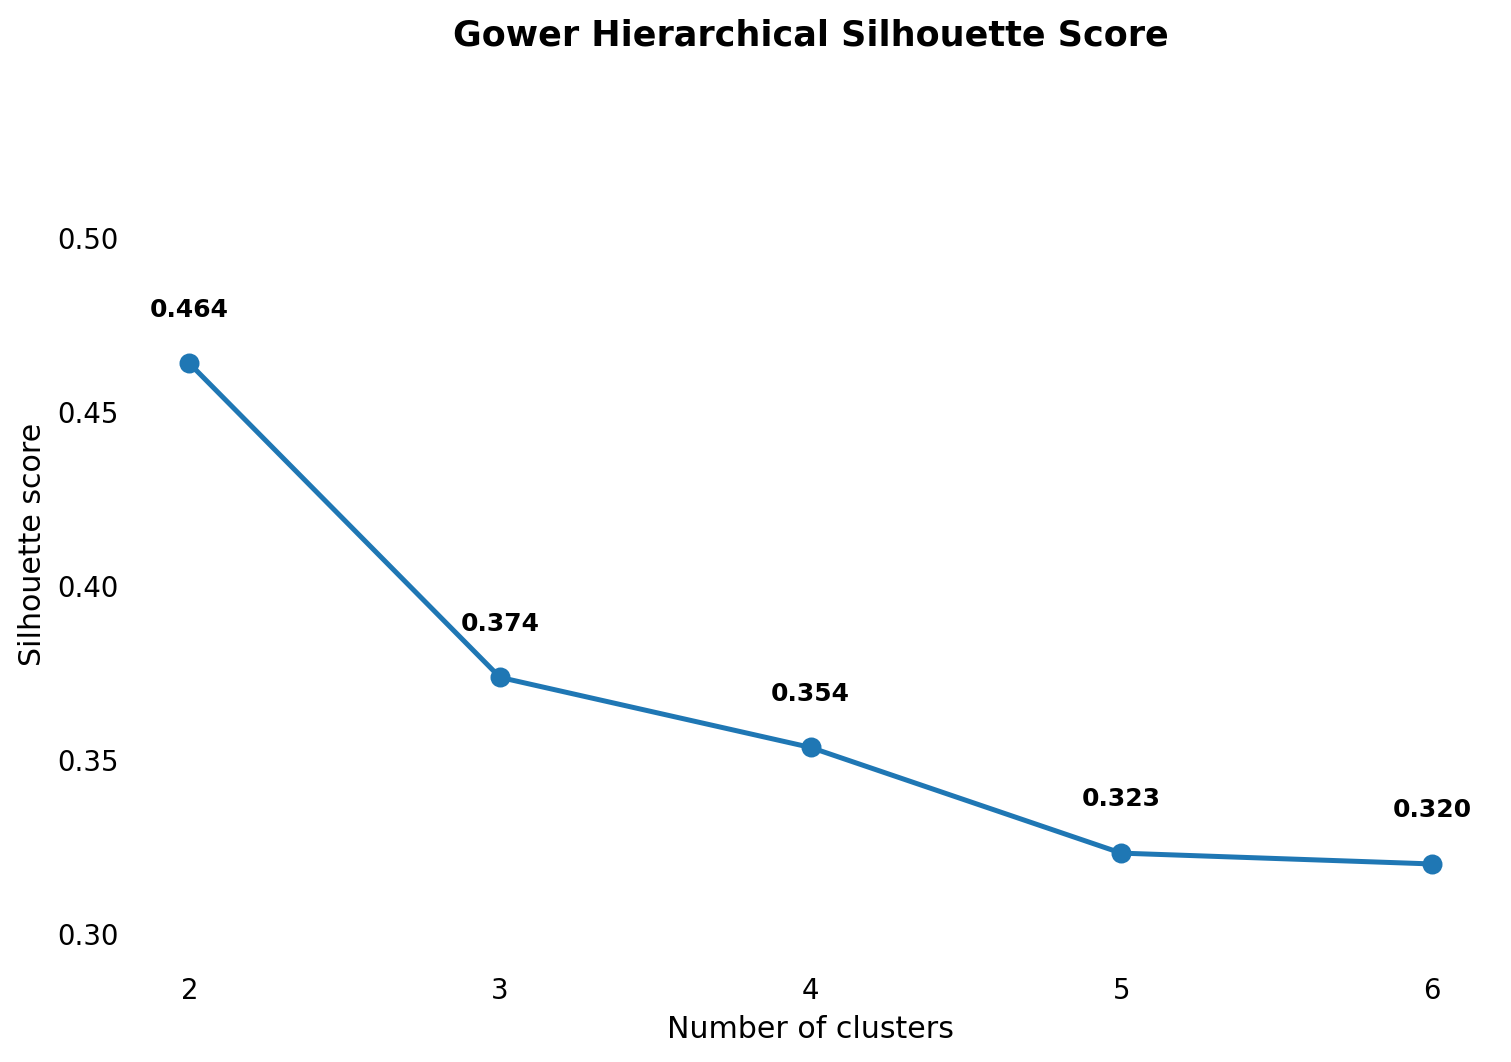

In [49]:
# ── Gower silhouette diagnostics figure ─────────────────────────────────────
k_vals = gower_diag_df["k"].tolist()
fig, ax = plt.subplots(
    figsize=tuple(vis_cfg.get("silhouette_figsize", [8.5, 6])),
    dpi=int(vis_cfg.get("silhouette_dpi", 180)),
)
fig.patch.set_facecolor("white")

ax.plot(
    gower_diag_df["k"],
    gower_diag_df["silhouette"],
    marker="o",
    markersize=7,
    linewidth=2,
)

ax.set_title("Gower Hierarchical Silhouette Score", fontsize=14, weight="bold", pad=30)
ax.set_xlabel("Number of clusters", fontsize=12)
ax.set_ylabel("Silhouette score", fontsize=12)
ax.set_xticks(k_vals)

for x, y in zip(gower_diag_df["k"], gower_diag_df["silhouette"]):
    ax.text(x, y + 0.012, f"{y:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

sil_min = gower_diag_df["silhouette"].min()
sil_max = gower_diag_df["silhouette"].max()
ax.set_ylim(sil_min - 0.03, sil_max + 0.07)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0, labelsize=11)
plt.tight_layout()
plt.show()


In [50]:
# ── Final Gower hierarchical cut ────────────────────────────────────────────
gower_labels = fcluster(Z_gower, t=K_GOWER, criterion=gower_criterion).astype(int)

# Keep this as an EDA-only column; it is not saved over the cleaned dataset.
df[GOWER_CLUSTER_COL] = gower_labels

print(f"Gower hierarchical clustering  K={K_GOWER}")
for cid in sorted(np.unique(gower_labels)):
    n = int((gower_labels == cid).sum())
    print(f"  Cluster {cid}: {n} students ({n / len(gower_labels) * 100:.1f}%)")


Gower hierarchical clustering  K=2
  Cluster 1: 591 students (99.8%)
  Cluster 2: 1 students (0.2%)


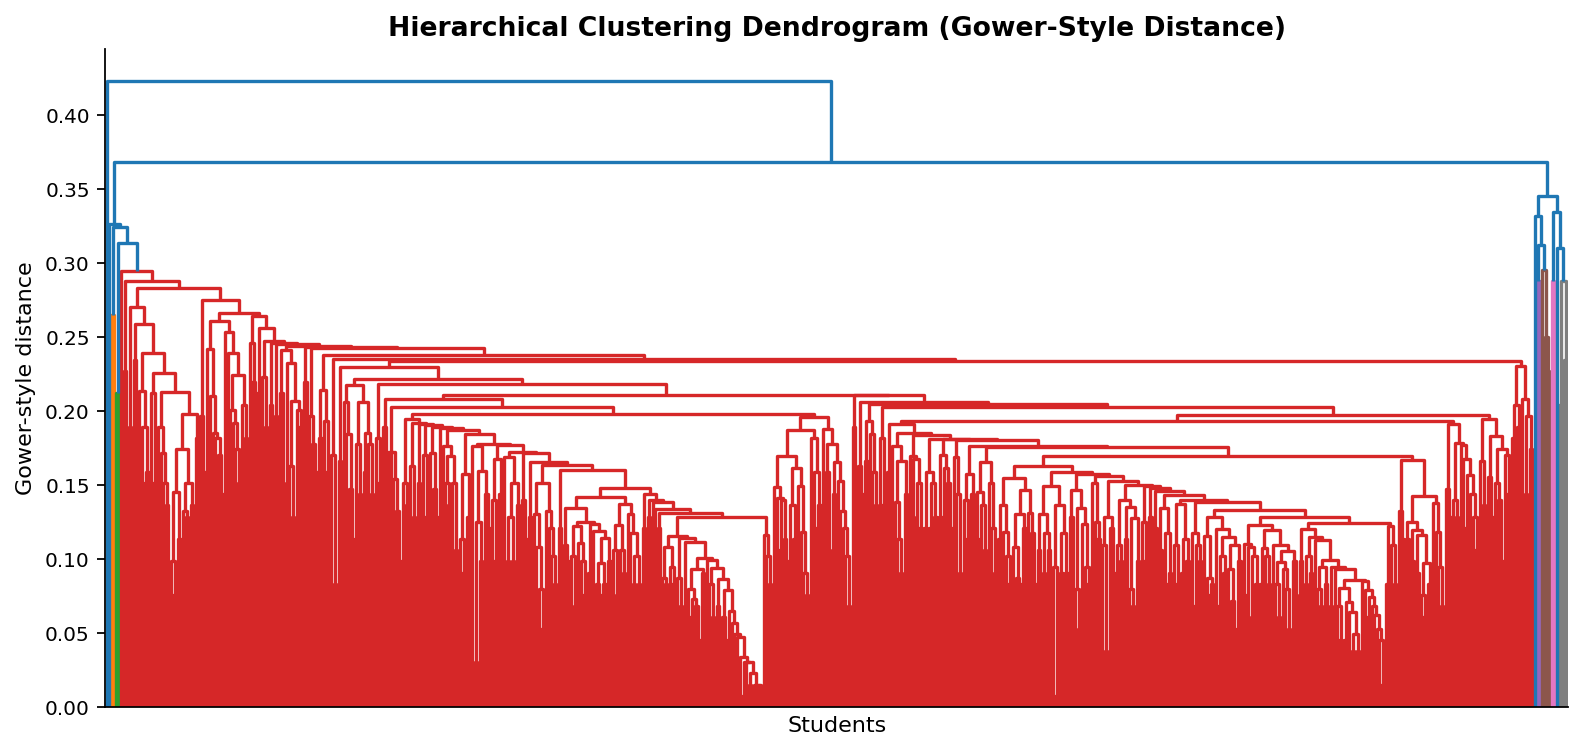

In [51]:
# ── Dendrogram for exploratory interpretation ───────────────────────────────
fig, ax = plt.subplots(
    figsize=tuple(vis_cfg.get("dendrogram_figsize", [10, 4.8])),
    dpi=int(vis_cfg.get("dpi", 160)),
)

dendrogram(
    Z_gower,
    no_labels=True,
    color_threshold=None,
    ax=ax,
)

ax.set_title("Hierarchical Clustering Dendrogram (Gower-Style Distance)", fontsize=12, weight="bold")
ax.set_xlabel("Students")
ax.set_ylabel("Gower-style distance")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


### 3.3.1 Gower Cluster Profile


In [52]:
# ── Profile Gower clusters on the ordinal items ─────────────────────────────
profile_cfg = gower_cfg.get("profile", {})
agg_method = profile_cfg.get("aggregation", "median")
round_digits = int(profile_cfg.get("round_digits", 2))

if agg_method == "median":
    gower_profile = df.groupby(GOWER_CLUSTER_COL)[gower_features].median().round(round_digits)
elif agg_method == "mean":
    gower_profile = df.groupby(GOWER_CLUSTER_COL)[gower_features].mean().round(round_digits)
else:
    raise ValueError(f"Unsupported Gower profile aggregation: {agg_method}")

display(gower_profile)


,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
gower_cluster,,,,,,,,,,,,,,,,,,,,,
1,4.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,...,5.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,5.0


In [53]:
# ── Largest profile differences between two Gower clusters ──────────────────
if K_GOWER == 2 and set([1, 2]).issubset(set(gower_profile.index)):
    diff_label = profile_cfg.get("difference_label", "cluster_2_minus_cluster_1")
    top_n = int(profile_cfg.get("top_differences", 15))

    profile_diff = (gower_profile.loc[2] - gower_profile.loc[1]).sort_values(
        key=lambda s: s.abs(),
        ascending=False,
    )

    profile_diff_df = (
        profile_diff
        .rename(diff_label)
        .reset_index()
        .rename(columns={"index": "variable"})
    )
    profile_diff_df["label"] = profile_diff_df["variable"].map(pretty_columns).fillna(profile_diff_df["variable"])
    display(profile_diff_df.head(top_n))
else:
    print("Profile-difference table is shown only when final Gower K=2 and clusters 1 and 2 exist.")


,variable,cluster_2_minus_cluster_1,label
0,self_responsibility,-3.0,Learning Responsibility
1,self_study_schedule,-3.0,Study Schedule
2,self_prioritize_deadlines,-3.0,Prioritising Deadlines
3,lect_diverse_tools,-3.0,Use of Diverse Tools
4,lect_responsive,-3.0,Lecturer Responsiveness
5,lect_foster_interaction,-2.0,Encourages Interaction
6,tech_issues_freq,2.0,Frequency of Technical Issues
7,lms_usability,2.0,LMS Usability
8,self_prepare_class,-2.0,Preparation Before Class
9,use_video_lectures,2.0,Use of Video Lectures


### Gower note

Gower-style distance with hierarchical clustering is retained as an exploratory validation approach rather than the main segmentation model. The final thesis segmentation remains based on K-Modes because it is simpler to deploy and easier to align with categorical student profiles.
